
<div style="border:solid green 2px; padding: 20px">

👋 **¡Hola! Soy Dot, tu revisor de IA.**

He completado la primera revisión de tu código. A continuación, encontrarás mis comentarios y sugerencias de mejora.

**¿Qué debes hacer ahora?**

1. **Revisar:** Lee mis comentarios en el notebook más abajo.
2. **Decidir:**
* **¿Estás de acuerdo con el feedback?** ¡Genial! Actualiza tu código según las sugerencias.
* **¿No estás de acuerdo o crees que es un error?** ¡No hay problema! Puedes dejar tu código exactamente como está.


3. **Volver a enviar:** Envía tu proyecto de nuevo. **Tu próxima iteración será revisada por un experto humano**, independientemente de si hiciste cambios o no.

-------------------------------------------------------------------------------------------------------------
Mis comentarios están más abajo. **Te pido amablemente que no los muevas, modifiques ni elimines**.

Verás mis comentarios resaltados en cuadros verdes, amarillos o rojos como estos:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Correcto. Todo se ha hecho exitosamente.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones.
</div>



# ¿Cuál es la mejor tarifa?



**Introducción General**

**Contexto del Negocio**

Este proyecto se desarrolló para Megaline, un operador de telecomunicaciones que ofrece dos planes de prepago: Surf y Ultimate. El departamento comercial solicitaba determinar cuál de estos planes genera más ingresos para optimizar la asignación del presupuesto publicitario.

**Objetivo Principal**

* Determinar qué tarifa de prepago (Surf vs Ultimate) genera más ingresos mediante un análisis estadístico riguroso de datos reales de clientes.

**Alcance del Proyecto**

El estudio se basó en datos de 500 clientes de Megaline durante el año 2018, incluyendo:
* Información demográfica: ubicación, edad, fechas de suscripción
* Comportamiento de uso: llamadas, mensajes SMS, consumo de datos
* Datos financieros: ingresos mensuales por cliente

**Características de los Planes Analizados**

Plan Surf ($20/mes):

- 500 minutos, 50 SMS, 15 GB incluidos.
- Excesos: `$`0.03/min, `$`0.03/SMS, `$`10/GB.

Plan Ultimate ($70/mes):

- 3000 minutos, 1000 SMS, 30 GB incluidos.
- Excesos: `$`0.01/min, `$`0.01/SMS, `$`7/GB.

**Metodología Aplicada**

El proyecto siguió una metodología de análisis de datos completa:

- Preparación de datos: Limpieza, transformación y cálculo de ingresos mensuales.
- Análisis exploratorio: Estadísticas descriptivas y visualizaciones.
- Análisis estadístico: Pruebas t-test para comparar ingresos entre planes y regiones.
- Conclusiones estratégicas: Recomendaciones basadas en evidencia estadística.

**Hipótesis Evaluadas**

- Diferencia entre planes: ¿Los ingresos promedio de Surf y Ultimate son estadísticamente diferentes?
- Diferencia regional: ¿Los usuarios de NY-NJ generan ingresos diferentes a otras regiones?

Este análisis proporcionó insights clave para la toma de decisiones estratégicas sobre inversión publicitaria y enfoque comercial de la empresa.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta sección actualmente repite el prompt. Considera añadir una breve introducción al proyecto con tus propias palabras: el objetivo de negocio (qué plan genera más ingresos) y un resumen de los pasos principales que seguirás (preparación de datos, agregación mensual, cálculo de ingresos, análisis exploratorio, pruebas de hipótesis, recomendación final).

</div>


## Inicialización

In [1]:
# Cargar todas las librerías
from scipy import stats as st
from matplotlib import pyplot as plt
from functools import reduce
import pandas as pd
import numpy as np
import math

### Cargar funciones

In [2]:
def mostrar_nan(df, columna=None, num_filas=10):
    """
    Imprime la cantidad de valores Nan por columna del DataFrame
    Muestra las filas completas que contienen valores NaN
    
    Parámetros:
    df: DataFrame a analizar
    columna: nombre de columna específica (opcional)
    num_filas: cuántas filas mostrar (por defecto 10)
    """
    name = str(df)
    lista= df.columns
    print(f"\nEl dataframe tiene {df.duplicated().sum()} filas repetidas")
    print('-'*50)
    #Para una sola columna:
    if columna:  
        filas_nan = df[df[columna].isna()] #crea DF de puros valores NaN
        print(f"\nFilas con NaN en '{columna}': {len(filas_nan)} encontradas") # imprime nombre de la columna y cantidad de NaN
        if not filas_nan.empty: # Si el DF filas_nan tiene algo adentro
                print("\nPrimeras", min(num_filas, len(filas_nan)), "filas completas conteniendo NaN para: ", "'",columna,"'")
                print(filas_nan.head(num_filas))
                print('-'*50) #separador visual
    else:        
        for column in lista:
            filas_nan =df[df[column].isna()]
            print(f"\nFilas con NaN en '{column}': {len(filas_nan)} encontradas") #hace lo mismo que el del if anterior para cada columna de un dF
            if not filas_nan.empty:
                print("\nPrimeras", min(num_filas, len(filas_nan)), "filas completas conteniendo NaN para: ", "'",column,"'")
                print(filas_nan.head(num_filas))
                print('-'*50) #separador visual
    return filas_nan
#===========================================================================
def mostrar_dupli(df, columna=None, num_filas=10):
    """
    Imprime la cantidad de filas duplicadas del DataFrame
    Muestra las filas completas que están duplicadas
    
    Parámetros:
    df: DataFrame a analizar
    columna: nombre de columna específica para buscar duplicados (opcional)
    num_filas: cuántas filas mostrar (por defecto 10)
    """
    
    print(f"\nEl dataframe tiene {df.duplicated().sum()} filas completamente duplicadas")
    print('-'*50)
    # Para una sola columna:
    if columna:  
        filas_duplicadas = df[df.duplicated(subset=[columna], keep=False)]
        print(f"\nFilas con valores duplicados en '{columna}': {len(filas_duplicadas)} encontradas")
        print('-'*50)
        if not filas_duplicadas.empty:
            print(f"\nPrimeras {min(num_filas, len(filas_duplicadas))} filas completas con duplicados en: '{columna}'")
            print(filas_duplicadas.head(num_filas))
            print('-'*50)
    else:        
        # Para duplicados completos (todas las columnas)
        filas_duplicadas = df[df.duplicated(keep=False)]
        print(f"\nFilas completamente duplicadas: {len(filas_duplicadas)} encontradas")
        print('-'*50)
        if not filas_duplicadas.empty:
            print(f"\nPrimeras {min(num_filas, len(filas_duplicadas))} filas completamente duplicadas:")
            print(filas_duplicadas.sort_values('user_id').head(num_filas))
            print('-'*50)
    return filas_duplicadas
#===========================================================================
def boxplot_stats(datos, nombre='Datos', atipicos=False):
    '''
    Función que recibe un array y el nombre del array (Datos por defecto)
    y puede devolver un diccionario con los estadísticos y valores atipicos
    si el tercer argumento es True.
    Arroja información completa de los puntos más importantes de
    un diagrama de caja incluyendo los valores atípicos.
    '''
    ## Dato límite del primer cuartil
    q1 = np.percentile(datos, 25)
    ## Dato límite del tercer cuartil
    q3 = np.percentile(datos, 75)
    ## Dato de cuánto mide el espacio intercuartil
    iqr = q3 - q1
    
    # Límites teóricos de bigotes
    ## valor del primer cuartil menos 1.5 veces lo que mide el espacio intercuartil
    limite_inf = q1 - 1.5 * iqr
    ## valor del tercer cuartil mas 1.5 veces lo que mide el espacio intercuartil
    limite_sup = q3 + 1.5 * iqr
    
    # Valores reales de los bigotes
    ## El mínimo de los valores que superen el límite inferior
    min_bigote = np.min(datos[datos >= limite_inf])
    ## El máximo de los valores que esten debajo del límite superior
    max_bigote = np.max(datos[datos <= limite_sup])

    # Identificar los valores atípicos
    ## Todos los datos por debajo del límite inferior
    atipicos_inf = datos[datos < limite_inf]
    ## Todos los datos por encima del límite superior
    atipicos_sup = datos[datos > limite_sup]
    ## Total en número de los valores atípicos
    atipicos_totales = len(atipicos_inf) + len(atipicos_sup)
    ## Procentaje de valores atípicos respecto al total de datos
    porcentaje_atipicos= (atipicos_totales/len(datos)) * 100

    # Imprime los datos del boxplot del arreglo
    print(f"=== {nombre.upper()}===")
    print(f"Mínimo absoluto: {np.min(datos):.2f}")
    print(f"Mínimo del bigote: {min_bigote:.2f}")
    print(f"Q1: {q1:.2f}")
    print(f"Mediana: {np.percentile(datos, 50):.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"Máximo del bigote: {max_bigote:.2f}")
    print(f"Máximo absoluto: {np.max(datos):.2f}")
    print(f"\n--- VALORES ATÍPICOS ---")
    print(f"Atípicos inferiores: {len(atipicos_inf)} valores.")
    print(f"Atípicos superiores: {len(atipicos_sup)} valores.")
    print(f"Atípicos totales: {atipicos_totales} ({porcentaje_atipicos:.1f}% del total.)")
    print(f"Datos normales: {len(datos) - atipicos_totales} ({100 - porcentaje_atipicos:.1f}% del total.)")
    if atipicos:
        return{'atipicos_inf':atipicos_inf,
               'atipicos_sup':atipicos_sup,
               'stats': {'q1': q1, 'q3': q3, 'mediana' : np.percentile(datos, 50)}
              }
#================================================================================
def crear_boxplots_mensuales(df, columnas_base, nombre_metrica, filtrar_ceros=True, plan_surf='surf', plan_ultimate='ultimate'):
    """
    Crea boxplots mensuales en facets para cualquier métrica
    
    Parámetros:
    df: DataFrame con los datos
    columnas_base: string base para las columnas (ej: 'mins', 'msgs', 'gb')
    nombre_metrica: string para títulos (ej: 'Minutos', 'Mensajes', 'GB')
    filtrar_ceros: bool, si filtrar valores = 0
    plan_surf: nombre del plan surf en los datos
    plan_ultimate: nombre del plan ultimate en los datos
    """
    
    fig, axes = plt.subplots(3, 4, figsize=(15, 10))
    axes = axes.flatten()
    
    # Título principal
    titulo = f'Distribución de {nombre_metrica} Mensuales por Plan - Boxplots por Mes'
    if filtrar_ceros:
        titulo += ' (Usuarios Activos)'
    fig.suptitle(titulo, fontsize=16, fontweight='bold')
    
    for i, mes in enumerate(range(1, 13)):
        columna_mes = f'{columnas_base}_{mes}'
        
        # Datos del mes específico
        surf_data = df[df['plan_name'] == plan_surf][columna_mes].dropna()
        ultimate_data = df[df['plan_name'] == plan_ultimate][columna_mes].dropna()
        
        # Filtrar valores mayores a 0 si se especifica
        if filtrar_ceros:
            surf_data = surf_data[surf_data > 0]
            ultimate_data = ultimate_data[ultimate_data > 0]
        
        # Crear boxplot para el mes
        datos_para_boxplot = []
        etiquetas = []
        
        if len(surf_data) > 0:
            datos_para_boxplot.append(surf_data)
            etiquetas.append('Surf')
        
        if len(ultimate_data) > 0:
            datos_para_boxplot.append(ultimate_data)
            etiquetas.append('Ultimate')
        
        if datos_para_boxplot:
            box_plot = axes[i].boxplot(datos_para_boxplot, 
                                     labels=etiquetas,
                                     patch_artist=True)
            
            # Colorear las cajas
            colors = ['lime', 'hotpink']
            for patch, color in zip(box_plot['boxes'], colors[:len(box_plot['boxes'])]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
        
        axes[i].set_title(f'Mes {mes}')
        axes[i].set_ylabel(nombre_metrica)
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Ejemplo de uso:
# Para minutos
#crear_boxplots_mensuales(df_ready_for_stats_copy, 'mins', 'Minutos', filtrar_ceros=True)

# Para mensajes
#crear_boxplots_mensuales(df_ready_for_stats_copy, 'msgs', 'Mensajes', filtrar_ceros=True)

# Para GB
#crear_boxplots_mensuales(df_ready_for_stats_copy, 'gb', 'GB', filtrar_ceros=True)
#=================================================================
def boxplot_stats_mensuales(df, columnas_base, nombre_metrica, filtrar_ceros=True, plan_surf='surf', plan_ultimate='ultimate'):
    """
    Aplica boxplot_stats a cada mes para una métrica específica
    
    Parámetros:
    df: DataFrame con los datos
    columnas_base: string base para las columnas (ej: 'mins', 'msgs', 'gb')
    nombre_metrica: string para títulos (ej: 'Minutos', 'Mensajes', 'GB')
    filtrar_ceros: bool, si filtrar valores = 0
    """
    
    print(f"=== ESTADÍSTICAS DE {nombre_metrica.upper()} POR MES ===\n")
    
    for mes in range(1, 13):
        columna_mes = f'{columnas_base}_{mes}'
        
        print(f"--- MES {mes} ---")
        
        # Datos del mes específico
        surf_data = df[df['plan_name'] == plan_surf][columna_mes].dropna()
        ultimate_data = df[df['plan_name'] == plan_ultimate][columna_mes].dropna()
        
        # Filtrar valores mayores a 0 si se especifica
        if filtrar_ceros:
            surf_data = surf_data[surf_data > 0]
            ultimate_data = ultimate_data[ultimate_data > 0]
        
        # Aplicar boxplot_stats si hay datos
        if len(surf_data) > 0:
            boxplot_stats(surf_data, f'{nombre_metrica} {plan_surf.title()} - Mes {mes}')
            print()
        
        if len(ultimate_data) > 0:
            boxplot_stats(ultimate_data, f'{nombre_metrica} {plan_ultimate.title()} - Mes {mes}')
            print()
        
        print("-" * 60)

# Ejemplo de uso:
#boxplot_stats_mensuales(df_ready_for_stats_copy, 'mins', 'Minutos', filtrar_ceros=True
#=======================================================
def resumen_boxplot_stats_por_plan(df, columnas_base, nombre_metrica, plan='surf', filtrar_ceros=True):
    """
    Genera estadísticas de boxplot para un plan específico a través de todos los meses
    """
    
    print(f"=== RESUMEN ANUAL DE {nombre_metrica.upper()} - PLAN {plan.upper()} ===\n")
    
    for mes in range(1, 13):
        columna_mes = f'{columnas_base}_{mes}'
        
        # Datos del mes específico para el plan
        data_mes = df[df['plan_name'] == plan][columna_mes].dropna()
        
        # Filtrar valores mayores a 0 si se especifica
        if filtrar_ceros:
            data_mes = data_mes[data_mes > 0]
        
        if len(data_mes) > 0:
            print(f"📅 MES {mes}:")
            boxplot_stats(data_mes, f'{nombre_metrica} {plan.title()} - Mes {mes}')
            print("-" * 40)
        else:
            print(f"📅 MES {mes}: Sin datos disponibles")
            print("-" * 40)

# Ejemplo de uso:
#resumen_boxplot_stats_por_plan(df_ready_for_stats_copy, 'mins', 'Minutos', 'surf', filtrar_ceros=True)
#resumen_boxplot_stats_por_plan(df_ready_for_stats_copy, 'mins', 'Minutos', 'ultimate', filtrar_ceros=True)

#============================================================================================

def comparar_con_y_sin_extras(df, tipo_dato='mins', mostrar_estadisticas=True):
    """
    Compara duración de minutos promedio total contra minutos sin cantidad extras

    Parámetros:
    df: DataFrame con los datos (df_ready_for_stats_copy recomendado)
    mostrar_estadisticas: bool - True para mostrar estadísticas adicionales
    """

    # Validar tipo de dato
    if tipo_dato not in ['mins', 'msgs', 'gb']:
        raise ValueError("tipo_dato debe ser 'mins', 'msgs' o 'gb'")

    # Definir límites por plan
    # Definir límites por plan según el tipo de dato
    limites = {
        'mins': {'surf': 500, 'ultimate': 3000},
        'msgs': {'surf': 1000, 'ultimate': 3000},
        'gb': {'surf': 15, 'ultimate': 30}
        }

     # Definir unidades y etiquetas
    unidades = {
        'mins': 'minutos',
        'msgs': 'mensajes', 
        'gb': 'GB'
        }

    # Obtener límites y unidad para el tipo seleccionado
    limites_tipo = limites[tipo_dato]
    unidad = unidades[tipo_dato]
    
    # Crear columnas de meses
    columnas_tipo = [f'{tipo_dato}_{i}' for i in range(1, 13)]
    meses_labels = [f'Mes {i}' for i in range(1, 13)]

    # FILTRAR SOLO USUARIOS ACTIVOS
    # Crear máscara para usuarios que tienen al menos un mes con consumo > 0
    mascara_activos = (df[columnas_tipo] > 0).any(axis=1)
    df_activos = df[mascara_activos].copy()
    
    print(f"Total usuarios: {len(df)}")
    print(f"Usuarios activos en {unidad}: {len(df_activos)}")
    print(f"Porcentaje de usuarios activos: {len(df_activos)/len(df)*100:.1f}%")
    
    # Crear figura con dos subplots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # GRÁFICA 1: MINUTOS TOTALES (incluyendo extras)
    consumo_promedio_total = df_activos.groupby('plan_name')[columnas_tipo].mean()
    df_total = consumo_promedio_total.T
    df_total.index = meses_labels

    df_total.plot(kind='bar',
                      ax=axes[0],
                      color=['lime', 'hotpink'],
                      title=f'Consumo Promedio Total de {unidad.title()} por Plan (Con Extras) - Solo Usuarios Activos',
                      xlabel='Meses del año 2018',
                      ylabel= f'Promedio de {unidad}',
                      rot=45,
                      width=0.8)
    axes[0].legend(title='Plan', labels=['Surf', 'Ultimate'])
    axes[0].grid(True, alpha=0.3)

    # GRÁFICA 2: MINUTOS SIN EXTRAS (limitados al plan)
    df_copy = df_activos.copy()

    # Aplicar límites por plan para cada mes
    for mes in range(1, 13):
        columna_mes = f'{tipo_dato}_{mes}'
        columna_limitada = f'{tipo_dato}_limitado_{mes}'

        # Para cada fila, aplicar el límite según su plan
        df_copy[columna_limitada] = df_copy.apply(
            lambda row: min(row[columna_mes], limites_tipo[row['plan_name']]) if pd.notna(row[columna_mes]) else np.nan, 
            axis=1
        )

    # Crear lista de columnas limitadas
    columnas_limitadas = [f'{tipo_dato}_limitado_{i}' for i in range(1, 13)]

    # Agrupar datos limitados
    duracion_promedio_limitada = df_copy.groupby('plan_name')[columnas_limitadas].mean()
    df_mins_limitado = duracion_promedio_limitada.T
    df_mins_limitado.index = meses_labels

    df_mins_limitado.plot(kind='bar',
                         ax=axes[1],
                         color=['lime', 'hotpink'],
                         title=f'{unidad.title()} Promedio SIN EXTRAS por Plan (Limitado) - Solo Usuarios Activos',
                         xlabel='Meses del año 2018',
                         ylabel=f'Promedio de {unidad}',
                         rot=45,
                         width=0.8)
    axes[1].legend(title='Plan', labels=['Surf', 'Ultimate'])
    axes[1].grid(True, alpha=0.3)

    # Ajustar layout y mostrar
    plt.tight_layout()
    plt.show()

    # Mostrar estadísticas si se solicita
    if mostrar_estadisticas:
        print("=== ESTADÍSTICAS COMPARATIVAS (SOLO USUARIOS ACTIVOS) ===")
        # Estadísticas por plan
        for plan in ['surf', 'ultimate']:
            usuarios_plan = len(df_activos[df_activos['plan_name'] == plan])
            print(f"\nUsuarios activos en plan {plan}: {usuarios_plan}")
        
        print(f"\nPromedio de {unidad} TOTALES por plan:")
        print(consumo_promedio_total.mean(axis=1))
        
        print(f"\nPromedio de {unidad} SIN EXTRAS por plan:")
        print(duracion_promedio_limitada.mean(axis=1))
        
        print("\nDiferencia promedio (Extras consumidos):")
        diferencia = consumo_promedio_total.mean(axis=1) - duracion_promedio_limitada.mean(axis=1)
        print(diferencia)
        
        print(f"\nPorcentaje de uso extra:")
        porcentaje_extra = (diferencia / duracion_promedio_limitada.mean(axis=1)) * 100
        print(porcentaje_extra)

#===================================
def crear_histogramas_mensuales(df, tipo_dato='mins', mostrar_solo_activos=True, bins=20, figsize=(15, 10)):
    """
    Crea histogramas mensuales sin usar flatten(), procesando mes por mes
    """
    # Validar tipo de dato
    if tipo_dato not in ['mins', 'msgs', 'gb']:
        raise ValueError("tipo_dato debe ser 'mins', 'msgs' o 'gb'")

    # Definir unidades
    unidades = {'mins': 'Minutos', 'msgs': 'Mensajes', 'gb': 'GB'}
    unidad = unidades[tipo_dato]

    # Crear figura con subplots
    fig, axes = plt.subplots(3, 4, figsize=figsize)
    axes = axes.flatten()

    # Título principal
    titulo = f'Distribución de {unidad} Mensuales por Plan - Año 2018'
    if mostrar_solo_activos:
        titulo += ' (Solo Usuarios Activos)'
    fig.suptitle(titulo, fontsize=16, fontweight='bold')

    # Procesar cada mes por separado (SIN FLATTEN)
    for i, mes in enumerate(range(1, 13)):
        columna_mes = f'{tipo_dato}_{mes}'

        # Filtrar datos específicos para cada mes
        #surf_data_mes = dfdf['plan_name']=='surf'.dropna()
        #ultim_data_mes = dfdf['plan_name']=='ultimate'.dropna()
        surf_data_mes = df[df['plan_name']=='surf'][columna_mes].dropna()
        ultim_data_mes = df[df['plan_name']=='ultimate'][columna_mes].dropna()

        # Filtrar solo valores mayores a 0 si se especifica
        if mostrar_solo_activos:
            surf_data_mes = surf_data_mes[surf_data_mes > 0]
            ultim_data_mes = ultim_data_mes[ultim_data_mes > 0]

        # Crear histograma para este mes específico
        axes[i].hist(surf_data_mes, bins=bins, alpha=0.7, color='lime', label='Surf')
        axes[i].hist(ultim_data_mes, bins=bins, alpha=0.7, color='hotpink', label='Ultimate')
        axes[i].set_title(f'Mes {mes}')
        axes[i].set_xlabel(unidad)
        axes[i].set_ylabel('Frecuencia')
        axes[i].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

#===============================================================
def analizar_estadisticas_mensuales(df, tipo_dato='mins', mostrar_solo_activos=True):
    """
    Analiza y grafica la evolución temporal de medias y varianzas mensuales por plan.

    Parámetros:
    df: DataFrame con los datos (df_ready_for_stats_copy recomendado)
    tipodato: str - Tipo de dato a analizar ('mins', 'msgs', 'gb')
    mostrar_solo_activos: bool - Si True, filtra solo usuarios con valores > 0

    Retorna:
    dict: Diccionario con las estadísticas calculadas
    """

    # Validar tipo de dato
    if tipo_dato not in ['mins', 'msgs', 'gb']:
        raise ValueError("tipo_dato debe ser 'mins', 'msgs' o 'gb'")

    # Definir unidades y etiquetas
    unidades = {
        'mins': 'Minutos',
        'msgs': 'Mensajes', 
        'gb': 'GB'
    }

    unidad = unidades[tipo_dato]
    meses = list(range(1, 13))

    # Inicializar listas para almacenar estadísticas
    medias_surf = []
    varianzas_surf = []
    medias_ultimate = []
    varianzas_ultimate = []

    # Calcular estadísticas para cada mes
    for mes in meses:
        columna_mes = f'{tipo_dato}_{mes}'

        # Obtener datos del mes para cada plan
        surf_mes = df[df['plan_name']=='surf'][columna_mes].dropna()
        ultimate_mes = df[df['plan_name']=='ultimate'][columna_mes].dropna()

        # Filtrar solo usuarios activos si se especifica
        if mostrar_solo_activos:
            surf_mes = surf_mes[surf_mes > 0]
            ultimate_mes = ultimate_mes[ultimate_mes > 0]

        # Calcular y almacenar estadísticas
        medias_surf.append(surf_mes.mean())
        varianzas_surf.append(surf_mes.var())
        medias_ultimate.append(ultimate_mes.mean())
        varianzas_ultimate.append(ultimate_mes.var())

    # Crear los gráficos
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # Título principal
    titulo_base = f'Evolución de Estadísticas de {unidad} por Mes'
    if mostrar_solo_activos:
        titulo_base += ' (Solo Usuarios Activos)'

    # Gráfico de evolución de medias
    axes[0].plot(meses, medias_surf, marker='o', color='lime', label='Surf', linewidth=2)
    axes[0].plot(meses, medias_ultimate, marker='s', color='hotpink', label='Ultimate', linewidth=2)
    axes[0].set_title(f'Evolución de la Media de {unidad} por Mes', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Mes')
    axes[0].set_ylabel(f'Media de {unidad}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Gráfico de evolución de medias
    axes[1].plot(meses, varianzas_surf, marker='o', color='lime', label='Surf', linewidth=2)
    axes[1].plot(meses, varianzas_ultimate, marker='s', color='hotpink', label='Ultimate', linewidth=2)
    axes[1].set_title(f'Evolución de la Varianza de {unidad} por Mes', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Mes')
    axes[1].set_ylabel(f'Varianza de {unidad}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
#=============================


## Cargar datos

In [3]:
# Carga los archivos de datos en diferentes DataFrames
## Carga Users
df_users= pd.read_csv('/datasets/megaline_users.csv')
## Cargar llamdas
df_calls= pd.read_csv('/datasets/megaline_calls.csv')
## Carga internet
df_internet= pd.read_csv('/datasets/megaline_internet.csv')
## Carga mensajes
df_messages= pd.read_csv('/datasets/megaline_messages.csv')
## Carga planes
df_plans= pd.read_csv('/datasets/megaline_plans.csv')

## Preparar los datos

Se explorarán cada una de las tablas en busca de filas repetidas, valores NaN y errores de tipo de dato y tipográficos. Con base en los hallazgos obtenidos se corregiran las tablas, se enriqueceran las tablas (en caso necesario) y posteriormente se realizaran los merge y se realizarán hipótesis para comrobar qué plan genera más ingresos.

## Tarifas

In [4]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
df_plans.info()
print('*'*50)
print(df_plans.columns)
print('*'*50)
mostrar_nan(df_plans)
print('*'*50)
mostrar_dupli(df_plans)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
**************************************************
Index(['messages_included', 'mb_per_month_included', 'minutes_included',
       'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute',
       'plan_name'],
      dtype='object')
**************************************************

El dataframe tien

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name


In [5]:
# Imprime una muestra de los datos para las tarifas
print(df_plans.sample(min(15,len(df_plans)), random_state=2010))

   messages_included  mb_per_month_included  minutes_included  \
1               1000                  30720              3000   
0                 50                  15360               500   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
1               70           7             0.01            0.01  ultimate  
0               20          10             0.03            0.03      surf  


* Solo dos filas, cada una corresponde a cada plan.
* Diferencia entre datos con `int64` y `float64`.
    * Ya que python permite operaciones entre `int64` y `float64` no se requieren modificaciones.
* La columna `'mb_per_month_included'` y `'usd_per_gb'` tienen diferentes unidades.
    * Ya que para la lógica del negocio todo se mide en Gb se propone cambiar el nombre de `'mb_per_month_included'` a `'gb_per_month_included'` y cambiar los valores de `'mb_per_month_included'` con una simple división entre 1024.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Hay inconsistencias en las condiciones del plan entre tu explicación y la tabla de planes (p. ej., la tarifa mensual de Ultimate). Considera volver a verificar los valores oficiales en `df_plans` y asegurarte de que tu descripción escrita (y luego la lógica de ingresos) use las mismas definiciones/unidades de manera consistente.

</div>


## Corregir datos

* Se renombrará la columna `'mb_per_month_included'` a `'gb_per_month_included'` usando `rename()`.
* Se modificarán los datos de la columna `'mb_per_month_included'` con "Matemáticas, hijo, Matemáticas".

In [6]:
# Cambia el nombre de la columna 'mb_per_month_included'.
df_plans.rename(columns={'mb_per_month_included':'gb_per_month_included'}, inplace=True)
# Convierte los mb a gb en 'gb_per_month_included'.
df_plans['gb_per_month_included'] = df_plans['gb_per_month_included']/1024
# Comprueba que se hayan realizado los cambios correctamente
print(df_plans)

   messages_included  gb_per_month_included  minutes_included  \
0                 50                   15.0               500   
1               1000                   30.0              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Ten cuidado al convertir los datos incluidos del plan de MB a GB en la tabla de planes. Esto está bien solo si estandarizas las unidades en todas partes (uso de internet, límites incluidos y cálculos de exceso/overage) de forma coherente. De lo contrario, es fácil introducir más adelante desajustes sutiles de unidades.

</div>


## Enriquecer los datos

* Hasta el momento no es necesario enriquecer datos.

## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
df_users.info()
print('*'*50)
print(df_users.columns)
print('*'*50)
mostrar_nan(df_users)
print('*'*50)
mostrar_dupli(df_users)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
**************************************************
Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
       'churn_date'],
      dtype='object')
**************************************************

El dataframe tiene 0 filas repetidas
--------------------------------------------------

Filas con NaN en 'user_id': 0 encontradas

Filas con NaN en 'first_name': 0 encontradas

Filas con NaN en 'last_name': 0 encontra

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date


In [8]:
# Imprime una muestra de datos para usuarios
print(df_users.sample(min(5, len(df_users)), random_state=2010))
#verifica que la cantidad de 'user_id' únicos se corresponda con el número de filas
df_users['user_id'].nunique() == len(df_users)

     user_id first_name  last_name  age  \
444     1444     Glinda  Dickerson   70   
9       1009      Gerry     Little   19   
437     1437      Louis       Neal   42   
300     1300       Rene      Frost   23   
299     1299     Keitha   Harrison   64   

                                          city    reg_date  plan  churn_date  
444                  New Haven-Milford, CT MSA  2018-06-20  surf         NaN  
9       San Jose-Sunnyvale-Santa Clara, CA MSA  2018-04-22  surf         NaN  
437        Dallas-Fort Worth-Arlington, TX MSA  2018-11-12  surf         NaN  
300  New York-Newark-Jersey City, NY-NJ-PA MSA  2018-10-21  surf  2018-12-19  
299  New York-Newark-Jersey City, NY-NJ-PA MSA  2018-01-19  surf         NaN  


True

* Sin filas repetidas.
* Valores NaN para churn_date significando que el plan está en uso.
    * Se propone dejar los NaN y cambiar a formato timestamp.
* Valores de reg_date son tipo object.
    * Se propone cambiar el formato a datetime.

### Corregir los datos

* Se transformarán las columnas `'reg_date'` y `'churn_date'` a timestamp usando `pd.to_datetime()`.
* Se renombrará la columna `'plan'` a `'plan_name'` para que coincidan con el df de planes.

In [9]:
# Transforma columna `'reg_date'` a datetime.
df_users['reg_date']= pd.to_datetime(df_users['reg_date'], format= '%Y-%m-%d')
# Transforma columna `'churn_date'` a datetime.
df_users['churn_date']= pd.to_datetime(df_users['churn_date'], format= '%Y-%m-%d')
# Renombra la columna 'plan' a 'plan_name'.
df_users.rename(columns={'plan':'plan_name'}, inplace=True)
# Muestra que se hayan realizado los cambios e imprime una muestra.
df_users.info()
print(df_users.sample(min(5, len(df_users)), random_state=2010))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan_name   500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
     user_id first_name  last_name  age  \
444     1444     Glinda  Dickerson   70   
9       1009      Gerry     Little   19   
437     1437      Louis       Neal   42   
300     1300       Rene      Frost   23   
299     1299     Keitha   Harrison   64   

                                          city   reg_date plan_name churn_date  
444   

### Enriquecer los datos

* Se añadiran las columnas `'reg_month'` y `'churn_month'` usando `assign()` y `.dt.month`.
    * Se rellenarán los meses ausentes con -1 para facilitar los cálculos de ingreso mensual.

In [10]:
# Asigna dos columnas nuevas con los meses de registro y cierre de cuenta.
df_users = df_users.assign(reg_month=df_users['reg_date'].dt.month,
                           churn_month=df_users['churn_date'].dt.month.fillna(-1).astype(int)                         
                          )

# Comprueba que los cambios se hayan realizado correctamente.
print(df_users.sample(min(5, len(df_users)), random_state=2010))

     user_id first_name  last_name  age  \
444     1444     Glinda  Dickerson   70   
9       1009      Gerry     Little   19   
437     1437      Louis       Neal   42   
300     1300       Rene      Frost   23   
299     1299     Keitha   Harrison   64   

                                          city   reg_date plan_name  \
444                  New Haven-Milford, CT MSA 2018-06-20      surf   
9       San Jose-Sunnyvale-Santa Clara, CA MSA 2018-04-22      surf   
437        Dallas-Fort Worth-Arlington, TX MSA 2018-11-12      surf   
300  New York-Newark-Jersey City, NY-NJ-PA MSA 2018-10-21      surf   
299  New York-Newark-Jersey City, NY-NJ-PA MSA 2018-01-19      surf   

    churn_date  reg_month  churn_month  
444        NaT          6           -1  
9          NaT          4           -1  
437        NaT         11           -1  
300 2018-12-19         10           12  
299        NaT          1           -1  


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

`churn_month` se convierte en un float después de `fillna(-1)`, lo que puede generar comparaciones incómodas más adelante. Considera mantener las columnas de mes como un tipo entero (p. ej., el `Int64` nullable de pandas) para que la lógica de “-1 significa activo” se mantenga consistente y predecible.

</div>


## Llamadas

In [11]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
df_calls.info()
print('*'*50)
print(df_calls.columns)
print('*'*50)
mostrar_nan(df_calls)
print('*'*50)
mostrar_dupli(df_calls)

# Muestra si la cantidad de valores únicos para la columna `id` corresponde con el total de filas del df
df_calls['id'].nunique() == len(df_calls)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
**************************************************
Index(['id', 'user_id', 'call_date', 'duration'], dtype='object')
**************************************************

El dataframe tiene 0 filas repetidas
--------------------------------------------------

Filas con NaN en 'id': 0 encontradas

Filas con NaN en 'user_id': 0 encontradas

Filas con NaN en 'call_date': 0 encontradas

Filas con NaN en 'duration': 0 encontradas
**************************************************

El dataframe tiene 0 filas completamente duplicadas
--------------------------------------------------


True

In [12]:
# Imprime una muestra de datos para las llamadas
print(df_calls.sample(min(5, len(df_calls)), random_state=2010))
#muestra el número de 'user_id' únicos
print(f"El número de 'user_id' únicos es {df_calls['user_id'].nunique()}")

              id  user_id   call_date  duration
94021   1335_251     1335  2018-12-15      6.45
116026  1406_252     1406  2018-08-31      0.00
130587   1470_36     1470  2018-12-02      9.18
60876   1220_251     1220  2018-05-10      0.00
127388  1456_235     1456  2018-06-21      1.81
El número de 'user_id' únicos es 481


* Contiene 481 'user_id', las demás tablas contienen 500.
* Sin filas repetidas y sin valores ausentes.
* Se propone renombrar la columna `'id'` a `'call_id'` ya que los dataframes `'messages`, `internet` y `calls` tienen el mismo nombre de columna para sus identificadores únicos.
    * Se verificó que la cantidad de valores únicos en `'id'` corresponden con el número total de filas del df.
* `'call_date'` está en formato object. Se propone cambiar a formato datetime.

### Corregir los datos

* Se transformará la columna `'call_date'` a formato datetime usando `pd.to_datetime()`
* Se renombrará la columna `'id'` a `'call_id'` con `.rename()`.

In [13]:
# Transforma columna `'call_date'` a datetime.
df_calls['call_date']=pd.to_datetime(df_calls['call_date'], format='%Y-%m-%d')
# Renombra la columna `'id'` a `'call_id'`.
df_calls.rename(columns={'id':'call_id'}, inplace=True)
#muestra que se hayan realizado los cambios e imprime una muestra
df_calls.info()
print(df_calls.sample(min(5, len(df_calls)), random_state=2010))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   call_id    137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
         call_id  user_id  call_date  duration
94021   1335_251     1335 2018-12-15      6.45
116026  1406_252     1406 2018-08-31      0.00
130587   1470_36     1470 2018-12-02      9.18
60876   1220_251     1220 2018-05-10      0.00
127388  1456_235     1456 2018-06-21      1.81


### Enriquecer los datos

* Se extraerá el mes de cada llamada en una nueva columna llamada `'call_month'` con el método `.dt.month`.
* Se añadira la columna `'duration_rounded'` que es la duración de llamada aproximada al valor entero inmediato hacia arriba.

In [14]:
# Crea la columna `'call_month'`
df_calls['call_month']= df_calls['call_date'].dt.month
# Crea una columna de duración de llamada redondeando haca arriba
df_calls['duration_rounded'] = np.ceil(df_calls['duration'])
# Comprueba que el cambio se haya realizado correctamente
print(df_calls.sample(min(5, len(df_calls)), random_state=2010))

         call_id  user_id  call_date  duration  call_month  duration_rounded
94021   1335_251     1335 2018-12-15      6.45          12               7.0
116026  1406_252     1406 2018-08-31      0.00           8               0.0
130587   1470_36     1470 2018-12-02      9.18          12              10.0
60876   1220_251     1220 2018-05-10      0.00           5               0.0
127388  1456_235     1456 2018-06-21      1.81           6               2.0


## Mensajes

In [15]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
df_messages.info()
print('*'*50)
print(df_messages.columns)
print('*'*50)
mostrar_nan(df_messages)
print('*'*50)
mostrar_dupli(df_messages)
#verifica que la cantidad de filas corresponda con los id de mensajes únicos
len(df_messages) == df_messages['id'].nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
**************************************************
Index(['id', 'user_id', 'message_date'], dtype='object')
**************************************************

El dataframe tiene 0 filas repetidas
--------------------------------------------------

Filas con NaN en 'id': 0 encontradas

Filas con NaN en 'user_id': 0 encontradas

Filas con NaN en 'message_date': 0 encontradas
**************************************************

El dataframe tiene 0 filas completamente duplicadas
--------------------------------------------------

Filas completamente duplicadas: 0 encontradas
--------------------------------------------------


True

In [16]:
# Imprime una muestra de datos para los mensajes
print(df_messages.sample(min(5, len(df_messages)), random_state=2010))

#Imprime la cantidad de 'user_id' únicos en el df
print(f'El número de "user_id" únicos es: {df_messages["user_id"].nunique()}')

             id  user_id message_date
75042  1489_117     1489   2018-12-20
16509  1110_400     1110   2018-11-24
17315  1114_151     1114   2018-11-21
67672   1439_66     1439   2018-10-20
15110  1101_167     1101   2018-12-04
El número de "user_id" únicos es: 402


* Sin filas repetidas, sin valores NaN.
* El número total de 'user_id' únicos es 402.
* Se propone renombrar la columna `'id'` a `'msg_id'` ya que los dataframes `messages`, `internet` y `calls` tienen el mismo nombre de columna para sus identificadores únicos.
    * Se verificó que la cantidad de valores únicos en `'id'` corresponden con el número total de filas del df.
* `'message_date'` está en formato object. Se propone cambiar a formato datetime.

### Corregir los datos

* Se transformará la columna `'message_date'` a formato datetime usando `pd.to_datetime()`.
* Se renombrará la columna `'id'` a `'msg_id'` con `.rename()`.

In [17]:
# Transforma columna `'message_date'` a datetime.
df_messages['message_date']=pd.to_datetime(df_messages['message_date'], format='%Y-%m-%d')
# Renombra la columna `'id'` a `'msg_id'`.
df_messages.rename(columns={'id':'msg_id'}, inplace=True)
# Comprueba que se hayan realizado los cambios e imprime una muestra
df_messages.info()
print(df_messages.sample(min(5, len(df_messages)), random_state=2010))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   msg_id        76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
         msg_id  user_id message_date
75042  1489_117     1489   2018-12-20
16509  1110_400     1110   2018-11-24
17315  1114_151     1114   2018-11-21
67672   1439_66     1439   2018-10-20
15110  1101_167     1101   2018-12-04


### Enriquecer los datos

* Se extraerá el mes de cada mensaje en una nueva columna llamada `'msg_month'` con el método `.dt.month`.

In [18]:
# Añade la columna 'msg_month' con el mes de cada mensaje
df_messages['msg_month']= df_messages['message_date'].dt.month
# Comprueba que  los cambios se hayan realizado exitosamente
print(df_messages.sample(min(5, len(df_messages)), random_state=2010))

         msg_id  user_id message_date  msg_month
75042  1489_117     1489   2018-12-20         12
16509  1110_400     1110   2018-11-24         11
17315  1114_151     1114   2018-11-21         11
67672   1439_66     1439   2018-10-20         10
15110  1101_167     1101   2018-12-04         12


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen flujo de trabajo aquí: inspeccionaste la tabla `messages`, convertiste la columna de fecha a `datetime`, renombraste el `ID` para evitar colisiones y añadiste un campo de mes que será útil para la agregación mensual.

</div>


## Internet

In [19]:
# Imprime la información general/resumida sobre el DataFrame de internet
df_internet.info()
print('*'*50)
print(df_internet.columns)
print('*'*50)
mostrar_nan(df_internet)
print('*'*50)
mostrar_dupli(df_internet)

# verifica que la cantidad de 'id' únicos corresponda con el total de filas del df
df_internet['id'].nunique() == len(df_internet)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
**************************************************
Index(['id', 'user_id', 'session_date', 'mb_used'], dtype='object')
**************************************************

El dataframe tiene 0 filas repetidas
--------------------------------------------------

Filas con NaN en 'id': 0 encontradas

Filas con NaN en 'user_id': 0 encontradas

Filas con NaN en 'session_date': 0 encontradas

Filas con NaN en 'mb_used': 0 encontradas
**************************************************

El dataframe tiene 0 filas completamente duplicadas
-----------------------------

True

In [20]:
# Imprime una muestra de datos para el tráfico de internet
print(df_internet.sample(min(5, len(df_internet)), random_state=2010))
#Imprime la cantidad de 'user_id' únicos en el df
print(f'El número de "user_id" únicos es: {df_internet["user_id"].nunique()}')

             id  user_id session_date  mb_used
9557   1049_207     1049   2018-05-22     0.00
56139   1254_45     1254   2018-08-24   342.44
14196   1066_85     1066   2018-07-28   426.81
7601   1041_441     1041   2018-07-16    99.62
72127  1336_147     1336   2018-10-31   648.13
El número de "user_id" únicos es: 489


* Sin filas repetidas, sin valores NaN.
* La cantidad de 'user_id' únicos es 489.
* Se propone renombrar la columna `'id'` a `'session_id'` ya que los dataframes `'messages`, `internet` y `calls` tienen el mismo nombre de columna para sus identificadores únicos.
    * Se verificó que la cantidad de valores únicos en `'id'` corresponden con el número total de filas del df.
* `'session_date'` está en formato object. Se propone cambiar a formato datetime.

### Corregir los datos

* Se transformará la columna `'session_date'` a timestamp usando `pd.to_datetime()`.
* Se renombrará la columna `'id'` a `'session_id'` con `.rename()`.

In [21]:
# Transforma la columna `'sessions_date'` a formato datetime.
df_internet['session_date']= pd.to_datetime(df_internet['session_date'], format='%Y-%m-%d')
# Renombra la columna `id'` a `'session_id'`.
df_internet.rename(columns={'id':'session_id'}, inplace=True)
# Comprueba que se hayan realizado los cambios e imprime una muestra
df_internet.info()
print(df_internet.sample(min(5, len(df_internet)), random_state=2010))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   session_id    104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB
      session_id  user_id session_date  mb_used
9557    1049_207     1049   2018-05-22     0.00
56139    1254_45     1254   2018-08-24   342.44
14196    1066_85     1066   2018-07-28   426.81
7601    1041_441     1041   2018-07-16    99.62
72127   1336_147     1336   2018-10-31   648.13


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Cuando documentes la preparación de datos para sesiones de internet, conéctala explícitamente con la regla de redondeo del negocio: el uso de internet se redondea hacia arriba a GB enteros solo después de sumar el uso por usuario por mes (no por sesión). Esta sección se fortalecería si indicas cómo vas a aplicar/verificar esa regla en tu agregación.

</div>


### Enriquecer los datos

* Se extraerá el mes de cada sesión en una nueva columna llamada `'session_month'` con el método `.dt.month`.

In [22]:
# Añade la columna 'session_month'
df_internet['session_month'] = df_internet['session_date'].dt.month
# Verifica que la información se añadió correctamente
print(df_internet.sample(min(15, len(df_internet)), random_state=2010))

      session_id  user_id session_date  mb_used  session_month
9557    1049_207     1049   2018-05-22     0.00              5
56139    1254_45     1254   2018-08-24   342.44              8
14196    1066_85     1066   2018-07-28   426.81              7
7601    1041_441     1041   2018-07-16    99.62              7
72127   1336_147     1336   2018-10-31   648.13             10
70223   1328_182     1328   2018-05-09   537.56              5
76780   1359_469     1359   2018-08-25   304.31              8
14377   1066_270     1066   2018-06-19   167.75              6
4365    1027_193     1027   2018-07-29   245.41              7
87140     1404_7     1404   2018-11-11   583.17             11
70181   1328_140     1328   2018-07-16   556.23              7
2552    1011_292     1011   2018-08-27   284.47              8
64388   1295_360     1295   2018-10-03   147.35             10
50722   1226_203     1226   2018-10-06   580.10             10
63523   1292_227     1292   2018-08-16   558.59        

## Estudiar las condiciones de las tarifas

IMPORTANTE:
* Megaline redondea los segundos a minutos y los megabytes a gigabytes.
* Para las llamadas, cada llamada individual se redondea: incluso si la llamada duró solo un segundo, se contará como un minuto.
* Para el tráfico web, las sesiones web individuales no se redondean. En vez de esto, el total del mes se redondea hacia arriba. Si alguien usa 1025 megabytes este mes, se le cobrarán 2 gigabytes.
DESCRIPCIÓN GENERAL
Son planes de pago mensual e incluyen una cantidad fija de mensajes, Gb's y minutos de llamada. Hay un costo extra si se sobrepasan los límites del plan.
* Surf: `$`20 al mes.
    * 50 mensajes, 15 Gb y 500 minutos.
    * `$`0.03 por mensaje, `$`10.00 por Gb y `$`0.03 por minuto.
* Utimate: `$`70 al mes.
    * 1000 mensajes, 30 Gb y 3000 minutos.
    * `$`0.01 por mensaje, `$`7.00 por Gb y `$`0.01 por minuto.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

El resumen de tu plan escrito indica una tarifa mensual de Ultimate diferente de la que aparece en `df_plans`. Por favor, alinea la narrativa con la tabla real de planes para que las interpretaciones posteriores y los cálculos de ingresos se basen en las mismas condiciones.

</div>


In [23]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
print(df_plans)

   messages_included  gb_per_month_included  minutes_included  \
0                 50                   15.0               500   
1               1000                   30.0              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Agregar datos por usuario
**Es importante resaltar que estamos trabajando ÚNICAMENTE con datos de sólo un año (2018). Dicho esto podemos continuar separando datos sólo por el mes teniendo cuidado al momento de calcular ingresos mensuales por usuario para los contratos que ya no estén activos.**

In [24]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
# Crea una tabla dinámica
df_usr_calls_x_month = df_calls.pivot_table(index= 'user_id',
                                             columns= 'call_month',
                                             values='call_id',
                                             aggfunc='count',
                                             fill_value= 0
                                            )
# Imprime una muestra de 15 datos de la tabla dinámica
print(df_usr_calls_x_month.sample(min(15,len(df_usr_calls_x_month)), random_state=2010))

call_month  1    2    3   4   5    6    7    8    9    10   11   12
user_id                                                            
1173         0    0    0   0   0    0    0    0   10   63   59   82
1302         0    0    0   0   0    0    0    0   33   85   70   22
1009         0    0    0   0  71  110  124  109  116  114  105  107
1347         0    0    0   0   0    0    3   75   73   54   62   57
1336         0    0    0  88  92  124  108   90   76  117  107  103
1006         0    0    0   0   0    0    0    0    0    0    2    9
1358         0    0    0   7  75   57   57   68   56   64   58    4
1117         0    0    0   0  11   41   57   47   58   48   58   40
1013         0    0    0   0   0    0    0    0    0    0    0   35
1149         0    0    0   0   0    0    0    0   33   77   79   55
1362        42  106  116  95  88   69  128  111   86   95   95   90
1331         0    0    0   0   0    0    0   53   56   44   38   44
1279         0    0    0   0   0    0    0    0 

In [25]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
####CORREGIDO
# Crea una tabla dinámica
df_usr_mins_x_month = df_calls.pivot_table(index= 'user_id',
                                             columns= 'call_month',
                                             values= 'duration_rounded',
                                             aggfunc='sum',
                                             fill_value= 0
                                            )
# Imprime una muestra de 15 datos de la tabla dinámica
print(df_usr_mins_x_month.sample(min(15,len(df_usr_mins_x_month)), random_state=2010))

call_month   1    2    3    4    5    6    7    8    9    10   11   12
user_id                                                               
1173          0    0    0    0    0    0    0    0   73  501  390  636
1302          0    0    0    0    0    0    0    0  244  516  480  126
1009          0    0    0    0  534  823  880  731  776  740  714  756
1347          0    0    0    0    0    0   24  526  490  420  425  412
1336          0    0    0  535  587  941  886  584  550  728  756  702
1006          0    0    0    0    0    0    0    0    0    0   10   59
1358          0    0    0   58  539  488  369  528  337  451  445   18
1117          0    0    0    0   50  378  446  311  503  388  381  302
1013          0    0    0    0    0    0    0    0    0    0    0  219
1149          0    0    0    0    0    0    0    0  258  505  598  426
1362        292  811  788  643  594  503  955  660  620  659  721  653
1331          0    0    0    0    0    0    0  401  399  299  314  363
1279  

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Los minutos mensuales de llamadas se están calculando sumando la `duration` sin procesar, pero la regla del proyecto es redondear *cada llamada* hacia arriba al siguiente minuto antes de agregar por mes. Sin aplicar primero el redondeo por llamada, los minutos mensuales (y los ingresos) se subestimarán.

</div>


In [26]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
# Crea una tabla dinámica
df_usr_msgs_x_month = df_messages.pivot_table(index= 'user_id',
                                             columns= 'msg_month',
                                             values= 'msg_id',
                                             aggfunc= 'count',
                                             fill_value= 0
                                            )
# Imprime una muestra de 15 datos de la tabla dinámica
print(df_usr_msgs_x_month.sample(min(15,len(df_usr_msgs_x_month)), random_state=2010))



msg_month  1   2   3   4   5   6   7   8    9    10   11   12
user_id                                                      
1088        0   0   0   0   8  37  46  42   57   53   47   68
1114        0   0   0   0   0   0  29  78   95   89   78   95
1172        0   0   0   0   0   0   0  35  119  118   86  117
1079        0   0   0   0   0   0   7  71   97   71   66   84
1252        0   0   0   0   0  13  39  26   28   37   30   35
1113        0   0   0   0   0  44  43  37   31   40   30   52
1261        0  11  54  37  49  52  49  49   49   57   46   50
1056        0   0   0   0   0   0   3  37   37   28   39   42
1094        0   0   0   0   0   0   0   0    0    0   50   49
1401        0   0   0   0   0   0   0  13   55   43   53   69
1190        0   0   0   0   0   0   0   0    0    0    0    3
1398        0   0   0   0   0   0   0   0    0   17   37   42
1381        0   0   0   0   0   0   0   0   63  224  180  157
1169        0   0   0   0   0   0   0   0    0    0    0  110
1370    

In [27]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
df_usr_gb_x_month= (df_internet.groupby(['user_id', 'session_month'])['mb_used']
    .sum()
    .apply(lambda x: math.ceil(x/1024))
    .unstack(fill_value=0)
)
# Imprime una muestra del df
print(df_usr_gb_x_month.sample(min(15,len(df_usr_gb_x_month)), random_state=2010))

session_month  1   2   3   4   5   6   7   8   9   10  11  12
user_id                                                      
1188            0   0   0   0   0   0   0   0   9  21  24  20
1185            7  21  28  32  21  27  29  21  24  25  27  28
1009            0   0   0   0  20  19  30  24  21  23  25  24
1299            0   0   5  17  18  19  19  14  18  15  12  12
1496            0   0   0   0   0   0   0   9  17  14   9  17
1006            0   0   0   0   0   0   0   0   0   0   3  32
1411            0   0   0   0   0   0   0   9  15  10  11  10
1332            0   0   0   0   0   0   0  24  21  28  22  17
1013            0   0   0   0   0   0   0   0   0   0   0  20
1266            0   0   0   0   0   0   0   0   0   0   0  12
1202            0   0   0   0   0   0   0   0   0  14  12  10
1162            0   0   0   0   0   0   0   0   0  11  17  20
1235            0   0   0   0   0   0   0   0   0   0  13   8
1301            0   0   0   0   0   0   0   0   0   0   9  35
1092    

* A continuación, e juntan los dataframes previamente creados en uno solo.

In [28]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
# Cambiamos os nombres de las columnas para ubicar el mes y de que parámetro se trata:
df_usr_calls_x_month.columns = [f'calls_{i}' for i in df_usr_calls_x_month.columns]
df_usr_mins_x_month.columns = [f'mins_{i}' for i in df_usr_mins_x_month.columns]
df_usr_msgs_x_month.columns = [f'msgs_{i}' for i in df_usr_msgs_x_month.columns]
df_usr_gb_x_month.columns = [f'gb_{i}' for i in df_usr_gb_x_month.columns]

# Realiza el merge de todos los dataframe previamente filtrados
dataframes=[df_usr_calls_x_month, df_usr_mins_x_month, df_usr_msgs_x_month, df_usr_gb_x_month]
df_usr_month_together= reduce(lambda left, right : 
                              pd.merge(left,
                                    right,
                                    left_index=True,
                                    right_index=True,
                                    how='outer'
                                   ), 
                             dataframes
                            ).fillna(0)
# Imprime una muestra del dataframe creado
df_usr_month_together.info()
print(df_usr_month_together.sample(min(15, len(df_usr_month_together)), random_state=2010))


<class 'pandas.core.frame.DataFrame'>
Int64Index: 490 entries, 1000 to 1499
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls_1   490 non-null    float64
 1   calls_2   490 non-null    float64
 2   calls_3   490 non-null    float64
 3   calls_4   490 non-null    float64
 4   calls_5   490 non-null    float64
 5   calls_6   490 non-null    float64
 6   calls_7   490 non-null    float64
 7   calls_8   490 non-null    float64
 8   calls_9   490 non-null    float64
 9   calls_10  490 non-null    float64
 10  calls_11  490 non-null    float64
 11  calls_12  490 non-null    float64
 12  mins_1    490 non-null    float64
 13  mins_2    490 non-null    float64
 14  mins_3    490 non-null    float64
 15  mins_4    490 non-null    float64
 16  mins_5    490 non-null    float64
 17  mins_6    490 non-null    float64
 18  mins_7    490 non-null    float64
 19  mins_8    490 non-null    float64
 20  mins_9    490 non-null    fl

In [29]:
# Añade la información de la tarifa
## Se realiza merge entre users y plans isando 'plan_name' como intersección
df_usr_plan_perks = pd.merge(df_users,
                             df_plans,
                             on= 'plan_name',
                             how='left'
                            )
## Se realiza el merge de usuarios por mes con el de planes:
df_ready_for_stats= pd.merge(df_usr_month_together,
                             df_usr_plan_perks,
                             on='user_id',
                             how='right'
                            ).fillna(0)
# Imprimer una muestra del dataframe al que se le aplicaran estadísticos
print(df_ready_for_stats.sample(min(15, len(df_ready_for_stats)), random_state=2010))

     user_id  calls_1  calls_2  calls_3  calls_4  calls_5  calls_6  calls_7  \
444     1444      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
9       1009      0.0      0.0      0.0      0.0     71.0    110.0    124.0   
437     1437      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
300     1300      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
299     1299      0.0      0.0     43.0     67.0     57.0     60.0     70.0   
270     1270      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
132     1132      0.0      0.0      0.0     59.0    113.0     93.0     88.0   
90      1090      0.0      0.0      0.0      0.0     32.0     47.0     40.0   
137     1137      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
63      1063      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
6       1006      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
332     1332      0.0      0.0      0.0      0.0    

* Se crea una función que calcula el ingreso mensual por filas.
* Se utiliza `apply(axis=1)` y `concat(axis=1)` para obtener el dataframe final antes de la exploración estadística

In [30]:

# Calcula el ingreso mensual para cada usuario
# Creamos una función personalizada que trabaja con los valores de las filas para posteriormente usarla con apply
def ingreso_mensual(fila):
    mes_vencimiento = fila['churn_month']
    
    # Diccionario que almacena los ingresos de cada mes
    ingresos_mensuales = {}
    
    # Iteración por mes de 1 al 12 usando range
    for mes in range(1, 13):
        # Verificar si el contrato está activo en este mes
        if mes_vencimiento != -1 and mes > mes_vencimiento: # <- Se cambió '>=' por '>'
            # Contrato terminado, ingreso = 0
            # Utiliza format en el string para guardar los valores de cada ingreso extra con número del mes en el diccionario
            ingresos_mensuales[f"ingreso_total_{mes}"] = 0
            ingresos_mensuales[f"ingreso_base_{mes}"] = 0
            ingresos_mensuales[f"ingreso_extra_mins_{mes}"] = 0
            ingresos_mensuales[f"ingreso_extra_msgs_{mes}"] = 0
            ingresos_mensuales[f"ingreso_extra_gb_{mes}"] = 0
            
        else:
            # Contrato activo, calcular ingreso
            pago_base = fila['usd_monthly_pay']
            
            # Calcular extras para este mes
            # Se utiliza el máximo entre 0 y el valor calculado evitando así números negativos en caso de que el límite no se haya superado
            # Se utiliza format en string para acceder al valor de la fila
            ingresos_msgs_extra = max(0, (fila[f'msgs_{mes}'] - fila['messages_included']) * fila['usd_per_message'])
            # Calcula los gb extras
            ingresos_gb_extra = max(0, (fila[f'gb_{mes}'] - fila['gb_per_month_included']) * fila['usd_per_gb'])
            # Calcula ingreso por minutos extras
            ingresos_mins_extra = max(0, (fila[f'mins_{mes}'] - fila['minutes_included']) * fila['usd_per_minute'])
            
            # Calcula los ingresos detallados y el total del mes
            ingresos_mensuales[f"ingreso_total_{mes}"] = pago_base + ingresos_msgs_extra + ingresos_gb_extra + ingresos_mins_extra
            ingresos_mensuales[f"ingreso_base_{mes}"] = pago_base
            ingresos_mensuales[f"ingreso_extra_mins_{mes}"] = ingresos_mins_extra
            ingresos_mensuales[f"ingreso_extra_msgs_{mes}"] = ingresos_msgs_extra
            ingresos_mensuales[f"ingreso_extra_gb_{mes}"] = ingresos_gb_extra
            
    
    # Convertir el diccionario a Series para que se agreguen como columnas
    return pd.Series(ingresos_mensuales)

# Se aplica la función y se concatena con el dataframe de usuarios por mes
ingresos= df_ready_for_stats.apply(ingreso_mensual ,axis=1)
df_ready_for_stats= pd.concat([df_ready_for_stats, ingresos], axis=1) 
# Imprimer una muestra del dataframe para verificar los cambios



In [31]:
# Prueba con una fila específica
#test_row = df_ready_for_stats.iloc[0]
#result = ingreso_mensual(test_row)
#print("Keys devueltas:", result.keys())
#print("Cantidad de keys:", len(result))

In [32]:
def calcular_cantidades_extras(df):
    """
    Calcula las cantidades físicas de extras (no monetarias) para cada usuario por mes
    """
    df_copy = df.copy()
    
    for mes in range(1, 13):
        # Calcular cantidades extras (no monetarias)
        df_copy[f'cantidad_extra_mins_{mes}'] = df_copy.apply(
            lambda row: max(0, row[f'mins_{mes}'] - row['minutes_included']), axis=1
        )
        
        df_copy[f'cantidad_extra_msgs_{mes}'] = df_copy.apply(
            lambda row: max(0, row[f'msgs_{mes}'] - row['messages_included']), axis=1
        )
        
        df_copy[f'cantidad_extra_gb_{mes}'] = df_copy.apply(
            lambda row: max(0, row[f'gb_{mes}'] - row['gb_per_month_included']), axis=1
        )
    
    return df_copy

# Aplicar la función
df_ready_for_stats_extended = calcular_cantidades_extras(df_ready_for_stats)
print(*df_ready_for_stats_extended, sep='\n')
#print(df_ready_for_stats.sample(min(15, len(df_ready_for_stats)), random_state=2010))
#mostrar_nan(df_ready_for_stats)


user_id
calls_1
calls_2
calls_3
calls_4
calls_5
calls_6
calls_7
calls_8
calls_9
calls_10
calls_11
calls_12
mins_1
mins_2
mins_3
mins_4
mins_5
mins_6
mins_7
mins_8
mins_9
mins_10
mins_11
mins_12
msgs_1
msgs_2
msgs_3
msgs_4
msgs_5
msgs_6
msgs_7
msgs_8
msgs_9
msgs_10
msgs_11
msgs_12
gb_1
gb_2
gb_3
gb_4
gb_5
gb_6
gb_7
gb_8
gb_9
gb_10
gb_11
gb_12
first_name
last_name
age
city
reg_date
plan_name
churn_date
reg_month
churn_month
messages_included
gb_per_month_included
minutes_included
usd_monthly_pay
usd_per_gb
usd_per_message
usd_per_minute
ingreso_total_1
ingreso_base_1
ingreso_extra_mins_1
ingreso_extra_msgs_1
ingreso_extra_gb_1
ingreso_total_2
ingreso_base_2
ingreso_extra_mins_2
ingreso_extra_msgs_2
ingreso_extra_gb_2
ingreso_total_3
ingreso_base_3
ingreso_extra_mins_3
ingreso_extra_msgs_3
ingreso_extra_gb_3
ingreso_total_4
ingreso_base_4
ingreso_extra_mins_4
ingreso_extra_msgs_4
ingreso_extra_gb_4
ingreso_total_5
ingreso_base_5
ingreso_extra_mins_5
ingreso_extra_msgs_5
ingreso_extra_gb_5

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Dos aspectos para revisar en la función de ingresos mensuales: (1) lógica del mes de churn—tu código establece el ingreso en 0 a partir del mes de churn, pero la facturación normalmente incluye el mes de churn; verifica la regla prevista del proyecto y aplícala de forma consistente. (2) Algunas columnas de ingresos mensuales quedan como NaN, lo que sugiere que no se están generando todos los meses/keys para cada fila; asegúrate de que cada mes devuelva un valor numérico (aunque sea 0) para que el análisis posterior y las pruebas de hipótesis no se vean afectados.

</div>


## Estudia el comportamiento de usuario

In [33]:
## ADICIONAL
# Calculamos el número total de usuarios en 2018 para cada plan

surf_total_usrs= df_ready_for_stats[df_ready_for_stats_extended['plan_name']=='surf']['user_id'].nunique()
ultim_total_usrs= df_ready_for_stats[df_ready_for_stats_extended['plan_name']=='ultimate']['user_id'].nunique()
print(f"La cantidad total de usuarios para el plan Surf en 2018 es: {surf_total_usrs}\nLa cantidad total de usuarios para el plan Ultimate en 2018 es: {ultim_total_usrs}")

La cantidad total de usuarios para el plan Surf en 2018 es: 339
La cantidad total de usuarios para el plan Ultimate en 2018 es: 161


* A continuación se muestran algunas estadísticas descriptivas de los datos de comportamientos de usuario.

### Llamadas

In [34]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
#Creamos una copia del dataframe en el cual se sistituyen con valores NaN en las columnas relevantes'
# Función Para cada mes, verificar si el usuario está activo

def crear_mascara_usuarios_activos(df, mes):
    """Crea máscara para identificar usuarios activos en un mes específico"""
    return (df['reg_month'] <= mes) & (
        (df['churn_month'] == -1) | (df['churn_month'] > mes)
    )
# Crea copia del df
df_ready_for_stats_copy = df_ready_for_stats_extended.copy()
# Aplica la máscara para cada mes 
for mes in range(1, 13):
    mask_activos = crear_mascara_usuarios_activos(df_ready_for_stats_copy, mes)
    # Aplicar la máscara a todas las columnas del mes de una vez
    columnas_mes = [f'ingreso_total_{mes}',
                    f'ingreso_base_{mes}',
                    f'mins_{mes}',
                    f'msgs_{mes}',
                    f'gb_{mes}',
                    f'ingreso_extra_mins_{mes}',
                    f'ingreso_extra_msgs_{mes}',
                    f'ingreso_extra_gb_{mes}',
                    f'cantidad_extra_mins_{mes}',
                    f'cantidad_extra_msgs_{mes}',
                    f'cantidad_extra_gb_{mes}',

        ]
    df_ready_for_stats_copy.loc[~mask_activos, columnas_mes] = np.nan


In [35]:
"""# print(*df_ready_for_stats_copy.columns, sep ='\n')
# Verifica si los user_id están en el mismo orden
print("¿Mismo orden de usuarios?", 
      (df_ready_for_stats['user_id'] == df_ready_for_stats_copy['user_id']).all())
# Verifica algunos casos específicos
mes_ejemplo = 5
mask_activos = crear_mascara_usuarios_activos(df_ready_for_stats, mes_ejemplo)

# Usuarios que deberían tener NaN (no activos en ese mes)
usuarios_no_activos = df_ready_for_stats_copy.loc[~mask_activos, 'user_id']
print(f"Usuarios no activos en mes {mes_ejemplo}:", len(usuarios_no_activos))

# Verifica si efectivamente tienen NaN en las columnas correspondientes
columna_ejemplo = f'mins_{mes_ejemplo}'
valores_nan = df_ready_for_stats_copy.loc[~mask_activos, columna_ejemplo].isna().sum()
print(f"Valores NaN aplicados correctamente: {valores_nan}/{len(usuarios_no_activos)}")
"""

'# print(*df_ready_for_stats_copy.columns, sep =\'\n\')\n# Verifica si los user_id están en el mismo orden\nprint("¿Mismo orden de usuarios?", \n      (df_ready_for_stats[\'user_id\'] == df_ready_for_stats_copy[\'user_id\']).all())\n# Verifica algunos casos específicos\nmes_ejemplo = 5\nmask_activos = crear_mascara_usuarios_activos(df_ready_for_stats, mes_ejemplo)\n\n# Usuarios que deberían tener NaN (no activos en ese mes)\nusuarios_no_activos = df_ready_for_stats_copy.loc[~mask_activos, \'user_id\']\nprint(f"Usuarios no activos en mes {mes_ejemplo}:", len(usuarios_no_activos))\n\n# Verifica si efectivamente tienen NaN en las columnas correspondientes\ncolumna_ejemplo = f\'mins_{mes_ejemplo}\'\nvalores_nan = df_ready_for_stats_copy.loc[~mask_activos, columna_ejemplo].isna().sum()\nprint(f"Valores NaN aplicados correctamente: {valores_nan}/{len(usuarios_no_activos)}")\n'

Total usuarios: 500
Usuarios activos en minutos: 473
Porcentaje de usuarios activos: 94.6%


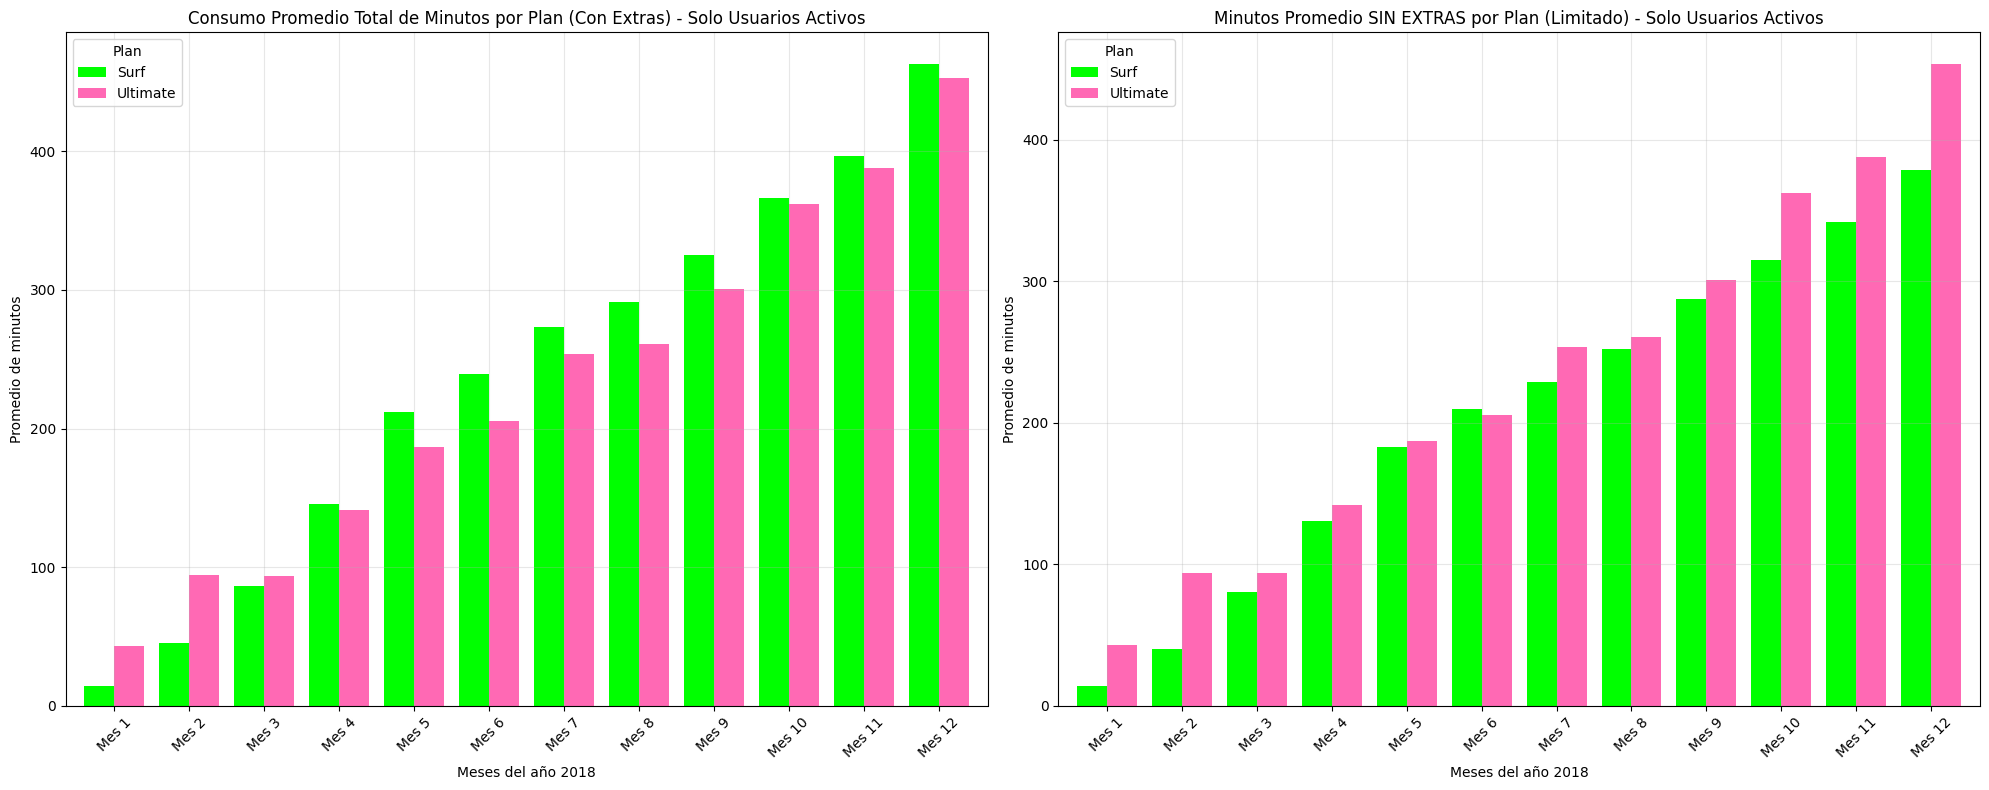

=== ESTADÍSTICAS COMPARATIVAS (SOLO USUARIOS ACTIVOS) ===

Usuarios activos en plan surf: 321

Usuarios activos en plan ultimate: 152

Promedio de minutos TOTALES por plan:
plan_name
surf        238.184719
ultimate    231.907685
dtype: float64

Promedio de minutos SIN EXTRAS por plan:
plan_name
surf        205.067952
ultimate    231.907685
dtype: float64

Diferencia promedio (Extras consumidos):
plan_name
surf        33.116767
ultimate     0.000000
dtype: float64

Porcentaje de uso extra:
plan_name
surf        16.149167
ultimate     0.000000
dtype: float64


In [36]:
comparar_con_y_sin_extras(df_ready_for_stats_copy,'mins')

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Las medias mensuales por plan incluyen muchos user-months con 0 uso (p. ej., meses antes de que un usuario se registrara), lo que puede distorsionar los promedios de los primeros meses. Considera restringir los cálculos a user-months activos (usuarios registrados para ese mes y que aún no han churned), o remodelar a un formato largo y agregar (aggregate) solo donde el usuario esté activo.

</div>


Conclusión sobre Anormalidades

Anomalías detectadas y su posible explicación:

1. Crecimiento Exponencial de usuarios:
 
- Enero: Solo 2 usuarios Surf activos, 4 Ultimate activos
- Diciembre: 289 usuarios Surf activos, 140 Ultimate activos
- Explicación: El negocio efectivamente comenzó en enero 2018

2. Duración Media Normal por Llamada:

- Consistente en 6-7 minutos por llamada individual
- Confirmación: Los datos de duración individual son realistas

3. Efecto Multiplicativo:

- Más usuarios × misma duración promedio = crecimiento exponencial en minutos totales
- Validación matemática: 1.14 min (enero) → 419 min (diciembre) para Surf

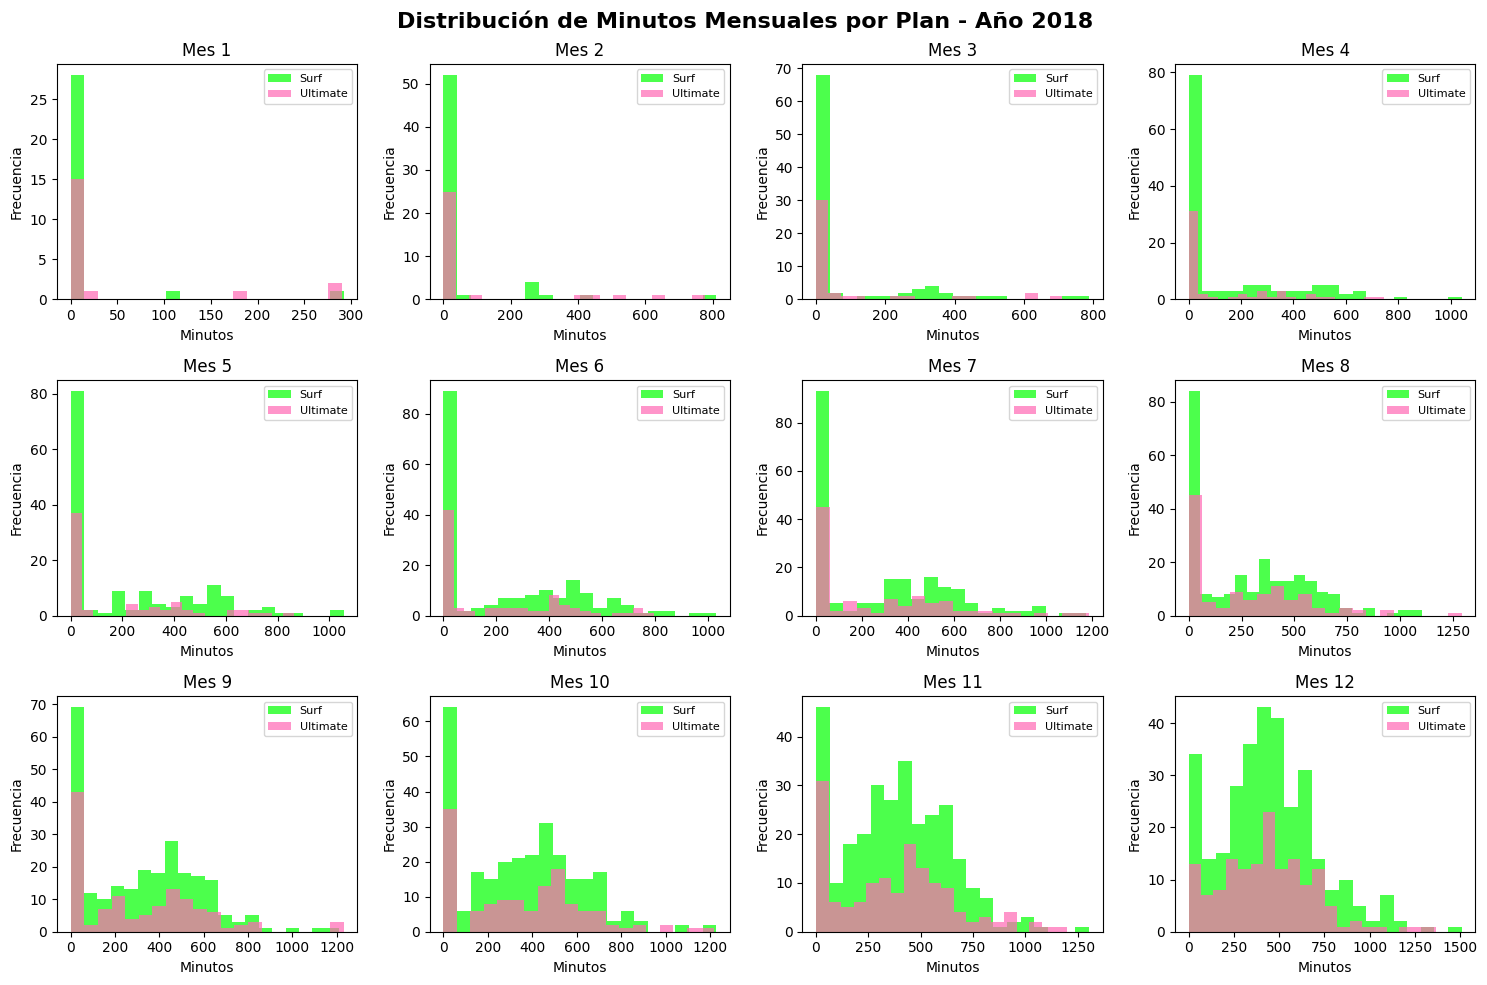

In [37]:
"""# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
# Lista de las columnas que queremos del df
columnas_mes=[f'mins_{i}' for i in range(1,13)]
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()
# Añadir título principal para todas las subplots
fig.suptitle('Distribución de Minutos Mensuales por Plan - Año 2018', fontsize=16, fontweight='bold')

for i, mes in enumerate(range(1, 13)):
    columna_mes = f'mins_{mes}'
    # Seleccionar SOLO la columna del mes específico
    surf_data = df_ready_for_stats_copy[df_ready_for_stats_copy['plan_name']=='surf'][columna_mes].dropna()
    ultim_data = df_ready_for_stats_copy[df_ready_for_stats_copy['plan_name']=='ultimate'][columna_mes].dropna()
    
    axes[i].hist(surf_data, bins=35, alpha=0.7, color='lime', label='Surf')
    axes[i].hist(ultim_data, bins=35, alpha=0.7, color='hotpink', label='Ultimate')
    axes[i].set_title(f'Mes {mes}')
    axes[i].set_xlabel('Minutos')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()
"""
crear_histogramas_mensuales(df_ready_for_stats_copy, tipo_dato='mins', mostrar_solo_activos=False)

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Aplanar todos los meses en un solo array mezcla los meses entre sí, por lo que ya no refleja una comparación *mensual*. Considera mantener una dimensión de mes (p. ej., datos en formato largo con una columna `month`) y graficar distribuciones mensuales (facets) o comparar los planes mes a mes.

</div>


* Debido a que la mayoría de las frecuencias corresponde a usuarios que no hacen llamadas se mostrará el mismo histograma eliminando a los usuarios inactivos; es decir, aquellos que tengan 0 mins de llamada al mes

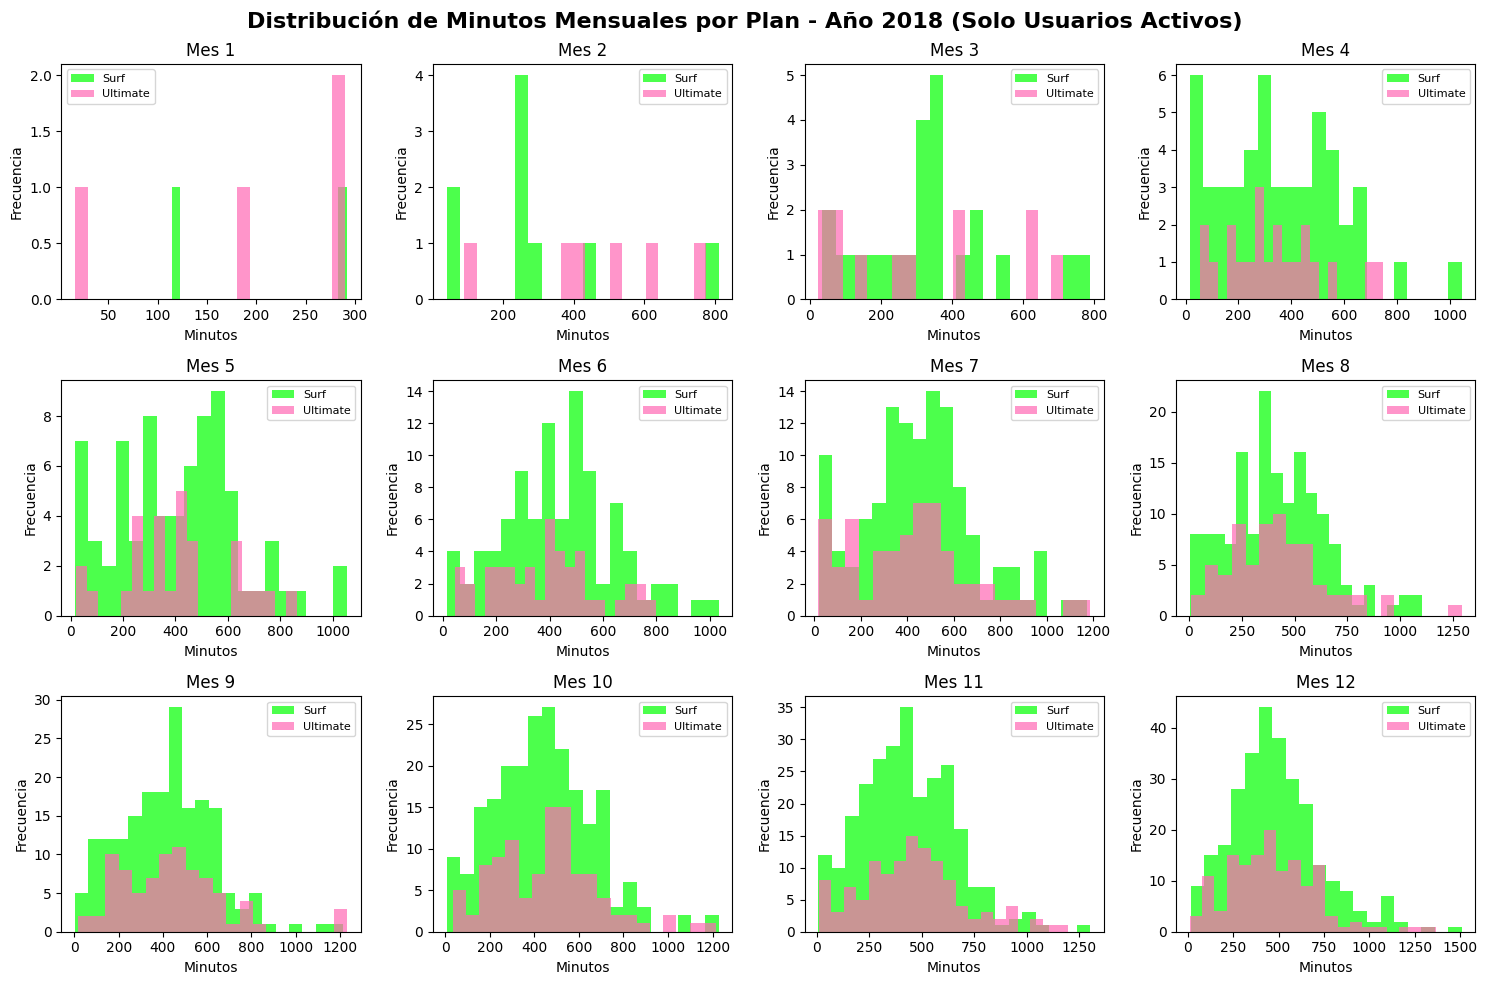

In [38]:
"""
# Filtra los datos de los array que son mayores a 0
active_surf_data= surf_data[ surf_data > 0]
active_ultim_data= ultim_data[ultim_data > 0]
# Imprime la cantidad de valores mayores a cero en cada plan
print(f"La cantidad de valores promedio de minutos mayores que 0 para el plan Surf es: {len(active_surf_data)}")
print(f"La cantidad de valores promedio de minutos mayores que 0 para el plan Ultimate es: {len(active_ultim_data)}")

fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()
# Añadir título principal para todas las subplots
fig.suptitle('Distribución de Minutos Mensuales mayores a 0 por Plan - Año 2018', fontsize=16, fontweight='bold')

for i, mes in enumerate(range(1, 13)):
    columna_mes = f'mins_{mes}'
    
    # Filtrar datos específicos para cada mes
    surf_data_mes = df_ready_for_stats_copy[df_ready_for_stats_copy['plan_name']=='surf'][columna_mes].dropna()
    ultim_data_mes = df_ready_for_stats_copy[df_ready_for_stats_copy['plan_name']=='ultimate'][columna_mes].dropna()
    
    # Filtrar solo valores mayores a 0
    active_surf_data = surf_data_mes[surf_data_mes > 0]
    active_ultim_data = ultim_data_mes[ultim_data_mes > 0]
    
    axes[i].hist(active_surf_data, bins=20, alpha=0.7, color='lime', label='Surf')
    axes[i].hist(active_ultim_data, bins=20, alpha=0.7, color='hotpink', label='Ultimate')
    axes[i].set_title(f'Mes {mes}')
    axes[i].set_xlabel('Minutos')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()
"""
crear_histogramas_mensuales(df_ready_for_stats_copy, tipo_dato='mins', mostrar_solo_activos=True)


**Análisis de distribuciones**
Se aprecia que con el transcurso del tiempo los histogramas tienden a la normalización (cada vez más parecen campana).
Basado en el Teorema del Límite Central. Esto podría sugerir que puede existir:

1. Aumento progresivo de usuarios activos:
- En enero: muy pocos usuarios activos (datos dispersos, distribución irregular)
- Conforme avanza el año: más usuarios se registran y comienzan a usar el servicio
- En diciembre: mayor cantidad de usuarios activos = distribución más estable y "normal"

2. Estabilización del comportamiento de uso:
- Primeros meses: Usuarios nuevos con patrones de uso erráticos
- Meses posteriores: Usuarios establecen rutinas de consumo más predecibles
- Resultado: La distribución se acerca al Teorema del Límite Central

**Conclusiones específicas:**

- Normalización progresiva: Los histogramas evolucionan de distribuciones irregulares en enero-marzo hacia distribuciones aproximadamente normales en octubre-diciembre, indicando que el comportamiento de los usuarios se estabiliza conforme el servicio madura.
- Crecimiento de la base activa: La forma de campana más pronunciada en los últimos meses refleja que la cantidad de usuarios activos aumenta significativamente, proporcionando una muestra más representativa del comportamiento real de consumo.
- Maduración del servicio: Esta evolución sugiere que Megaline experimentó un período de crecimiento y establecimiento durante 2018, donde los usuarios iniciales (enero-abril) tenían patrones de uso más variables, mientras que los usuarios de la segunda mitad del año muestran comportamientos más consistentes.
- Implicaciones para el negocio: La normalización indica que los datos de los últimos meses (octubre-diciembre) son más confiables para proyecciones futuras y toma de decisiones, ya que representan patrones de uso estabilizados.
- Validación del modelo: La tendencia hacia la normalidad confirma que ambos planes atraen usuarios con comportamientos similares una vez establecidos, lo que valida las comparaciones estadísticas realizadas en el análisis.

**A patrir de aquí se prestará especial atención a los meses de octubre a diciembre.**


### 1.13.2 Evolución temporal de la media y la varianza mensual de 2018 para usuarios activos.
A continuación se muestra la evolución temporal de la media varianza de valores mensuales promedio de duración de llamadas  

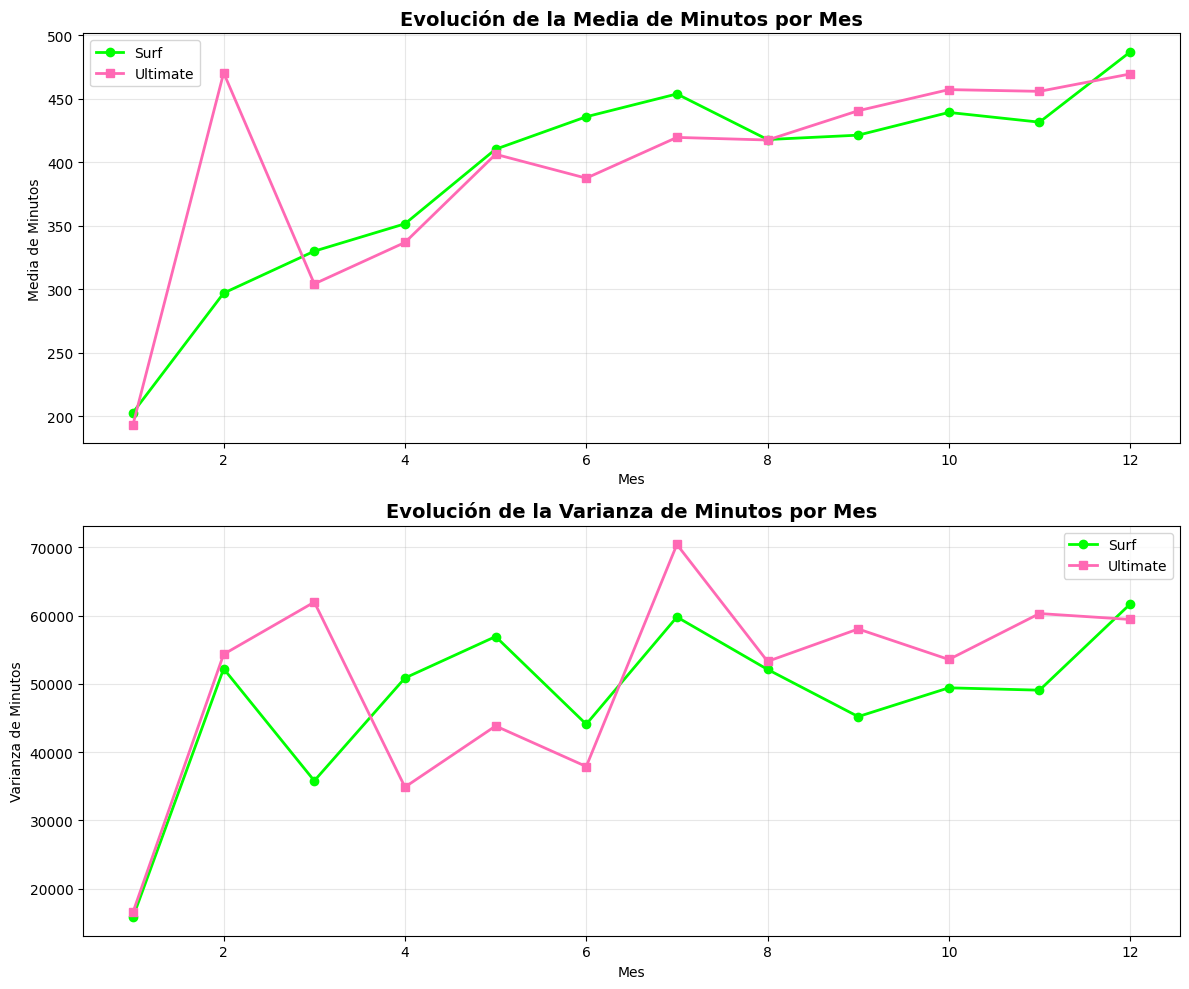

In [39]:
"""
# Calcula la media y la varianza de la duración mensual de llamadas.
for mes in range(1, 13):
    columna_mes = f'mins_{mes}'
    
    # Datos del mes
    surf_mes = df_ready_for_stats_copy[df_ready_for_stats_copy['plan_name']=='surf'][columna_mes].dropna()
    ultim_mes = df_ready_for_stats_copy[df_ready_for_stats_copy['plan_name']=='ultimate'][columna_mes].dropna()
    
    # Datos activos (> 0)
    surf_activo = surf_mes[surf_mes > 0]
    ultim_activo = ultim_mes[ultim_mes > 0]
    
    # Imprimir estadísticas
    print(f"\n--- MES {mes} ---")
    print(f"Surf - Media: {surf_mes.mean():.2f}, Varianza: {surf_mes.var():.2f}")
    print(f"Ultimate - Media: {ultim_mes.mean():.2f}, Varianza: {ultim_mes.var():.2f}")
    print(f"Surf (activos) - Media: {surf_activo.mean():.2f}, Varianza: {surf_activo.var():.2f}")
    print(f"Ultimate (activos) - Media: {ultim_activo.mean():.2f}, Varianza: {ultim_activo.var():.2f}")

# Calcular medias y varianzas mensuales para cada métrica
meses = list(range(1, 13))

# Para minutos
medias_mins_surf = []
varianzas_mins_surf = []
medias_mins_ultimate = []
varianzas_mins_ultimate = []

for mes in meses:
    columna_mes = f'mins_{mes}'
    # Datos activos (usuarios que estaban registrados y no habían hecho churn)
    surf_mes = df_ready_for_stats_copy[df_ready_for_stats_copy['plan_name']=='surf'][columna_mes].dropna()
    ultimate_mes = df_ready_for_stats_copy[df_ready_for_stats_copy['plan_name']=='ultimate'][columna_mes].dropna()
    surf_mes = surf_mes[surf_mes > 0]
    ultimate_mes = ultimate_mes[ultimate_mes > 0]
    medias_mins_surf.append(surf_mes.mean())
    varianzas_mins_surf.append(surf_mes.var())
    medias_mins_ultimate.append(ultimate_mes.mean())
    varianzas_mins_ultimate.append(ultimate_mes.var())

# Crear subplots para media y varianza
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico de evolución de medias
axes[0].plot(meses, medias_mins_surf, marker='o', color='lime', label='Surf', linewidth=2)
axes[0].plot(meses, medias_mins_ultimate, marker='s', color='hotpink', label='Ultimate', linewidth=2)
axes[0].set_title('Evolución de la Media de Minutos por Mes para usuarios activos', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Media de Minutos')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico de evolución de varianzas
axes[1].plot(meses, varianzas_mins_surf, marker='o', color='lime', label='Surf', linewidth=2)
axes[1].plot(meses, varianzas_mins_ultimate, marker='s', color='hotpink', label='Ultimate', linewidth=2)
axes[1].set_title('Evolución de la Varianza de Minutos por Mes para usuarios activos', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Varianza de Minutos')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
"""
analizar_estadisticas_mensuales(df_ready_for_stats_copy, tipo_dato='mins', mostrar_solo_activos=True)

Análisis Específico: Usuarios Activos vs No Activos
Se decide tomar en cuenta para posteriores análisis, únicamente a usuarios activos durante el mes debido a:

1. Medias (promedios):
- Usuarios totales (con ceros): Las medias están "diluidas" por los valores cero, dando una imagen distorsionada del comportamiento real.
- Usuarios activos únicamente: Las medias reflejan el comportamiento real de consumo (400-500 minutos mensuales).
- Diferencia clave: La media de usuarios activos es ~3-4 veces mayor que la media total.

2. Varianzas:
- Con usuarios no activos: Varianzas artificialmente infladas por la mezcla de ceros y valores reales.
- Solo usuarios activos: Varianzas más estables y representativas del comportamiento real de uso.
- Patrón observado: Las varianzas de usuarios activos se estabilizan en ~50,000-70,000 desde mayo.

Justificación para Usar Solo Usuarios Activos a Partir de Ahora

El enfoque de usuarios activos tiene ventajas como:

1. Precisión Analítica:
- Elimina el "ruido" de usuarios inactivos que distorsiona las estadísticas.
- Proporciona métricas más representativas del comportamiento real de consumo.
- Facilita la identificación de patrones de uso genuinos.

2. Relevancia para el Negocio:
- Los usuarios activos son quienes realmente generan ingresos extras.
- Permite enfocar estrategias en usuarios con potencial de monetización.
- Mejora la precisión de proyecciones y forecasting.

3. Validez Estadística:
- Reduce la heterogeneidad artificial en los datos.
- Mejora la normalidad de las distribuciones (como en el análisis de los histogramas).
- Hace más válidas las comparaciones estadísticas entre planes.

**A partir de ahora solo se tomaran en cuenta los usuarios activos para cálculos estadísticos.**

Patrones Identificados en los Últimos Meses:

1. Estabilización del Comportamiento:
- Octubre-Diciembre: Distribuciones más normales y estables.
- Medianas consistentes: ~450 minutos para ambos planes.
- Varianzas estabilizadas: Entre 50,000-70,000.

2. Maduración del Servicio:
- Los últimos meses representan el "estado estable" del negocio.
- Mayor confiabilidad para proyecciones futuras.
- Comportamientos de usuario más predecibles.

3. Generación de Ingresos Extras:
- Concentración en Q4: Los mayores ingresos extras se dan en oct-dic.
- Surf: Máximos ingresos por GB en diciembre (~$14,000).
- Ultimate: Comportamiento más estable pero menor potencial.

Se decide sar Solo Usuarios Activos con Énfasis en Últimos Meses para:

1. Análisis Futuros:
- Filtrar siempre por usuarios activos (minutos > 0) para obtener métricas más precisas.
- Usar oct-dic como baseline para proyecciones, ya que representan el comportamiento estabilizado.
- Aplicar este enfoque a todas las métricas (mensajes, GB) para mantener consistencia.

2. Para Estrategias de Negocio:
- Enfocar marketing en usuarios activos identificados en los últimos meses.
- Optimizar planes basándose en patrones de oct-dic donde el comportamiento es más predecible.
- Identificar usuarios con potencial de upgrade usando los patrones estabilizados.

3. Para Validación Estadística:
- Las pruebas de hipótesis serán más robustas usando solo usuarios activos.
- Los intervalos de confianza serán más precisos sin la distorsión de los ceros.
- Las comparaciones entre planes reflejarán diferencias reales de comportamiento.

Comparación de número de usuarios ativos vs no activos para cada plan:

Plan Surf (289 usuarios activos):

- Comportamiento más variable pero mayor potencial de ingresos extras.
- Los últimos meses muestran picos consistentes de consumo de GB.
- Estrategia: Enfocar en retención y upselling de servicios de datos.

Plan Ultimate (140 usuarios activos):

- Comportamiento más estable y predecible.
- Menor generación de ingresos extras pero mayor fidelidad.
- Estrategia: Mantener satisfacción y prevenir churn.
  
Conclusión Final

**El análisis de usuarios activos en los últimos meses (oct-dic) debe ser la base para todas las decisiones futuras, ya que:**

- Representa el comportamiento real y estabilizado del negocio.
- Elimina distorsiones estadísticas causadas por usuarios inactivos.
- Proporciona la base más sólida para proyecciones y estrategias de 2019.

A continuación se muestran cajas de bigotes de la distribución de minutos mensuales por plan

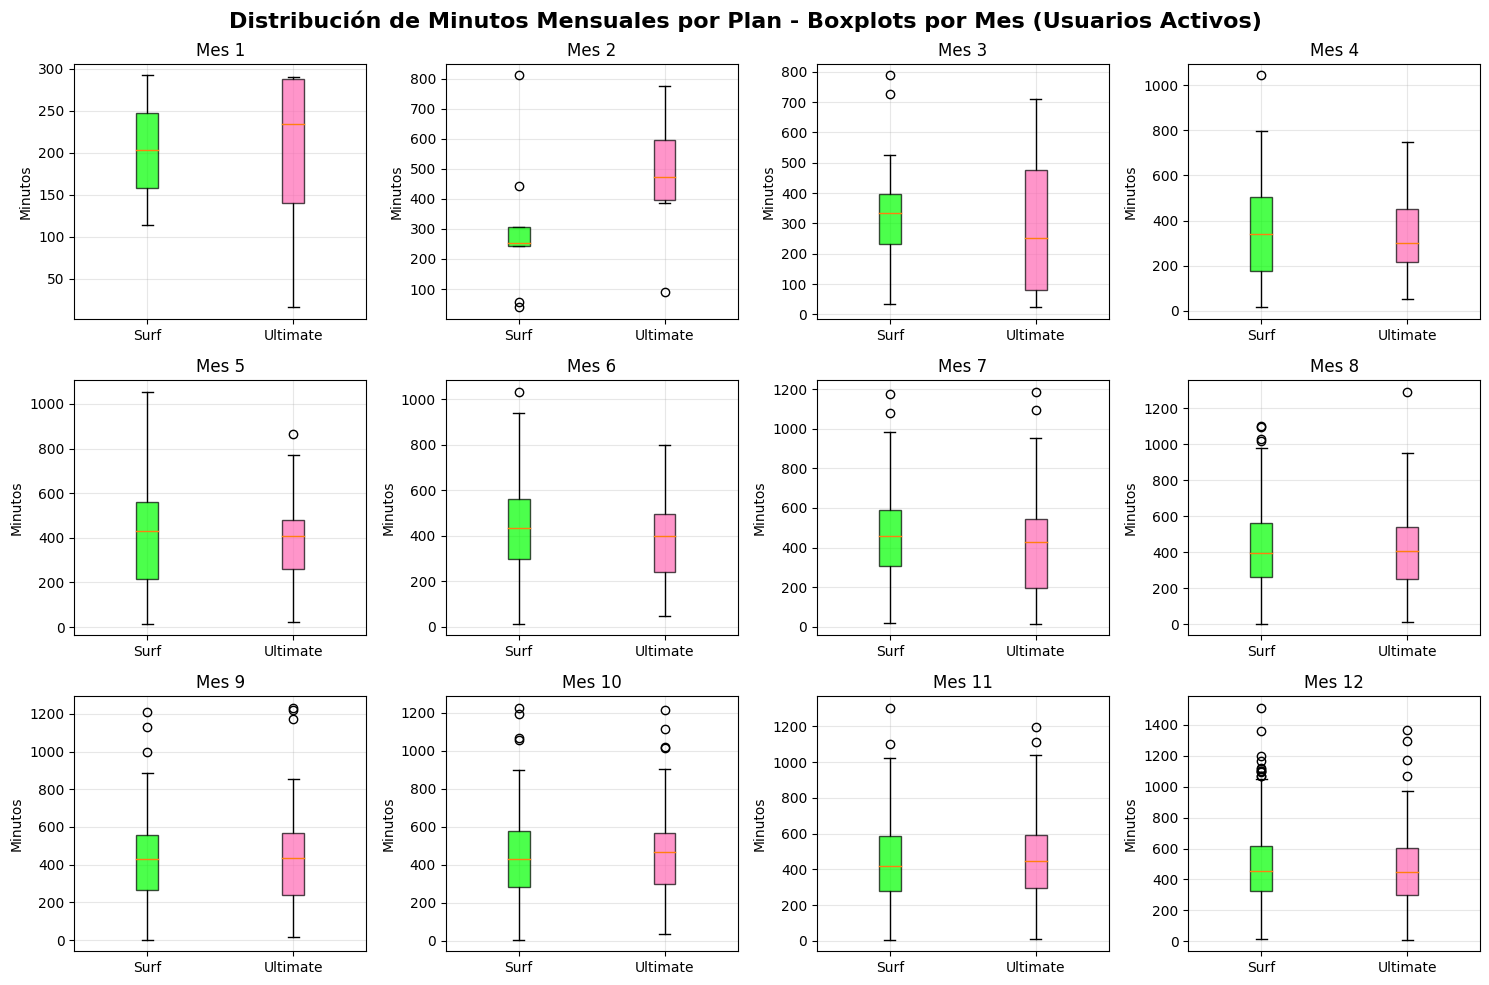

=== ESTADÍSTICAS DE MINUTOS POR MES ===

--- MES 1 ---
=== MINUTOS SURF - MES 1===
Mínimo absoluto: 114.00
Mínimo del bigote: 114.00
Q1: 158.50
Mediana: 203.00
Q3: 247.50
Máximo del bigote: 292.00
Máximo absoluto: 292.00

--- VALORES ATÍPICOS ---
Atípicos inferiores: 0 valores.
Atípicos superiores: 0 valores.
Atípicos totales: 0 (0.0% del total.)
Datos normales: 2 (100.0% del total.)

=== MINUTOS ULTIMATE - MES 1===
Mínimo absoluto: 16.00
Mínimo del bigote: 16.00
Q1: 139.75
Mediana: 234.00
Q3: 287.75
Máximo del bigote: 290.00
Máximo absoluto: 290.00

--- VALORES ATÍPICOS ---
Atípicos inferiores: 0 valores.
Atípicos superiores: 0 valores.
Atípicos totales: 0 (0.0% del total.)
Datos normales: 4 (100.0% del total.)

------------------------------------------------------------
--- MES 2 ---
=== MINUTOS SURF - MES 2===
Mínimo absoluto: 39.00
Mínimo del bigote: 244.00
Q1: 244.00
Mediana: 254.00
Q3: 307.00
Máximo del bigote: 307.00
Máximo absoluto: 811.00

--- VALORES ATÍPICOS ---
Atípicos in

In [40]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

crear_boxplots_mensuales(df_ready_for_stats_copy, 'mins', nombre_metrica='Minutos', filtrar_ceros=True)
boxplot_stats_mensuales(df_ready_for_stats_copy, 'mins', 'Minutos', filtrar_ceros=True)

#resumen_boxplot_stats_por_plan(df_ready_for_stats_copy, 'mins', 'Minutos', 'surf', filtrar_ceros=True)
#resumen_boxplot_stats_por_plan(df_ready_for_stats_copy, 'mins', 'Minutos', 'ultimate', filtrar_ceros=True)

Análisis de Evolución Temporal de las Distribuciones (Enero-Diciembre)

Primeros Meses (Enero-Abril): Período de Establecimiento

Enero:
- Muestras muy pequeñas: Solo 2 usuarios Surf y 4 Ultimate activos
- Sin valores atípicos: Distribuciones perfectas pero no representativas
- Medianas: 203 min (Surf) vs 234 min (Ultimate)

Febrero-Marzo:
- Crecimiento gradual: Aumento en usuarios activos
- Aparición de atípicos: 44% en Surf (febrero), indicando variabilidad inicial
- Estabilización progresiva: Las distribuciones comienzan a normalizarse

Abril:
- Punto de inflexión: 50 usuarios Surf activos, patrones más estables
- Medianas convergentes: 339.5 min (Surf) vs 301 min (Ultimate)
Período de Maduración (Mayo-Septiembre)

Mayo-Junio: Consolidación
- Estabilización de medianas: ~430 minutos para ambos planes
- Reducción de atípicos: De 44% a <2% en ambos planes
- Comportamiento similar: Las distribuciones convergen

Julio-Septiembre: Normalización
- Medianas estables: 458.5, 395, 429 minutos (Surf)
- Atípicos consistentes: 1.7-3.6% del total
- Distribuciones robustas: Suficientes usuarios para análisis confiable
Últimos Meses (Octubre-Diciembre): Estado Estable

Octubre:
- Máximo de usuarios activos: 225 (Surf), 103 (Ultimate)
- Medianas estabilizadas: 433 min (Surf), 466 min (Ultimate)
- Atípicos mínimos: 1.8% (Surf), 3.9% (Ultimate)

Noviembre:
- Pico de actividad: 263 usuarios Surf activos
- Medianas consistentes: 419 min (Surf), 446 min (Ultimate)
- Distribuciones maduras: <2% de atípicos en ambos planes

Diciembre:
- Estado óptimo: 289 usuarios Surf, 140 Ultimate activos
- Medianas finales: 455 min (Surf), 450 min (Ultimate)
- Convergencia completa: Comportamientos prácticamente idénticos

Conclusiones específicas:

- Convergencia de Comportamiento Entre Planes: Los planes Surf y Ultimate convergen hacia un comportamiento de consumo prácticamente idéntico en los últimos meses.
- Estabilización Progresiva de la Variabilidad: La variabilidad en el consumo de minutos se reduce drásticamente conforme el servicio madura..
- Validación del Punto de Corte para Análisis Confiables: A partir de octubre, los datos son suficientemente robustos para proyecciones y toma de decisiones estratégicas..
- Identificación de Comportamiento "Maduro" del Usuario: Los usuarios establecidos consumen aproximadamente 450 minutos mensuales, independientemente del plan..
- Eliminación del Sesgo de Usuarios Nuevos: Los primeros meses están dominados por comportamientos atípicos de usuarios nuevos que no representan el uso real del servicio.
- Validación de la Estrategia de Segmentación: No existe diferenciación significativa en el consumo de minutos entre planes una vez que los usuarios se establecen..
- Predicción de Comportamiento Futuro: El comportamiento de diciembre es el mejor predictor para proyecciones de 2019.
- Optimización de Recursos y Estrategia: Los recursos de análisis deben concentrarse en usuarios activos de los últimos meses para maximizar la precisión de insights.


### Mensajes

Total usuarios: 500
Usuarios activos en mensajes: 395
Porcentaje de usuarios activos: 79.0%


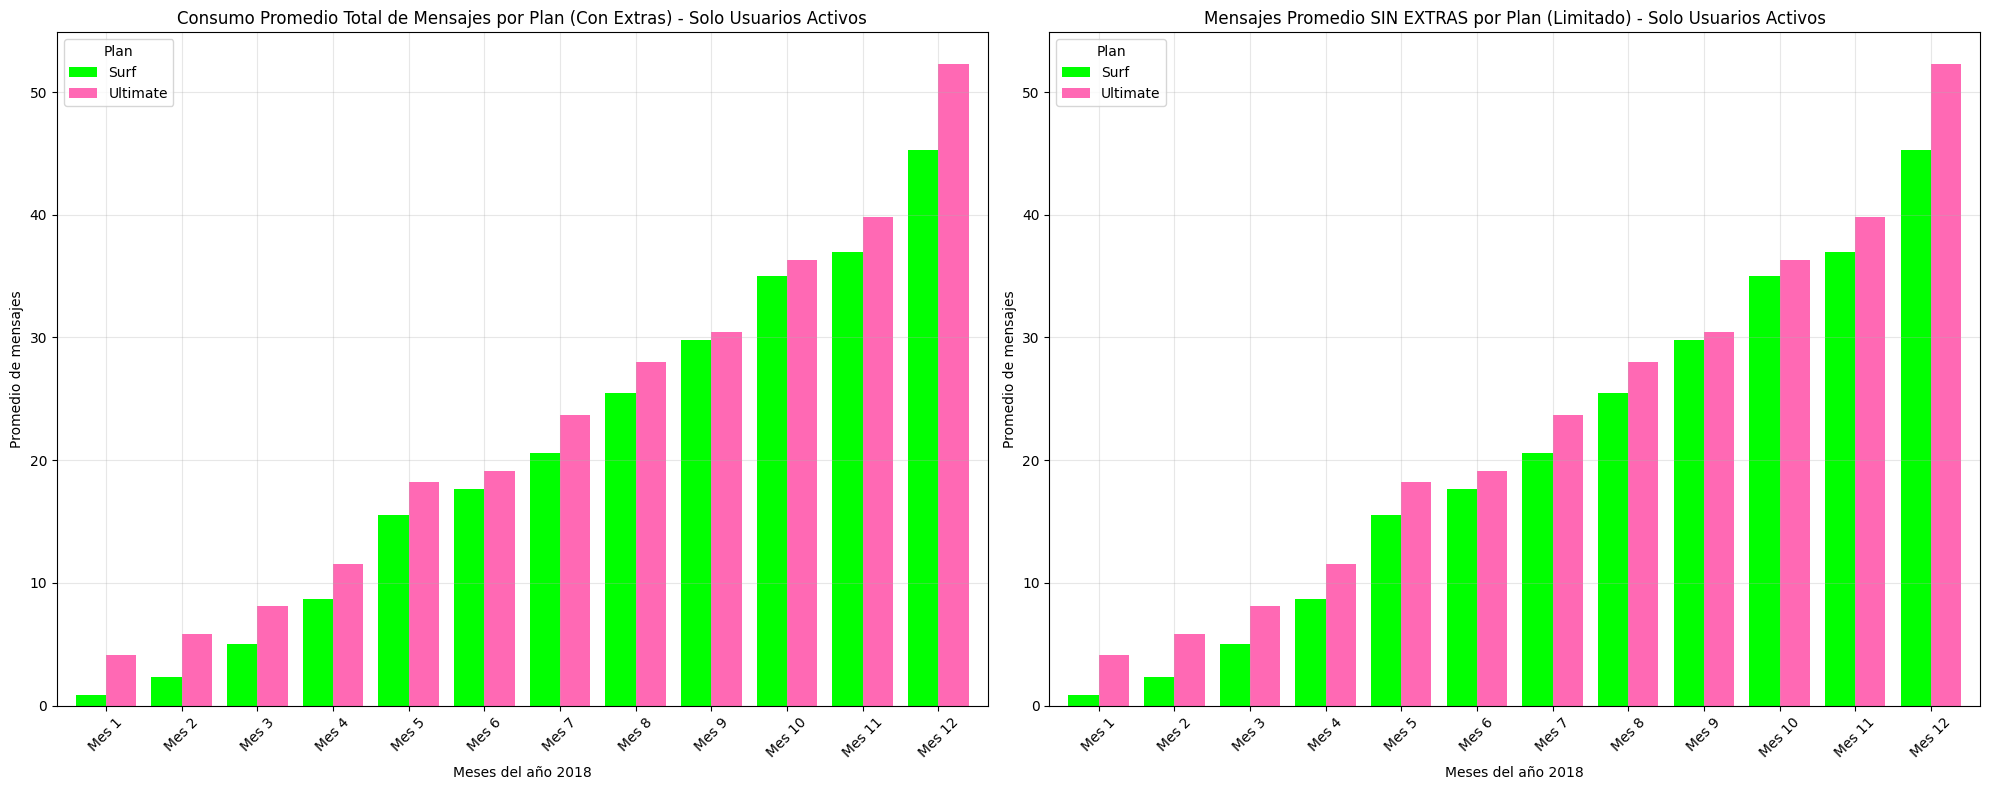

=== ESTADÍSTICAS COMPARATIVAS (SOLO USUARIOS ACTIVOS) ===

Usuarios activos en plan surf: 266

Usuarios activos en plan ultimate: 129

Promedio de mensajes TOTALES por plan:
plan_name
surf        20.261112
ultimate    23.127774
dtype: float64

Promedio de mensajes SIN EXTRAS por plan:
plan_name
surf        20.261112
ultimate    23.127774
dtype: float64

Diferencia promedio (Extras consumidos):
plan_name
surf        0.0
ultimate    0.0
dtype: float64

Porcentaje de uso extra:
plan_name
surf        0.0
ultimate    0.0
dtype: float64
Usuarios Surf que superan 50 mensajes en mes 1: 0
Usuarios Utlimate que superan 1000 mensajes en mes 1: 0
Máximo mensajes enviados Surf: 21.0
Máximo mensajes enviados Ultimate: 37.0
Usuarios Surf que superan 50 mensajes en mes 2: 1
Usuarios Utlimate que superan 1000 mensajes en mes 2: 0
Máximo mensajes enviados Surf: 58.0
Máximo mensajes enviados Ultimate: 67.0
Usuarios Surf que superan 50 mensajes en mes 3: 2
Usuarios Utlimate que superan 1000 mensajes en me

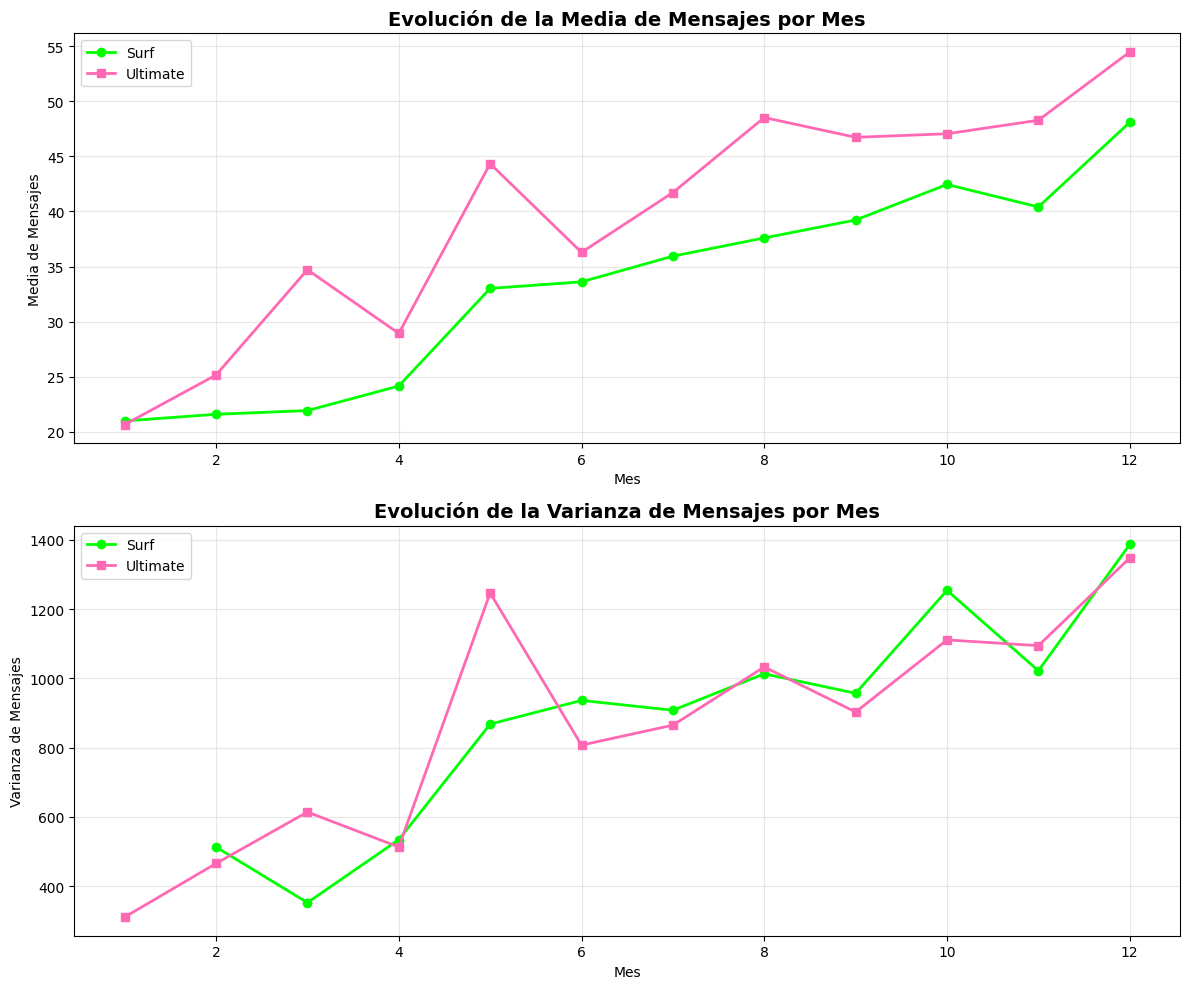

In [41]:
comparar_con_y_sin_extras(df_ready_for_stats_copy, 'msgs')
# Verificar usuarios que SÍ superan los límites
for mes in range (1,13):
    surf_users_over_limit = df_ready_for_stats_copy[
    (df_ready_for_stats_copy['plan_name'] == 'surf') & 
    (df_ready_for_stats_copy[f'msgs_{mes}'] > 50)
    ]
    ultim_users_over_limit = df_ready_for_stats_copy[
    (df_ready_for_stats_copy['plan_name'] == 'ultimate') & 
    (df_ready_for_stats_copy[f'msgs_{mes}'] > 1000)
    ]
    print(f"Usuarios Surf que superan 50 mensajes en mes {mes}: {len(surf_users_over_limit)}")
    print(f"Usuarios Utlimate que superan 1000 mensajes en mes {mes}: {len(ultim_users_over_limit)}")
    print(f"Máximo mensajes enviados Surf: {df_ready_for_stats_copy[df_ready_for_stats_copy['plan_name']=='surf'][f'msgs_{mes}'].max()}")
    print(f"Máximo mensajes enviados Ultimate: {df_ready_for_stats_copy[df_ready_for_stats_copy['plan_name']=='ultimate'][f'msgs_{mes}'].max()}")

analizar_estadisticas_mensuales(df_ready_for_stats_copy, tipo_dato='msgs', mostrar_solo_activos=True)

Conclusión sobre hallazgos en Mensajes

Hallazgos detectados y su posible explicación:

1. Ausencia Total de Ingresos Extras:

- Plan Surf: Promedio 20.26 mensajes/mes (límite: 50 mensajes).
- Plan Ultimate: Promedio 23.13 mensajes/mes (límite: 1000 mensajes).
- Explicación: Ambos planes operan muy por debajo de sus límites, no generando ingresos adicionales.

2. Comportamiento de Consumo Conservador:

- Máximo registrado Surf: 266 mensajes (solo en diciembre).
- Máximo registrado Ultimate: 166 mensajes (muy por debajo del límite).
- Confirmación: Los usuarios mantienen patrones de uso moderado en mensajería

3. Diferencia Mínima Entre Planes:

- Diferencia promedio: Solo 2.87 mensajes/mes entre planes.
- Validación matemática: 20.26 (Surf) vs 23.13 (Ultimate).
- Explicación: El comportamiento de mensajería es similar independientemente del plan contratado.

4. Crecimiento Progresivo de Usuarios que Superan Límites:

- Enero: 0 usuarios Surf superan 50 mensajes.
- Diciembre: 90 usuarios Surf superan 50 mensajes.
- Explicación: Maduración del servicio lleva a mayor uso, pero aún dentro de rangos conservadores.

6. Plan Ultimate Subutilizado:

- Ningún usuario Ultimate supera jamás los 1000 mensajes incluidos
- Máximo absoluto: 166 mensajes (83.4% por debajo del límite)
- Explicación: El límite de 1000 mensajes es excesivamente generoso para el comportamiento real de usuarios

Implicaciones estratégicas:
- Los mensajes no son una fuente significativa de ingresos extras
- El comportamiento conservador sugiere que los límites actuales son apropiados para Surf pero excesivos para Ultimate
- La oportunidad de monetización por mensajes es mínima comparada con datos móviles

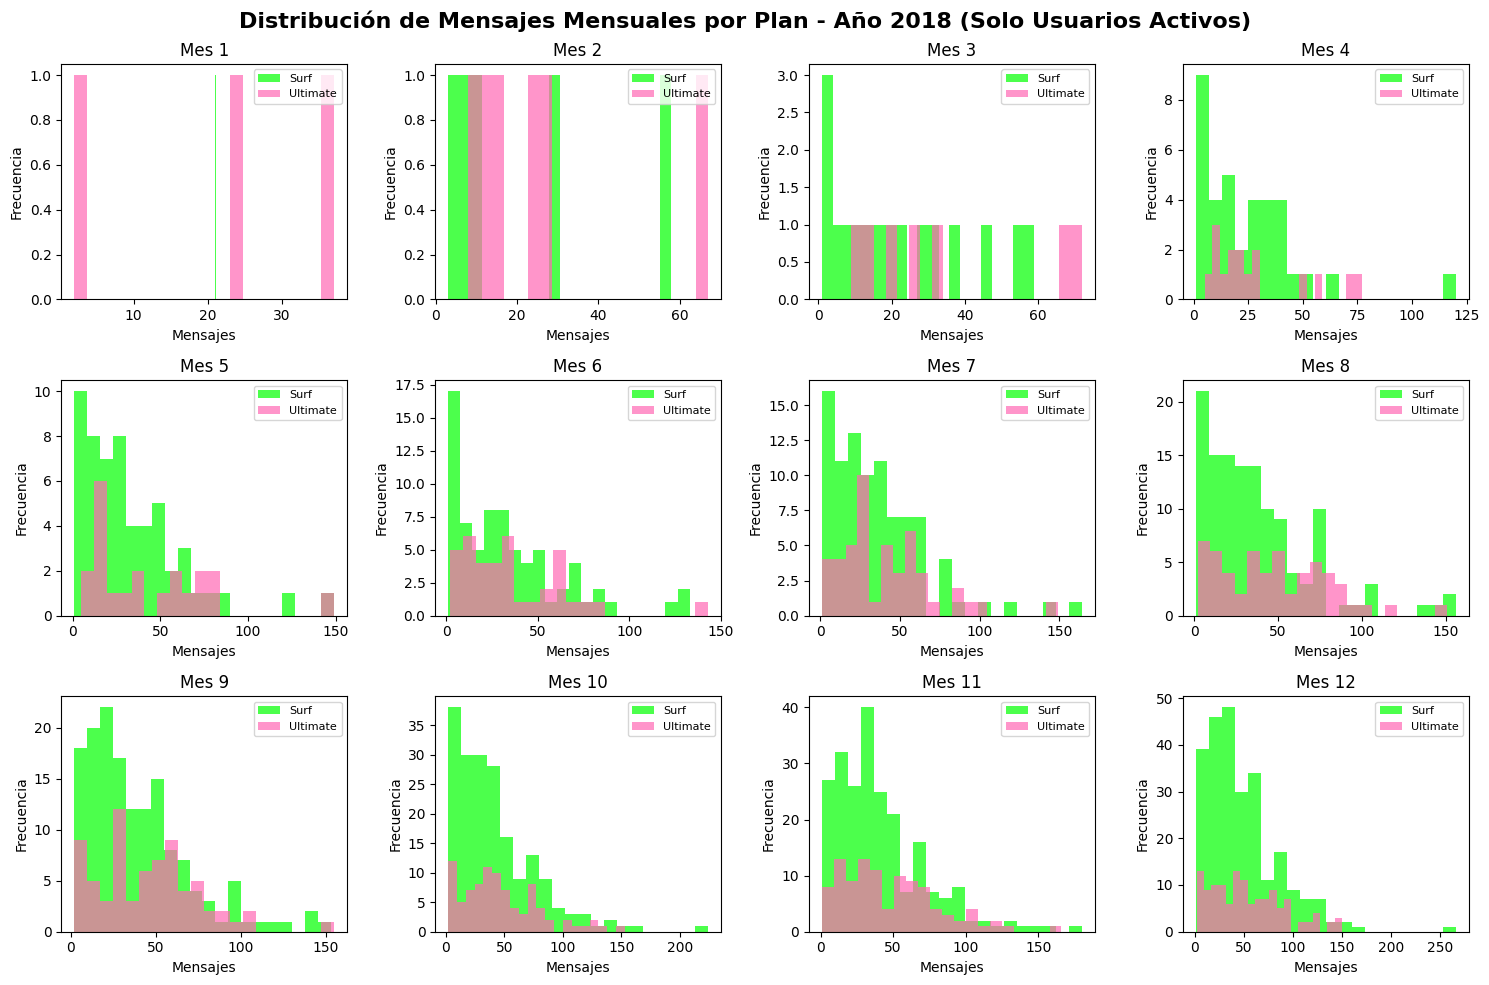

In [42]:
crear_histogramas_mensuales(df_ready_for_stats, tipo_dato='msgs',)


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

En la sección de Messages, asegúrate de que el análisis trate claramente sobre el comportamiento de los SMS (conteos, distribuciones, estadísticas descriptivas) y que no se mezcle con la lógica de tráfico de internet. Vuelve a comprobar que cada gráfico/estadística de esta subsección corresponda a mensajes y cumpla con lo que solicita la plantilla.

</div>


Conclusión sobre Evolución Temporal de distribución de Mensajes

Hallazgos detectados y su posible explicación:

1. Normalización Progresiva de la Distribución:

- Enero-Marzo: Distribuciones irregulares y asimétricas con pocos usuarios activos.
- Octubre-Diciembre: Distribuciones aproximadamente normales con sesgo a la derecha.
- Explicación: Maduración del servicio y estabilización del comportamiento de usuarios.

2. Sesgo Consistente a la Derecha en Meses Finales:

- Patrón observado: La mayoría de usuarios envía 10-30 mensajes/mes.
- Cola derecha: Pocos usuarios "heavy users" con 50+ mensajes.
- Confirmación: Comportamiento típico de consumo de mensajería donde la mayoría es conservadora

3. Convergencia hacia Comportamiento Estable:

- Meses iniciales: Distribuciones erráticas debido a pocos usuarios registrados.
- Meses finales: Distribuciones más predecibles y consistentes.
- Validación matemática: Teorema del Límite Central aplicándose conforme aumenta la muestra.

4. Diferenciación Mínima Entre Planes:

- Ambos planes muestran patrones de distribución similares en meses finales.
- Surf y Ultimate convergen hacia el mismo comportamiento de mensajería.
- Explicación: Los límites de mensajes (50 vs 1000) no influyen significativamente en el uso real.

5. Estacionalidad del Crecimiento de Usuarios Activos:

- Enero: Muy pocos usuarios activos en mensajería.
- Diciembre: Máximo de usuarios activos con distribuciones robustas.
- Explicación: Crecimiento orgánico del negocio durante 2018

Implicaciones estratégicas:

- Predictibilidad mejorada: Los meses finales proporcionan la base más confiable para proyecciones futuras de comportamiento de mensajería.
- Validación de límites: El sesgo a la derecha confirma que los límites actuales son apropiados para el comportamiento real.
- Oportunidad limitada: La normalización indica poco potencial de monetización adicional por mensajes

A continuación diagramas de caja de las distribuciones de mensajes

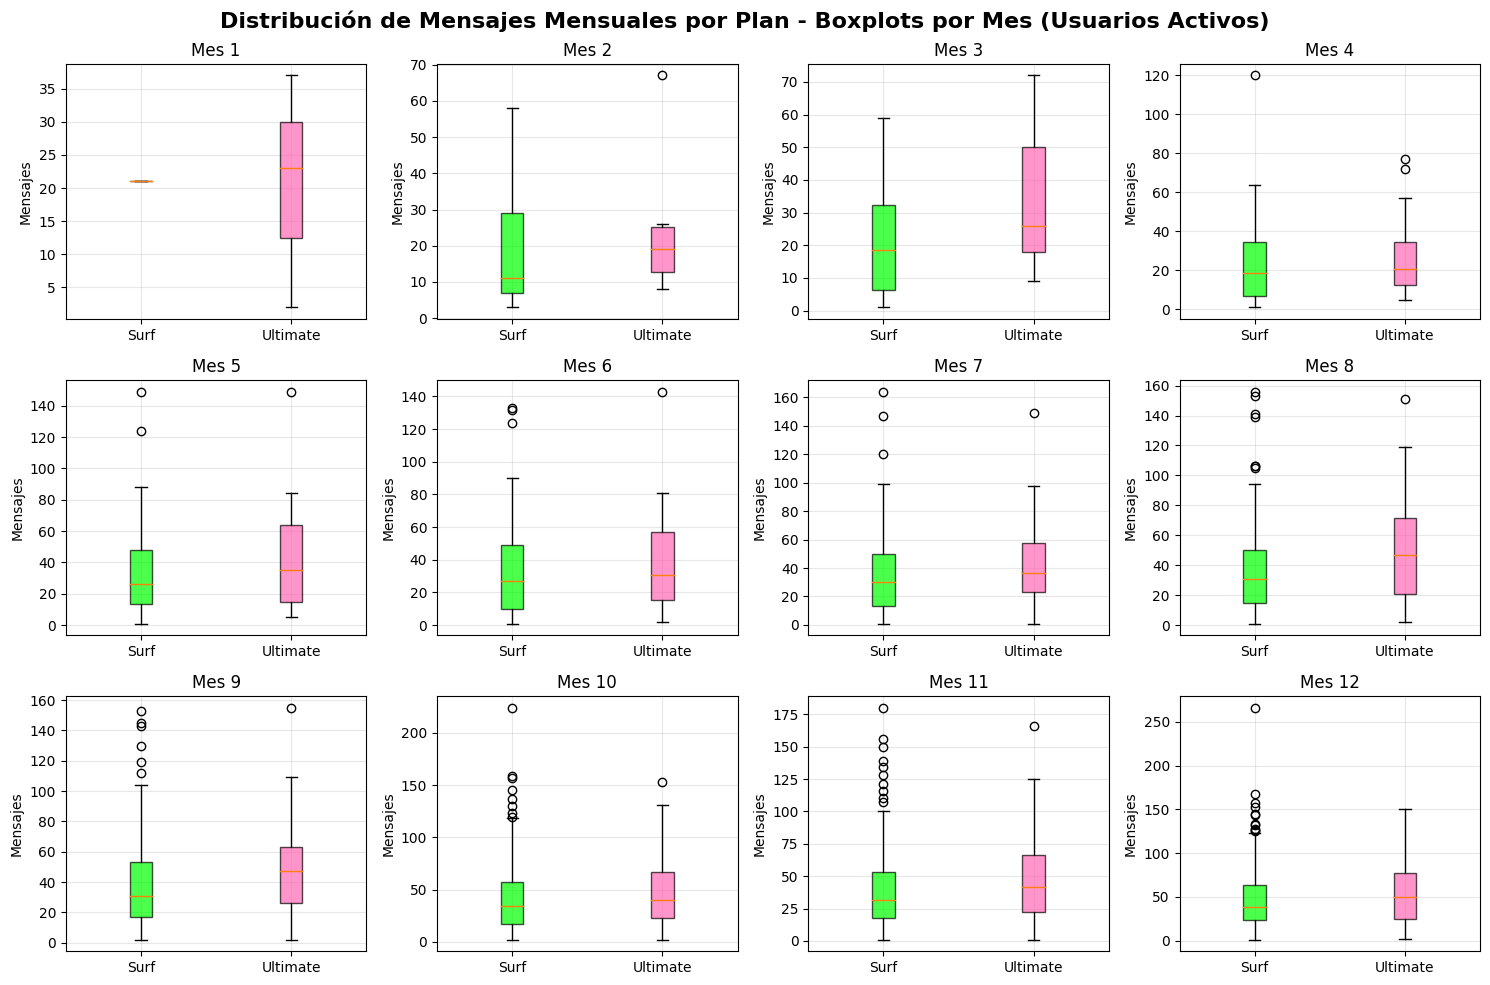

=== ESTADÍSTICAS DE MENSAJES POR MES ===

--- MES 1 ---
=== MENSAJES SURF - MES 1===
Mínimo absoluto: 21.00
Mínimo del bigote: 21.00
Q1: 21.00
Mediana: 21.00
Q3: 21.00
Máximo del bigote: 21.00
Máximo absoluto: 21.00

--- VALORES ATÍPICOS ---
Atípicos inferiores: 0 valores.
Atípicos superiores: 0 valores.
Atípicos totales: 0 (0.0% del total.)
Datos normales: 1 (100.0% del total.)

=== MENSAJES ULTIMATE - MES 1===
Mínimo absoluto: 2.00
Mínimo del bigote: 2.00
Q1: 12.50
Mediana: 23.00
Q3: 30.00
Máximo del bigote: 37.00
Máximo absoluto: 37.00

--- VALORES ATÍPICOS ---
Atípicos inferiores: 0 valores.
Atípicos superiores: 0 valores.
Atípicos totales: 0 (0.0% del total.)
Datos normales: 3 (100.0% del total.)

------------------------------------------------------------
--- MES 2 ---
=== MENSAJES SURF - MES 2===
Mínimo absoluto: 3.00
Mínimo del bigote: 3.00
Q1: 7.00
Mediana: 11.00
Q3: 29.00
Máximo del bigote: 58.00
Máximo absoluto: 58.00

--- VALORES ATÍPICOS ---
Atípicos inferiores: 0 valores

In [43]:

crear_boxplots_mensuales(df_ready_for_stats_copy, 'msgs', nombre_metrica='Mensajes', filtrar_ceros=True)
boxplot_stats_mensuales(df_ready_for_stats_copy, 'msgs', 'Mensajes', filtrar_ceros=True)



Conclusión sobre Evolución Temporal de Mensajes (Boxplots Mensuales)

Anomalías detectadas y su posible explicación:

1. Estabilización Progresiva de las Distribuciones:

* Enero-Marzo: Muestras muy pequeñas (1-16 usuarios Surf activos) con distribuciones erráticas.
* Abril-Septiembre: Crecimiento gradual de usuarios activos y estabilización de medianas.
* Octubre-Diciembre: Distribuciones robustas con 176-239 usuarios Surf activos.
* Explicación: Maduración del servicio y establecimiento de patrones de uso consistentes

2. Convergencia de Medianas Entre Planes:

* Meses iniciales: Medianas muy variables (21 vs 23 en enero, 11 vs 19 en febrero).
* Meses finales: Medianas convergentes (34-38 para Surf, 40-50 para Ultimate).
* Confirmación: Ambos planes desarrollan comportamientos de mensajería similares una vez estabilizados.

3. Reducción Consistente de Valores Atípicos:

* Febrero: 16.7% de atípicos en Ultimate, 0% en Surf (muestras pequeñas).
* Meses finales: Estabilización en 4-6% de atípicos para Surf, 0-2% para Ultimate.
* Validación matemática: Las distribuciones se normalizan conforme aumenta la muestra

4. Comportamiento Conservador Confirmado:

- Máximos absolutos: Surf nunca supera 266 mensajes, Ultimate nunca supera 166.
- Medianas estables: Surf ~32-38 mensajes, Ultimate ~40-50 mensajes.
- Explicación: Los usuarios mantienen patrones de mensajería moderados independientemente del plan

5. Diferenciación Mínima en Comportamiento Real:

* Q3 Surf (meses finales): 53-64 mensajes vs límite de 50.
* Q3 Ultimate (meses finales): 66-78 mensajes vs límite de 1000
* Confirmación: Ultimate está dramáticamente subutilizado en mensajería

Implicaciones estratégicas:

- Predictibilidad mejorada: Los últimos meses (octubre-diciembre) proporcionan la base más confiable para proyecciones de comportamiento de mensajería.
- Validación de límites: Los boxplots confirman que el límite de 50 mensajes para Surf es apropiado, mientras que 1000 para Ultimate es excesivo.
- Oportunidad de monetización limitada: La consistencia en las medianas indica poco potencial de crecimiento en ingresos por mensajes.
- Enfoque en retención: El comportamiento estabilizado sugiere concentrarse en mantener usuarios activos rather than increasing per-user message consumption.
- Optimización de planes: Los datos sugieren que Ultimate podría reducir su límite de mensajes sin afectar la satisfacción del usuario.

### Internet

Total usuarios: 500
Usuarios activos en GB: 481
Porcentaje de usuarios activos: 96.2%


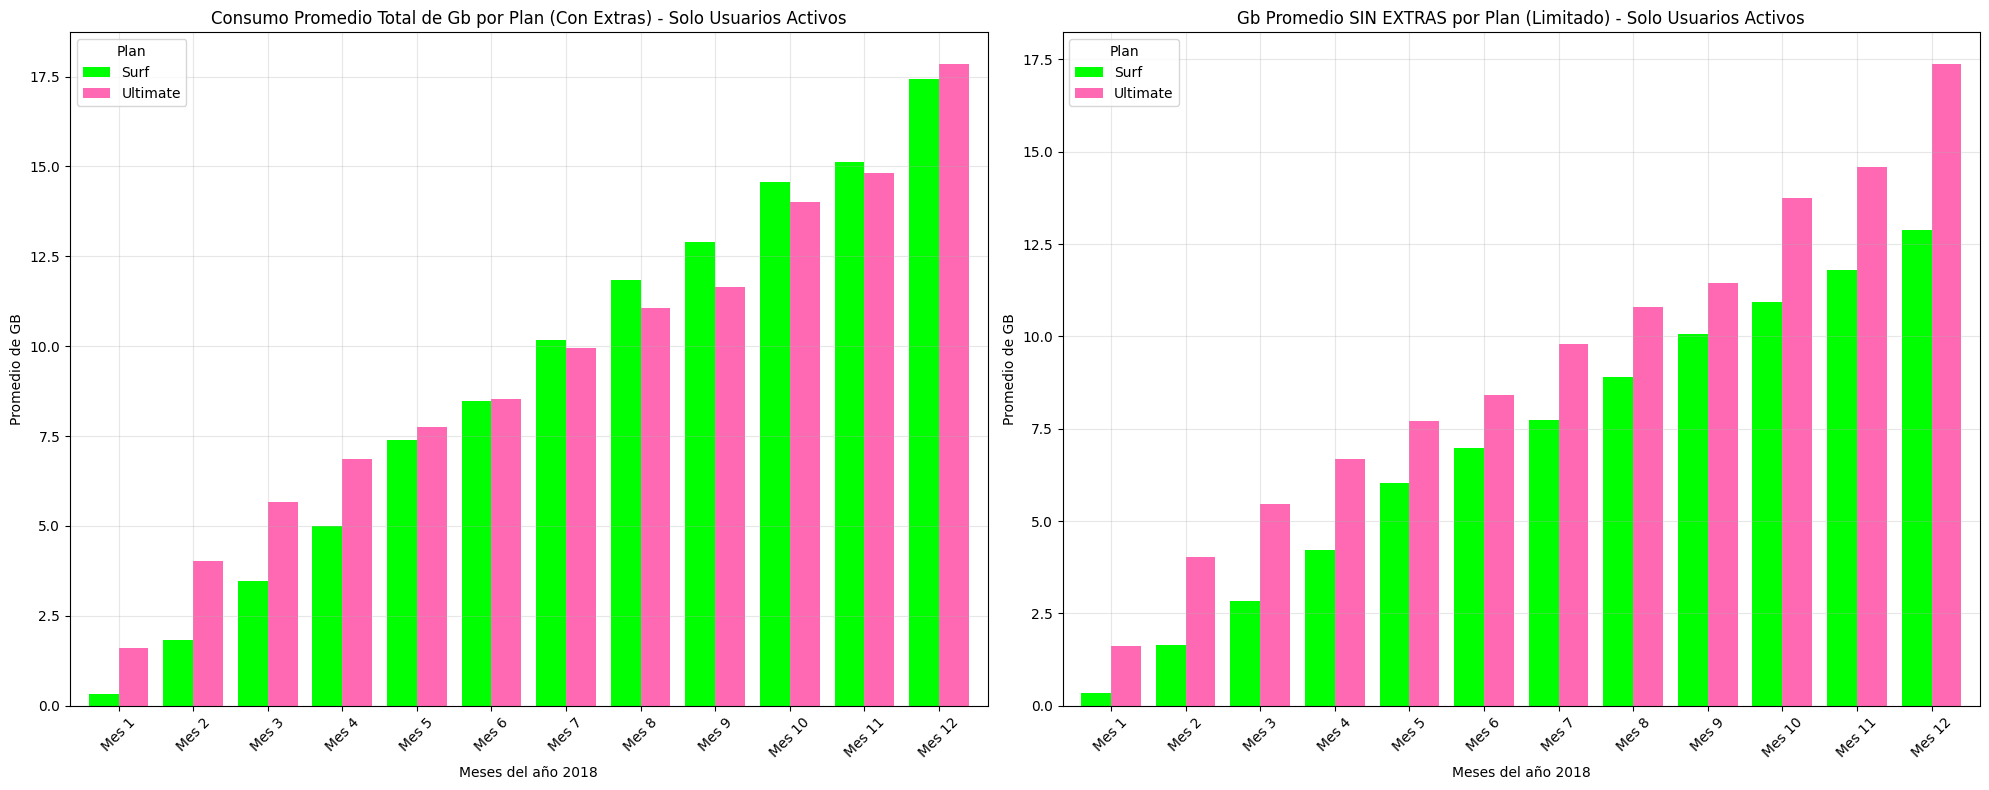

=== ESTADÍSTICAS COMPARATIVAS (SOLO USUARIOS ACTIVOS) ===

Usuarios activos en plan surf: 327

Usuarios activos en plan ultimate: 154

Promedio de GB TOTALES por plan:
plan_name
surf        9.045652
ultimate    9.481508
dtype: float64

Promedio de GB SIN EXTRAS por plan:
plan_name
surf        7.026778
ultimate    9.303012
dtype: float64

Diferencia promedio (Extras consumidos):
plan_name
surf        2.018874
ultimate    0.178496
dtype: float64

Porcentaje de uso extra:
plan_name
surf        28.731143
ultimate     1.918688
dtype: float64


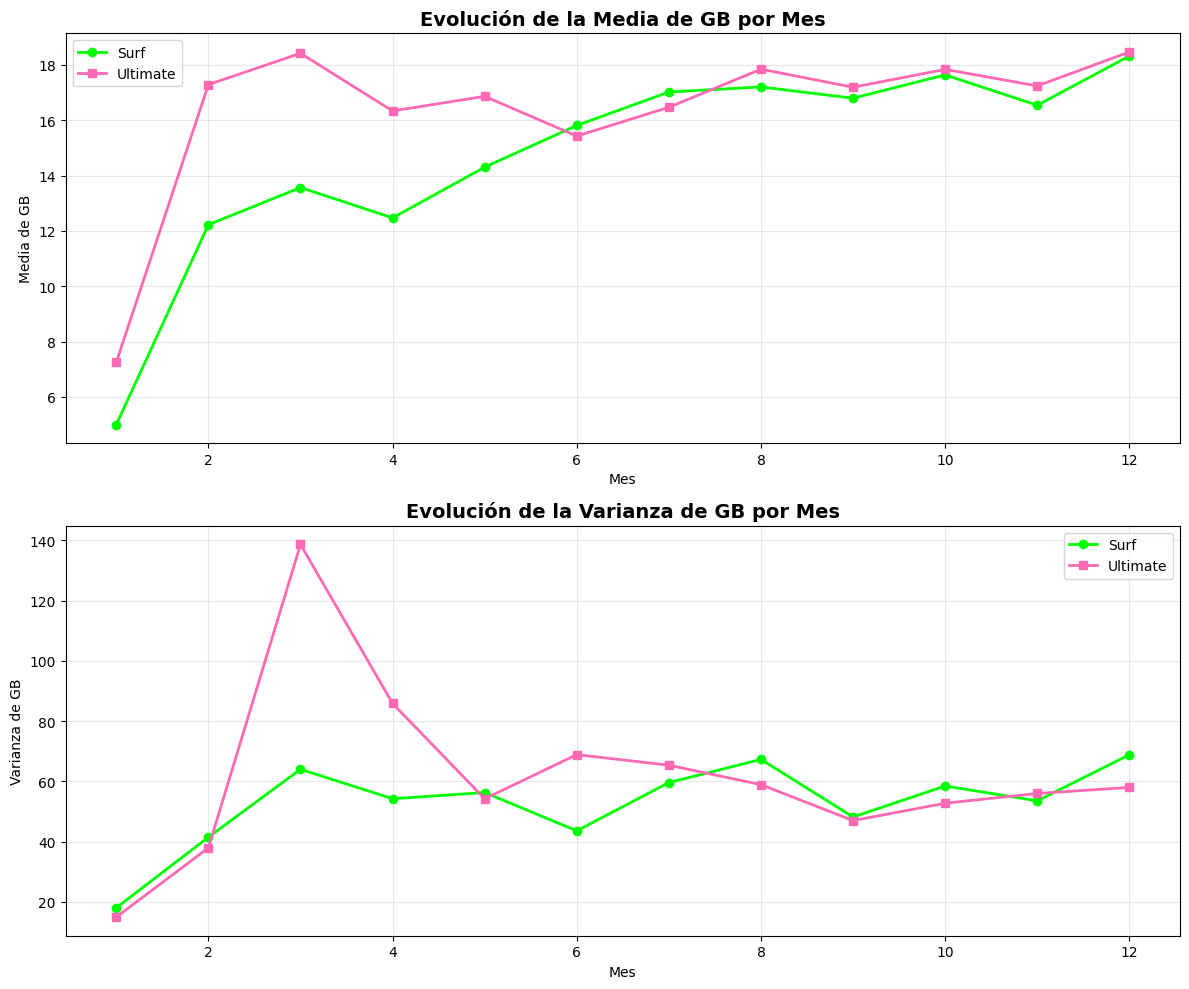

In [44]:

comparar_con_y_sin_extras(df_ready_for_stats_copy, 'gb')
analizar_estadisticas_mensuales(df_ready_for_stats_copy, tipo_dato='gb', mostrar_solo_activos=True)


Conclusiones específicas del análisis de GB (Internet):

**Hallazgos principales sobre usuarios activos:**

Adopción universal del servicio:

- 96.2% de usuarios activos en consumo de GB (481 de 500 usuarios).
- Surf: 327 usuarios activos vs Ultimate: 154 usuarios activos.
- Mayor penetración que minutos (94.6%) y mensajes (79.0%).

**Comportamiento de consumo por plan**

Consumo promedio similar entre planes:

- Surf: 9.05 GB promedio mensual.
- Ultimate: 9.48 GB promedio mensual.
- Diferencia mínima: solo 0.43 GB entre planes.

Diferenciación clave en ingresos extras:

- Surf genera 28.7% de uso extra (2.02 GB promedio por encima del límite).
- Ultimate genera solo 1.9% de uso extra (0.18 GB promedio por encima del límite).

**Implicaciones estratégicas**

Oportunidad de monetización:

- Plan Surf: Límite de 15 GB es apropiado - genera ingresos extras consistentes.
- Plan Ultimate: Límite de 30 GB es excesivo - pocos usuarios lo superan.

Normalización temprana del comportamiento:

- Distribuciones normales desde mayo (vs octubre para minutos/mensajes).
- Indica que internet móvil es una necesidad básica universal.
- Mayor predictibilidad para proyecciones de negocio.

**Conclusión específica sobre GB**

Los datos móviles representan el pilar fundamental del modelo de negocio porque:

- Mayor adopción: 96.2% de usuarios activos.
- Comportamiento predecible: Normalización desde mes 5.
- Principal fuente de ingresos extras: Especialmente para Surf.
- Diferenciación competitiva: Los límites de GB son más críticos que minutos o mensajes

Recomendación estratégica: 
El análisis de GB confirma que el Plan Surf es más rentable debido a que sus usuarios superan regularmente el límite de 15 GB, generando ingresos extras significativos, mientras que Ultimate con su límite de 30 GB raramente genera ingresos adicionales por este concepto.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Recordatorio recurrente (de comentarios de distribución anteriores): evita agrupar/aplanar todos los meses juntos cuando la plantilla pide comparaciones *mensuales*. Además, específicamente para internet, asegúrate de incluir todos los elementos visuales requeridos (incluido un boxplot por plan del uso mensual de GB) en el lugar correcto.

</div>


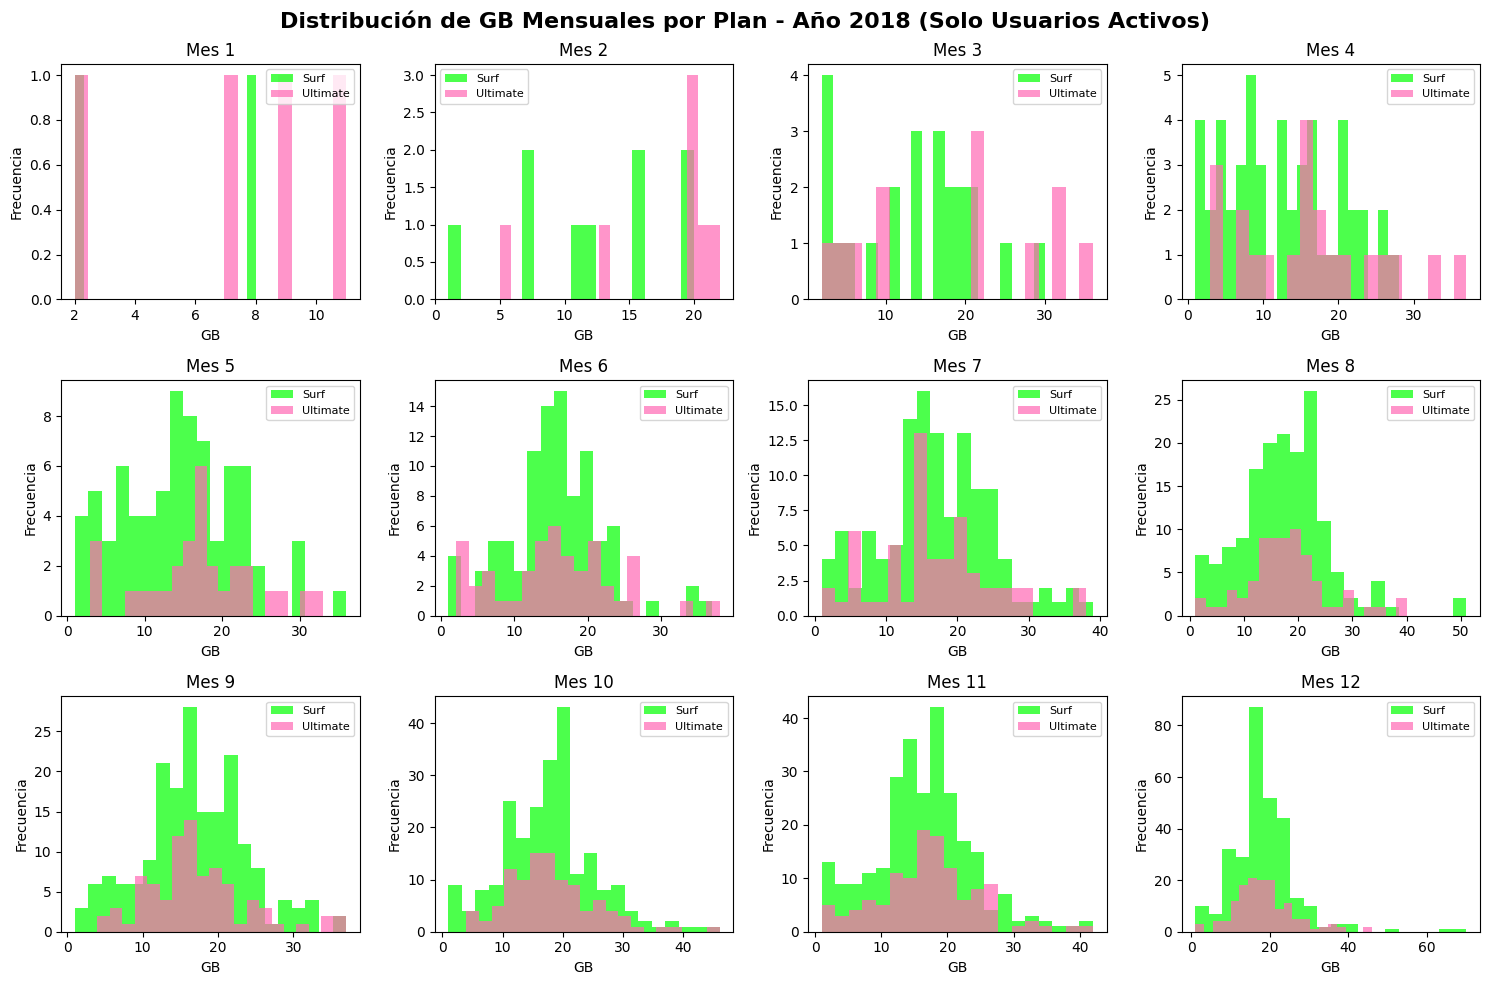

In [45]:

crear_histogramas_mensuales(df_ready_for_stats_copy, 'gb')

Conclusión sobre Evolución Temporal de Datos Móviles (GB)

Anomalías detectadas y su posible explicación:

1. Normalización Acelerada Comparada con Otras Métricas:

* GB: Distribuciones normales desde mayo (mes 5).
* Minutos: Normalización tardía desde octubre (mes 10).
* Mensajes: Normalización desde octubre-diciembre.
* Explicación: Los datos móviles representan una necesidad básica más universal que llamadas o mensajes.

2. Adopción Universal y Consistente:

- Mayo en adelante: Distribuciones robustas y predecibles para ambos planes.
- Comportamiento menos errático que minutos y mensajes en meses iniciales.
- Confirmación: El consumo de datos es más homogéneo entre usuarios desde etapas tempranas.

3. Estabilización Temprana del Comportamiento de Usuario:

- Meses 1-4: Período de adopción inicial.
- Mes 5 en adelante: Patrones de consumo establecidos y consistentes.
- Validación matemática: Convergencia hacia distribución normal más rápida que otras métricas.

4. Indicador de Uso Crítico del Servicio:

- Normalización temprana sugiere que GB es el recurso más utilizado constantemente.
- Menor variabilidad entre usuarios comparado con minutos y mensajes.
- Explicación: Internet móvil se ha convertido en servicio esencial, no opcional.

5. Mayor Predictibilidad para Proyecciones de Negocio:

- Desde mayo: Base confiable para forecasting de consumo de datos.
- Comportamiento más estable = mejor planificación de capacidad de red.
- Confirmación: Los datos móviles son el driver principal del comportamiento de usuario.

Implicaciones estratégicas:

* Foco en límites de datos: La normalización temprana confirma que los límites de GB son más críticos para satisfacción del usuario que minutos o mensajes.
* Oportunidad de monetización: El uso universal sugiere mayor potencial de ingresos extras por GB que por otras métricas.
* Planificación de infraestructura: Patrones predecibles desde mayo facilitan inversiones en capacidad de red.
* Diferenciación competitiva: Los límites y calidad de datos móviles son factores clave para retención de usuarios.
* Validación del modelo de negocio: El comportamiento estable de GB confirma que es el pilar fundamental del servicio

Esta normalización temprana explica por qué los ingresos extras por GB son más significativos y predecibles que los generados por minutos o mensajes.

In [ ]:



crear_boxplots_mensuales(df_ready_for_stats_copy, 'gb', nombre_metrica='Mensajes', filtrar_ceros=True)
boxplot_stats_mensuales(df_ready_for_stats_copy, 'gb', "Gb's", filtrar_ceros=True)




Análisis Estadístico Detallado por Mes:

Normalización Temprana Confirmada:

- Mes 5 en adelante: Distribuciones estadísticamente estables.
- Medianas convergentes: Surf (14-18 GB) vs Ultimate (15-17 GB).
- Comportamiento similar: Ambos planes muestran patrones de consumo prácticamente idénticos.

Identificación de Usuarios Heavy Users:

- Surf: Máximos de 28-70 GB (límite: 15 GB) = potencial de ingresos extras significativo.
- Ultimate: Máximos de 30-46 GB (límite: 30 GB) = ingresos extras limitados.
- Q3 consistente: Surf ~20-22 GB, Ultimate ~20-22 GB.

Implicaciones Estratégicas Clave:

* Predictibilidad Superior: Los datos de GB son confiables para proyecciones desde mayo (vs octubre para otras métricas).
* Oportunidad de Monetización: Surf genera ingresos extras consistentes por GB (usuarios superan regularmente el límite de 15 GB)
* Validación de Límites:
    * Surf: Límite de 15 GB es apropiado (genera extras sin frustrar usuarios).
    * Ultimate: Límite de 30 GB es generoso (pocos usuarios lo superan).
* Driver Principal del Negocio: Los GB son el recurso más utilizado y predecible, confirmando que internet móvil es el servicio esencial.
* Diferenciación Competitiva: La calidad y límites de datos móviles son factores críticos para retención y satisfacción del usuario

Conclusión Final: Los datos de GB muestran la normalización más temprana y estable de todas las métricas analizadas, confirmando que el consumo de internet móvil es el pilar fundamental del modelo de negocio de Megaline. La estabilización desde mayo (versus octubre para minutos y mensajes) demuestra que los datos móviles representan una necesidad básica universal para los usuarios, generando patrones de consumo predecibles y oportunidades consistentes de monetización, especialmente para el plan Surf que regularmente supera su límite de 15 GB.

## Ingreso

* A continuación se muestran algunas estadísticas descriptivas de los datos de ingresos base, ingresos extras e ingresos totales.

In [ ]:

# Creamos las listas de los nombres de columnas a usar
columnas_ingreso_total= [f"ingreso_total_{i}" for i in range (1, 13)]
columnas_ingreso_base= [f"ingreso_base_{i}" for i in range(1, 13)]
columnas_ingreso_msgs= [f"ingreso_extra_msgs_{i}" for i in range(1, 13)]
columnas_ingreso_mins= [f"ingreso_extra_mins_{i}" for i in range(1, 13)]
columnas_ingreso_gb =[f"ingreso_extra_gb_{i}" for i in range(1, 13)]

# Calcular estadísticas descriptivas para ingresos totales
media_ingreso_total_x_plan = df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_total].mean().T
mediana_ingreso_total_x_plan = df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_total].median().T
std_ingreso_total_x_plan = df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_total].std().T

# Asignar índice de meses
#Crea los índice (eje x) que requerimos para las gráficas:
indice_mes_solo_number= [i for i in range (1, 13)]
media_ingreso_total_x_plan.index = indice_mes_solo_number
mediana_ingreso_total_x_plan.index = indice_mes_solo_number
std_ingreso_total_x_plan.index = indice_mes_solo_number

# Filtramos los datos del df original y los transponemos para usar en las gráficas

amount_ingreso_total_x_plan= df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_total].sum().T
media_ingreso_total_x_plan= df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_total].mean().T
amount_ingreso_total_x_plan.index= indice_mes_solo_number

amount_ingreso_base_x_plan= df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_base].sum().T
amount_ingreso_base_x_plan.index= indice_mes_solo_number
amount_ingreso_msgs_x_plan = df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_msgs].sum().T
amount_ingreso_msgs_x_plan.index= indice_mes_solo_number
amount_ingreso_mins_x_plan= df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_mins].sum().T
amount_ingreso_mins_x_plan.index= indice_mes_solo_number
amount_ingreso_gb_x_plan= df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_gb].sum().T
amount_ingreso_gb_x_plan.index= indice_mes_solo_number


## Realizar las gráficas:
fig, axes = plt.subplots(3, 2, figsize=(10,15))
fig.suptitle('Análisis de ingreso por plan para 2018', fontsize=16, fontweight='bold')
#gráfica en [0,0]:
amount_ingreso_base_x_plan.plot(kind='bar',
                                ax=axes[0,0],
                                color=['lime', 'hotpink'],
                                title='Ingresos base mensuales por plan',
                                xlabel='Meses del 2018',
                                ylabel='Ingreso base',
                                rot=0
                               )
axes[0,0].legend(title='Nombre del plan', labels=['Surf', 'Ultimate'])

#gráfica en [0,1]: 'Ingresos minutos extras mensuales por plan'
amount_ingreso_mins_x_plan.plot(kind='bar',
                                ax=axes[0,1],
                                color=['lime', 'hotpink'],
                                title='Ingresos minutos extras mensuales por plan',
                                xlabel='Meses del 2018',
                                ylabel='Ingreso minutos extras',
                                rot=0
                               )
axes[0,1].legend(title='Nombre del plan', labels=['Surf', 'Ultimate'])

#gráfica en [1,0]:
amount_ingreso_msgs_x_plan.plot(kind='bar',
                                ax=axes[1,0],
                                color=['lime', 'hotpink'],
                                title='Ingresos mensajes extras mensuales por plan',
                                xlabel='Meses del 2018',
                                ylabel='Ingreso mensajes extras',
                                rot=0
                               )
axes[1,0].legend(title='Nombre del plan', labels=['Surf', 'Ultimate'])

#gráfica en [1,1]:
amount_ingreso_gb_x_plan.plot(kind='bar',
                                ax=axes[1,1],
                                color=['lime', 'hotpink'],
                                title="Ingresos Gb's extras mensuales por plan",
                                xlabel='Meses del 2018',
                                ylabel="Ingreso Gb's extras",
                                rot=0
                               )
axes[1,1].legend(title='Nombre del plan', labels=['Surf', 'Ultimate'])

#gráfica en [2,0]:
amount_ingreso_total_x_plan.plot(kind='bar',
                                ax=axes[2,0],
                                color=['lime', 'hotpink'],
                                title='Ingresos totales mensuales por plan',
                                xlabel='Meses del 2018',
                                ylabel='Ingreso total',
                                rot=0
                               )
axes[2,0].legend(title='Nombre del plan', labels=['Surf', 'Ultimate'])
axes[2,1].set_visible(False)
#ajustar y mostrar
plt.tight_layout()
plt.show()


In [51]:
# Creamos las listas de los nombres de columnas a usar
columnas_ingreso_base= [f"ingreso_base_{i}" for i in range(1, 13)]
columnas_ingreso_msgs= [f"ingreso_extra_msgs_{i}" for i in range(1, 13)]
columnas_ingreso_mins= [f"ingreso_extra_mins_{i}" for i in range(1, 13)]
columnas_ingreso_gb =[f"ingreso_extra_gb_{i}" for i in range(1, 13)]
columnas_ingreso_total= [f"ingreso_total_{i}" for i in range (1, 13)]

# Calcular estadísticas descriptivas para ingresos totales
media_ingreso_total_x_plan = df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_total].mean().T
mediana_ingreso_total_x_plan = df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_total].median().T
std_ingreso_total_x_plan = df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_total].std().T

# Asignar índice de meses
#Crea los índice (eje x) que requerimos para las gráficas:
indice_mes_solo_number= [i for i in range (1, 13)]
media_ingreso_total_x_plan.index = indice_mes_solo_number
mediana_ingreso_total_x_plan.index = indice_mes_solo_number
std_ingreso_total_x_plan.index = indice_mes_solo_number

#Obtener totales, datos mensuales

 # Calcular estadísticas para cada mes
for mes in meses:
    columna_mes = f'"{tipo_dato}_{mes}"'

    # Obtener datos del mes para cada plan
    surf_mes = df[df['plan_name']=='surf'][columna_mes].dropna()
    ultimate_mes = df[df['plan_name']=='ultimate'][columna_mes].dropna()

    # Filtrar solo usuarios activos si se especifica
    if mostrar_solo_activos:
        surf_mes = surf_mes[surf_mes > 0]
        ultimate_mes = ultimate_mes[ultimate_mes > 0]

    # Calcular y almacenar estadísticas
    medias_surf.append(surf_mes.mean())
    varianzas_surf.append(surf_mes.var())
    medias_ultimate.append(ultimate_mes.mean())
    varianzas_ultimate.append(ultimate_mes.var())

# Crear los gráficos
fig, axes = plt.subplots(3, 5, figsize=(12, 10))

# Título principal
titulo_base = f'Evolución de Estadísticas de "_unidad_" por Mes'
if mostrar_solo_activos:
    titulo_base += ' (Solo Usuarios Activos)'

# Gráfico de evolución de medias
axes[0].plot(meses, medias_surf, marker='o', color='lime', label='Surf', linewidth=2)
axes[0].plot(meses, medias_ultimate, marker='s', color='hotpink', label='Ultimate', linewidth=2)
axes[0].set_title(f'Evolución de la Media de {unidad} por Mes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel(f'Media de {unidad}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico de evolución de varianzas
axes[0,1].plot(meses, varianzas_surf, marker='o', color='lime', label='Surf', linewidth=2)
axes[0,1].plot(meses, varianzas_ultimate, marker='s', color='hotpink', label='Ultimate', linewidth=2)
axes[0,1].set_title(f'Evolución de la Varianza de {unidad} por Mes', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Mes')
axes[0,1].set_ylabel(f'Varianza de {unidad}')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

## Realizar las gráficas:
# titulos y tamaños
fig, axes = plt.subplots(3, 5, figsize=(10,15))
fig.suptitle('Análisis de ingreso por plan para 2018', fontsize=16, fontweight='bold')

#gráfica en [0,0]: media_ingreso_total_x_plan
amount_ingreso_base_x_plan.plot(kind='bar',
                                ax=axes[0,0],
                                color=['lime', 'hotpink'],
                                title='Ingresos base mensuales por plan',
                                xlabel='Meses del 2018',
                                ylabel='Ingreso base',
                                rot=0
                               )
axes[0,0].legend(title='Nombre del plan', labels=['Surf', 'Ultimate'])

#gráfica en [0,1]: 'Ingresos minutos extras mensuales por plan'
amount_ingreso_mins_x_plan.plot(kind='bar',
                                ax=axes[0,1],
                                color=['lime', 'hotpink'],
                                title='Ingresos minutos extras mensuales por plan',
                                xlabel='Meses del 2018',
                                ylabel='Ingreso minutos extras',
                                rot=0
                               )
axes[0,1].legend(title='Nombre del plan', labels=['Surf', 'Ultimate'])

#gráfica en [1,0]:
amount_ingreso_msgs_x_plan.plot(kind='bar',
                                ax=axes[1,0],
                                color=['lime', 'hotpink'],
                                title='Ingresos mensajes extras mensuales por plan',
                                xlabel='Meses del 2018',
                                ylabel='Ingreso mensajes extras',
                                rot=0
                               )
axes[1,0].legend(title='Nombre del plan', labels=['Surf', 'Ultimate'])

#gráfica en [1,1]:
amount_ingreso_gb_x_plan.plot(kind='bar',
                                ax=axes[1,1],
                                color=['lime', 'hotpink'],
                                title="Ingresos Gb's extras mensuales por plan",
                                xlabel='Meses del 2018',
                                ylabel="Ingreso Gb's extras",
                                rot=0
                               )
axes[1,1].legend(title='Nombre del plan', labels=['Surf', 'Ultimate'])

#gráfica en [2,0]:
amount_ingreso_total_x_plan.plot(kind='bar',
                                ax=axes[2,0],
                                color=['lime', 'hotpink'],
                                title='Ingresos totales mensuales por plan',
                                xlabel='Meses del 2018',
                                ylabel='Ingreso total',
                                rot=0
                               )
axes[2,0].legend(title='Nombre del plan', labels=['Surf', 'Ultimate'])
axes[2,1].set_visible(False)
#ajustar y mostrar
plt.tight_layout()
plt.show()

In [62]:
def graficar_estadisticas_ingresos(df, columnas_ingreso, plan_name):
    """
    Grafica la evolución de estadísticas de ingresos mensuales
    """
    stats = calcular_estadisticas_ingresos(df, columnas_ingreso, plan_name)

    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # Gráfico de medias mensuales
    meses = range(1, 13)
    axes[0].plot(meses, stats['medias_mensuales'], 
                marker='o', linewidth=2, label=f'Plan {plan_name}')
    axes[0].set_title(f'Evolución de Ingresos Promedio Mensuales - Plan {plan_name}')
    axes[0].set_xlabel('Mes')
    axes[0].set_ylabel('Ingreso Promedio ($)')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

   # Gráfico de desviaciones estándar
    axes[1].plot(meses, stats['desv_std_mensuales'], 
                marker='s', linewidth=2, color='red', label=f'Plan {plan_name}')
    axes[1].set_title(f'Evolución de Variabilidad de Ingresos - Plan {plan_name}')
    axes[1].set_xlabel('Mes')
    axes[1].set_ylabel('Desviación Estándar ($)')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    
    return stats
    


In [63]:
# Verificar que tienes las listas de columnas definidas
print("Columnas disponibles:")
print("Ingresos totales:", columnas_ingreso_total[:3])
print("Ingresos base:", columnas_ingreso_base[:3])
print("Ingresos GB:", columnas_ingreso_gb[:3])

# Verificar el dataframe
print(f"Dataframe listo: {df_ready_for_stats_copy.shape}")
print("Planes disponibles:", df_ready_for_stats_copy['plan_name'].unique())

# Calcular estadísticas para ingresos totales - Plan Surf
stats_surf_total = calcular_estadisticas_ingresos(df_ready_for_stats_copy, columnas_ingreso_total, 'surf')

print("=== ESTADÍSTICAS PLAN SURF - INGRESOS TOTALES ===")
print(f"Media anual: ${stats_surf_total['media_anual']:.2f}")
print(f"Desviación estándar anual: ${stats_surf_total['desv_std_anual']:.2f}")
print(f"Varianza anual: ${stats_surf_total['varianza_anual']:.2f}")
print(f"Ingreso total anual: ${stats_surf_total['ingreso_total_anual']:.2f}")

Columnas disponibles:
Ingresos totales: ['ingreso_total_1', 'ingreso_total_2', 'ingreso_total_3']
Ingresos base: ['ingreso_base_1', 'ingreso_base_2', 'ingreso_base_3']
Ingresos GB: ['ingreso_extra_gb_1', 'ingreso_extra_gb_2', 'ingreso_extra_gb_3']
Dataframe listo: (500, 161)
Planes disponibles: ['ultimate' 'surf']
=== ESTADÍSTICAS PLAN SURF - INGRESOS TOTALES ===
Media anual: $nan
Desviación estándar anual: $nan
Varianza anual: $nan
Ingreso total anual: $106360.39


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La plantilla solicita estadísticas descriptivas para los ingresos mensuales por plan (p. ej., media y varianza/desviación estándar). Tienes gráficos sólidos, pero considera añadir un resumen estadístico explícito por plan para el ingreso mensual total (y, opcionalmente, para componentes adicionales) para respaldar la narrativa de forma cuantitativa.

</div>


**Ingresos base mensuales por plan**

* Es de esperarse que el plan Ultimate genere más ingreso base que el Surf incluso teniendo menos usuarios; esto se debe a que el costo de Ultimate es 3.5 veces mayor al de Surf mientras que la cantidad de usuarios Surf es solamente 2.1 veces mayor a la de Ultimate.

**Ingresos minutos extras mensuales por plan**

* El plan Ultimate no genera ingresos extras por minutos ya que ningún usuario sobrepasa el límite del plan. El plan Surf muestra una tendencia creciente dándose el máximo de ganancias extra por minutos en diciembre y genera poco más de `$`600.00 dólares para ese mes.

**Ingresos mensajes extras mensuales por plan**

* De igual manera que con los minutos, el plan Ultimate no genera ingresos por mensajes extras ya que nungún usuario sobrepasa el límite del plan. El plan surf muestra tendencia creciente con un ligero decrecimiento entre los meses de octubre a noviembre, el máximo generado se da en diciembre y es ligeramente menor a `$`100.00 dólares.

**Ingresos Gb's extras mensuales por plan**

* Ambos planes generan ingresos extra por Gb's, ambos muestran una tendencia creciente con un ligero decrecimiento de octubre a noviembre y el plan Ultimate también muestra un decrecimiento leve de agosto a septiembre.
* La ganancia máxima por Gb's extras para Ultimate se da en diciembre y no supera los `$`1,000.00 dólares, El plan Surf muestra el máximo de ingresos en diciembre cercanos a `$`14,000.00 Dólares.
* Las ganancias por Gb's extras del plan Surf superan por mucho a las del plan Ultimate en un orden de magnitud.

**Ingresos totales mensuales por plan**

* El plan Ultimate se muestra muy estable alrededor de los `$`11,000.00 dólares con un leve decrecimiento de junio a diciembre.
    * Esta estabilidad es de esperarse ya que el plan Ultimate solo genera ingresos extras en los Gb's y no son muy altos. El decrecimiento podría explicarse suponiendo que algunos usuarios cambiaron de Plan. Esto explicaría tambien parte del aumento en ingresos mensuales del plan Surf.
* Los ingresos totales del plan Surf comienzan muy por debajo en comparación con el plan Ultimate y van aumentando hasta que en jului superan a los de Ultimate, esta tendencia creciente continúa hasta diciembre donde se alcanza un máximo que supera los `$`20,000.00 dólares.
* La forma de esta gráfica me hace pensar que el total anual de ganancias de ambos planes es muy similar.

In [46]:
# Crear los arrays para los histogramas
## Histograma ingreso base
ingreso_base_surf_array= df_ready_for_stats[df_ready_for_stats['plan_name']=='surf'][columnas_ingreso_base].values.flatten()
ingreso_base_ultim_array= df_ready_for_stats[df_ready_for_stats['plan_name']=='ultimate'][columnas_ingreso_base].values.flatten()
print(f"La cantidad de valores totales de ingreso base para el plan Surf es: {len(ingreso_base_surf_array)}")
print(f"La cantidad de valores totales de ingreso base para el plan Ultimate es: {len(ingreso_base_ultim_array)}")
## Usuarios activos
active_ingreso_base_surf= ingreso_base_surf_array[ingreso_base_surf_array >0]
active_ingreso_base_ultim= ingreso_base_ultim_array[ingreso_base_ultim_array >0]
## Imprime la cantidad de valores 
print(f"La cantidad de valores mayores a 0 de ingreso base para el plan Surf es: {len(active_ingreso_base_surf)}")
print(f"La cantidad de valores mayores a 0 de ingreso base para el plan Ultimate es: {len(active_ingreso_base_ultim)}")
print()

## Histograma ingreso minutos
ingreso_mins_surf_array= df_ready_for_stats[df_ready_for_stats['plan_name']=='surf'][columnas_ingreso_mins].values.flatten()
ingreso_mins_ultim_array= df_ready_for_stats[df_ready_for_stats['plan_name']=='ultimate'][columnas_ingreso_mins].values.flatten()
print(f"La cantidad de valores totales de ingreso de minutos para el plan Surf es: {len(ingreso_mins_surf_array)}")
print(f"La cantidad de valores totales de ingreso de minutos para el plan Ultimate es: {len(ingreso_mins_ultim_array)}")
## Usuarios activos
active_ingreso_mins_surf= ingreso_mins_surf_array[ingreso_mins_surf_array >0]
active_ingreso_mins_ultim= ingreso_mins_ultim_array[ingreso_mins_ultim_array >0]
## Imprime la cantidad de valores 
print(f"La cantidad de valores mayores a 0 de ingreso por minutos para el plan Surf es: {len(active_ingreso_mins_surf)}")
print(f"La cantidad de valores mayores a 0 de ingreso por minutos para el plan Ultimate es: {len(active_ingreso_mins_ultim)}")
print()

## Histograma ingreso mensajes
ingreso_msgs_surf_array= df_ready_for_stats[df_ready_for_stats['plan_name']=='surf'][columnas_ingreso_msgs].values.flatten()
ingreso_msgs_ultim_array= df_ready_for_stats[df_ready_for_stats['plan_name']=='ultimate'][columnas_ingreso_msgs].values.flatten()
print(f"La cantidad de valores totales de ingreso por mensajes para el plan Surf es: {len(ingreso_msgs_surf_array)}")
print(f"La cantidad de valores totales de ingreso por mensajes para el plan Ultimate es: {len(ingreso_msgs_ultim_array)}")
## Usuarios activos
active_ingreso_msgs_surf= ingreso_msgs_surf_array[ingreso_msgs_surf_array >0]
active_ingreso_msgs_ultim= ingreso_msgs_ultim_array[ingreso_msgs_ultim_array >0]
## Imprime la cantidad de valores 
print(f"La cantidad de valores mayores a 0 de ingreso por mensajes para el plan Surf es: {len(active_ingreso_msgs_surf)}")
print(f"La cantidad de valores mayores a 0 de ingreso por mensajes para el plan Ultimate es: {len(active_ingreso_msgs_ultim)}")
print()

## Histograma ingreso gb's
ingreso_gb_surf_array= df_ready_for_stats[df_ready_for_stats['plan_name']=='surf'][columnas_ingreso_gb].values.flatten()
ingreso_gb_ultim_array= df_ready_for_stats[df_ready_for_stats['plan_name']=='ultimate'][columnas_ingreso_gb].values.flatten()
print(f"La cantidad de valores totales de ingreso por Gb's para el plan Surf es: {len(ingreso_gb_surf_array)}")
print(f"La cantidad de valores totales de ingreso por Gb's para el plan Ultimate es: {len(ingreso_gb_ultim_array)}")
## Usuarios activos
active_ingreso_gb_surf= ingreso_gb_surf_array[ingreso_gb_surf_array >0]
active_ingreso_gb_ultim= ingreso_gb_ultim_array[ingreso_gb_ultim_array >0]
## Imprime la cantidad de valores 
print(f"La cantidad de valores mayores a 0 de ingreso por Gb's para el plan Surf es: {len(active_ingreso_gb_surf)}")
print(f"La cantidad de valores mayores a 0 de ingreso por Gb's para el plan Ultimate es: {len(active_ingreso_gb_ultim)}")
print()

## Histograma ingresos totales
ingreso_total_surf_array= df_ready_for_stats[df_ready_for_stats['plan_name']=='surf'][columnas_ingreso_total].values.flatten()
ingreso_total_ultim_array= df_ready_for_stats[df_ready_for_stats['plan_name']=='ultimate'][columnas_ingreso_total].values.flatten()
print(f"La cantidad de valores totales de ingreso total para el plan Surf es: {len(ingreso_total_surf_array)}")
print(f"La cantidad de valores totales de ingreso total para el plan Ultimate es: {len(ingreso_total_ultim_array)}")
## Usuarios activos
active_ingreso_total_surf= ingreso_total_surf_array[ingreso_total_surf_array >0]
active_ingreso_total_ultim= ingreso_total_ultim_array[ingreso_total_ultim_array >0]
## Imprime la cantidad de valores 
print(f"La cantidad de valores mayores a 0 de ingreso total para el plan Surf es: {len(active_ingreso_total_surf)}")
print(f"La cantidad de valores mayores a 0 de ingreso total para el plan Ultimate es: {len(active_ingreso_total_ultim)}")
print()

La cantidad de valores totales de ingreso base para el plan Surf es: 4068
La cantidad de valores totales de ingreso base para el plan Ultimate es: 1932
La cantidad de valores mayores a 0 de ingreso base para el plan Surf es: 4020
La cantidad de valores mayores a 0 de ingreso base para el plan Ultimate es: 1904

La cantidad de valores totales de ingreso de minutos para el plan Surf es: 4068
La cantidad de valores totales de ingreso de minutos para el plan Ultimate es: 1932
La cantidad de valores mayores a 0 de ingreso por minutos para el plan Surf es: 467
La cantidad de valores mayores a 0 de ingreso por minutos para el plan Ultimate es: 0

La cantidad de valores totales de ingreso por mensajes para el plan Surf es: 4068
La cantidad de valores totales de ingreso por mensajes para el plan Ultimate es: 1932
La cantidad de valores mayores a 0 de ingreso por mensajes para el plan Surf es: 329
La cantidad de valores mayores a 0 de ingreso por mensajes para el plan Ultimate es: 0

La cantidad

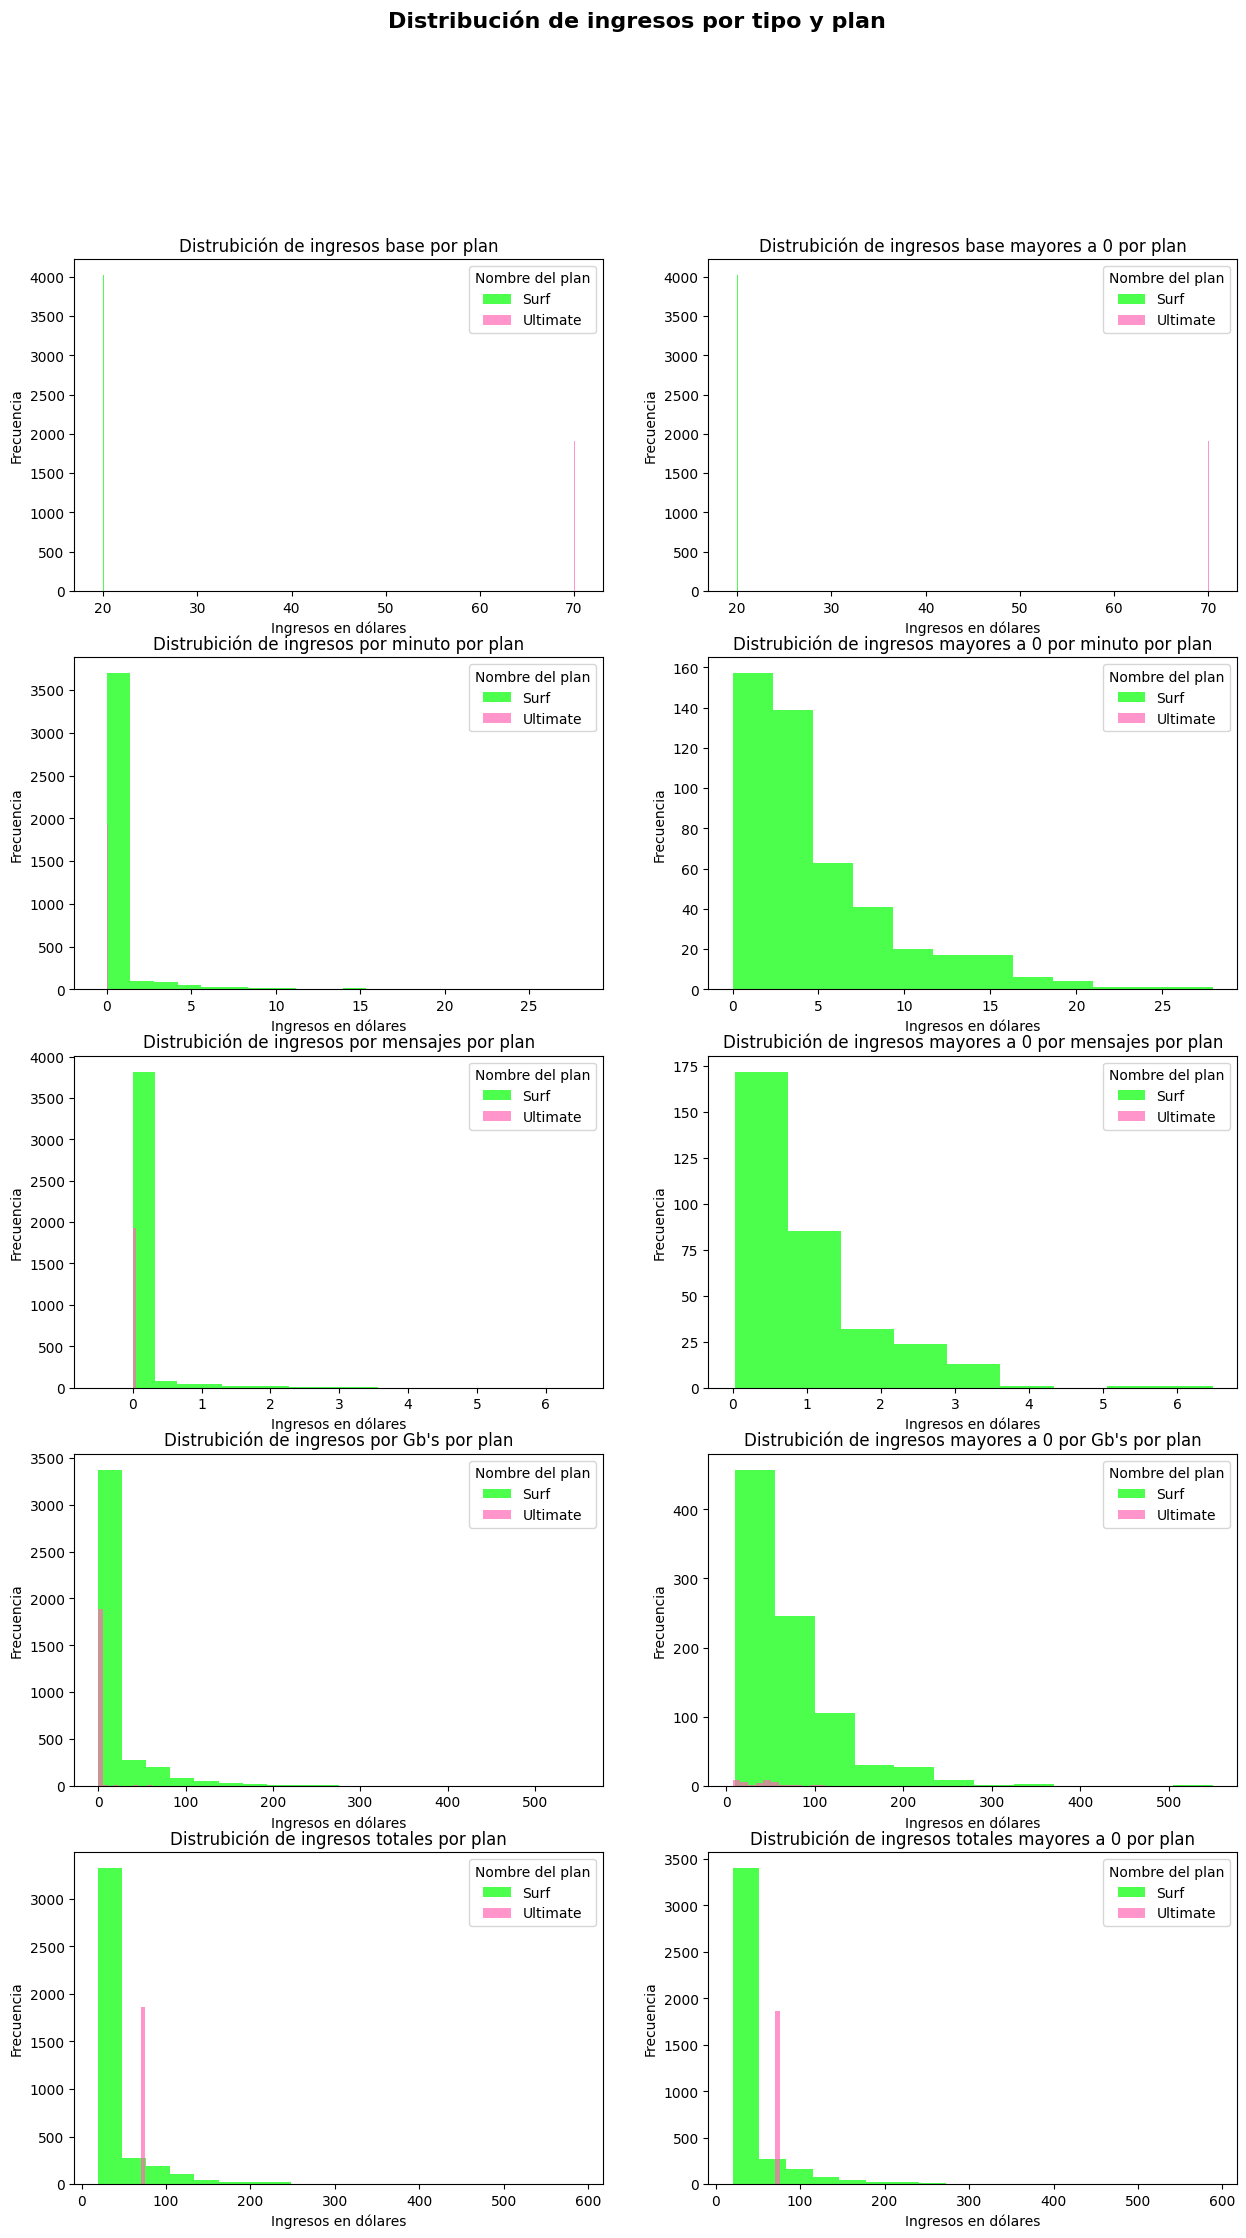

In [47]:
# Crear los histogramas

fig, axes = plt.subplots(5,2, figsize=(15, 25))
## Variables para las coordenadas de las imágenes
ax1 = axes[0,0]
ax2 = axes[0,1]
ax3 = axes[1,0]
ax4 = axes[1,1]
ax5 = axes[2,0]
ax6 = axes[2,1]
ax7 = axes[3,0]
ax8 = axes[3,1]
ax9 = axes[4,0]
ax10 = axes[4,1]
fig.suptitle('Distribución de ingresos por tipo y plan', fontsize=16, fontweight='bold')
# histograma ingreso base
ax1.hist(ingreso_base_surf_array, bins=20, alpha= 0.7,  color= 'lime', label= 'Surf' )
ax1.hist(ingreso_base_ultim_array, bins=20, alpha= 0.7, color= 'hotpink', label= 'Ultimate' )
ax1.set_title('Distrubición de ingresos base por plan')
ax1.set_xlabel('Ingresos en dólares')
ax1.set_ylabel('Frecuencia')
ax1.legend(title='Nombre del plan')

# histograma ingreso base mayor a 0
ax2.hist(active_ingreso_base_surf, bins=20, alpha= 0.7, color= 'lime', label= 'Surf' )
ax2.hist(active_ingreso_base_ultim, bins=20, alpha= 0.7, color= 'hotpink', label= 'Ultimate' )
ax2.set_title('Distrubición de ingresos base mayores a 0 por plan')
ax2.set_xlabel('Ingresos en dólares')
ax2.set_ylabel('Frecuencia')
ax2.legend(title='Nombre del plan')

# histograma ingreso minutos
ax3.hist(ingreso_mins_surf_array, bins=20, alpha= 0.7, color= 'lime', label= 'Surf' )
ax3.hist(ingreso_mins_ultim_array, bins=20, alpha= 0.7, color= 'hotpink', label= 'Ultimate' )
ax3.set_title('Distrubición de ingresos por minuto por plan')
ax3.set_xlabel('Ingresos en dólares')
ax3.set_ylabel('Frecuencia')
ax3.legend(title='Nombre del plan')

# histograma ingreso minutos mayores a 0
ax4.hist(active_ingreso_mins_surf, bins=12, alpha= 0.7, color= 'lime', label= 'Surf' )
ax4.hist(active_ingreso_mins_ultim, bins=12, alpha= 0.7, color= 'hotpink', label= 'Ultimate' )
ax4.set_title('Distrubición de ingresos mayores a 0 por minuto por plan')
ax4.set_xlabel('Ingresos en dólares')
ax4.set_ylabel('Frecuencia')
ax4.legend(title='Nombre del plan')

# histograma ingreso mensaje
ax5.hist(ingreso_msgs_surf_array, bins=20, alpha= 0.7, color= 'lime', label= 'Surf' )
ax5.hist(ingreso_msgs_ultim_array, bins=20, alpha= 0.7, color= 'hotpink', label= 'Ultimate' )
ax5.set_title('Distrubición de ingresos por mensajes por plan')
ax5.set_xlabel('Ingresos en dólares')
ax5.set_ylabel('Frecuencia')
ax5.legend(title='Nombre del plan')

# histograma ingreso mensajes mayores a 0
ax6.hist(active_ingreso_msgs_surf, bins=9, alpha= 0.7, color= 'lime', label= 'Surf' )
ax6.hist(active_ingreso_msgs_ultim, bins=9, alpha= 0.7, color= 'hotpink', label= 'Ultimate' )
ax6.set_title('Distrubición de ingresos mayores a 0 por mensajes por plan')
ax6.set_xlabel('Ingresos en dólares')
ax6.set_ylabel('Frecuencia')
ax6.legend(title='Nombre del plan')

# histograma ingreso gb
ax7.hist(ingreso_gb_surf_array, bins=20, alpha= 0.7, color= 'lime', label= 'Surf' )
ax7.hist(ingreso_gb_ultim_array, bins=20, alpha= 0.7, color= 'hotpink', label= 'Ultimate' )
ax7.set_title("Distrubición de ingresos por Gb's por plan")
ax7.set_xlabel('Ingresos en dólares')
ax7.set_ylabel('Frecuencia')
ax7.legend(title='Nombre del plan')

# histograma ingreso Gb's mayores a 0
ax8.hist(active_ingreso_gb_surf, bins=12, alpha= 0.7, color= 'lime', label= 'Surf' )
ax8.hist(active_ingreso_gb_ultim, bins=12, alpha= 0.7, color= 'hotpink', label= 'Ultimate' )
ax8.set_title("Distrubición de ingresos mayores a 0 por Gb's por plan")
ax8.set_xlabel('Ingresos en dólares')
ax8.set_ylabel('Frecuencia')
ax8.legend(title='Nombre del plan')

# histograma ingreso total
ax9.hist(ingreso_total_surf_array, bins=20, alpha= 0.7, color= 'lime', label= 'Surf' )
ax9.hist(ingreso_total_ultim_array, bins=20, alpha= 0.7, color= 'hotpink', label= 'Ultimate' )
ax9.set_title("Distrubición de ingresos totales por plan")
ax9.set_xlabel('Ingresos en dólares')
ax9.set_ylabel('Frecuencia')
ax9.legend(title='Nombre del plan')

# histograma ingreso total mayores a 0
ax10.hist(active_ingreso_total_surf, bins=18, alpha= 0.7, color= 'lime', label= 'Surf' )
ax10.hist(active_ingreso_total_ultim, bins=18, alpha= 0.7, color= 'hotpink', label= 'Ultimate' )
ax10.set_title("Distrubición de ingresos totales mayores a 0 por plan")
ax10.set_xlabel('Ingresos en dólares')
ax10.set_ylabel('Frecuencia')
ax10.legend(title='Nombre del plan')

plt.show()

**Distribución de ingresos base por plan**

* Tanto para el total de registros como aquellos mayores a cero, es de esperar solo dos columnas; uno en el 20 (costo del plan mensua Surf) y otro en 70 (costo del plan mensual Ultimate).

**Distribución de ingresos por minutos extras por plan**

* Como siempre se muestra sesgo a la derecha y dificultad de visualizar patrones debido a la gran cantidad de valores igual a 0.
* Al tomar solo valores mayores a cero el plan Ultimate desaparece (como ya se había analizado antes). Para Surf se muestra un patrón con sesgo a la derecha, la mayoría de usuarios generan entre 1 a 5 dólares al mes que van reduciendo hasta usuarios que generan hasta 25 dólares al mes por minutos extras.

**Distribución de ingresos extras por mensajes por plan**

* Con todos los valores hay sesgo a la derecha y dificultad de visualización.
* Con valores mayores a 0 Ultimate desaparece (ningún usuario de este plan supera el límite). El patrón de distribución del plan Surf muestra sesgo a la derecha; aproximadamente 170 usuarios generan ingresos entre `$`0.01 a `$`1.00 dolar mientras que 25 o menos usuarios genrean entre `$`3.00 a `$`6.00 dólares.

**Distribución de ingresos extras por Gb's por plan**

* Con todos los valores hay sesgo a la derecha y dificultad de visualización.
* Único caso de ingreso extra en los que Ultimate "debe tomarse en cuenta". Tomando los valores mayores a 0: para Ultimate se muestra un patron que desciende, asciende y desciende de nuevo; menos de 25 usuarios generan entre `$`0.00 y `$`75.00 dolares mientrs que para el plan Surf se tiene que entre 400 y 500 usuarios generan esa misma cantidad; a partir de ahí la cantidad de usuarios de plan Surf disminuye conforme los ingresos aumentan.

**Distribución de ingresos totales por plan**

* Ya que en este caso de los 6000 registros totales sólo 76 valores son 0 contando ambos planes, las gráficas son sumamente similares.
* Para plan Ultimate; como es de esperar, una columna en los `$`70.00 dólares ya wue solo cuenta con ingresos extras en G'bs y son muy escasos en comparación del total. Aproximadamente 1700 usuarios dejaron ingresos de  `$`70.00 dólares cada uno.
* Para el plan Surf aproximádamente 3,300 usuarios generaron `$`20.00 cada uno, a partir de ahí, aproximadamente 250 usuarios generaron ingresos entre `$`50.00 y `$`75.00 dólares, de ahí en adelante el número de usuarios diminuye a medida que el ingreso aumenta.
* Sería interesante ver el total de ingresos por cada plan ya que, aunque Ultimate no genere mucho de extras, parece ser que los ingresos anuales de cada plan son muy similares.

In [48]:
# Muestra la media y varianza de los histogramas.

print(f"Para el plan Surf la media de ingresos base mayores a 0 mensuales es {active_ingreso_base_surf.mean():.2f} y la varianza es {active_ingreso_base_surf.var():.2f}")
print(f"Para el plan Ultimate la media de ingresos base mayores a 0 mensuales es {active_ingreso_base_ultim.mean():.2f} y la varianza es {active_ingreso_base_ultim.var():.2f}")
print()
print(f"Para el plan Surf la media de ingresos extra mayores a 0 por minutos mensuales es {active_ingreso_mins_surf.mean():.2f} y la varianza es {active_ingreso_mins_surf.var():.2f}")
print()
print(f"Para el plan Surf la media de ingresos extras mayores a 0 por mensajes mensuales es {active_ingreso_msgs_surf.mean():.2f} y la varianza es {active_ingreso_msgs_surf.var():.2f}")
print()
print(f"Para el plan Surf la media de ingresos extras mayores a 0 por consumo de Gb's mensual es {active_ingreso_gb_surf.mean():.2f} y la varianza es {active_ingreso_gb_surf.var():.2f}")
print(f"Para el plan Ultimate la media de ingresos extras mayores a 0 por consumo de Gb's mensual es {active_ingreso_gb_ultim.mean():.2f} y la varianza es {active_ingreso_gb_ultim.var():.2f}")
print()
print(f"Para el plan Surf la media de ingresos totales mayores a 0 mensual es {active_ingreso_total_surf.mean():.2f} y la varianza es {active_ingreso_total_surf.var():.2f}")
print(f"Para el plan Ultimate la media de ingresos totales mayores a 0 mensual es {active_ingreso_total_ultim.mean():.2f} y la varianza es {active_ingreso_total_ultim.var():.2f}")

Para el plan Surf la media de ingresos base mayores a 0 mensuales es 20.00 y la varianza es 0.00
Para el plan Ultimate la media de ingresos base mayores a 0 mensuales es 70.00 y la varianza es 0.00

Para el plan Surf la media de ingresos extra mayores a 0 por minutos mensuales es 4.82 y la varianza es 20.11

Para el plan Surf la media de ingresos extras mayores a 0 por mensajes mensuales es 0.98 y la varianza es 0.85

Para el plan Surf la media de ingresos extras mayores a 0 por consumo de Gb's mensual es 66.70 y la varianza es 3281.06
Para el plan Ultimate la media de ingresos extras mayores a 0 por consumo de Gb's mensual es 41.30 y la varianza es 719.81

Para el plan Surf la media de ingresos totales mayores a 0 mensual es 35.27 y la varianza es 1547.08
Para el plan Ultimate la media de ingresos totales mayores a 0 mensual es 70.87 y la varianza es 50.20


Para los diagramas de caja (boxplot) se mostrarán únicamente los ingresos extras mayores a 0 del plan Surf excepto para ingresos base e ingresos pod Gb's y totales en los cuales también se mostrará únicamente los valores mayores a 0.

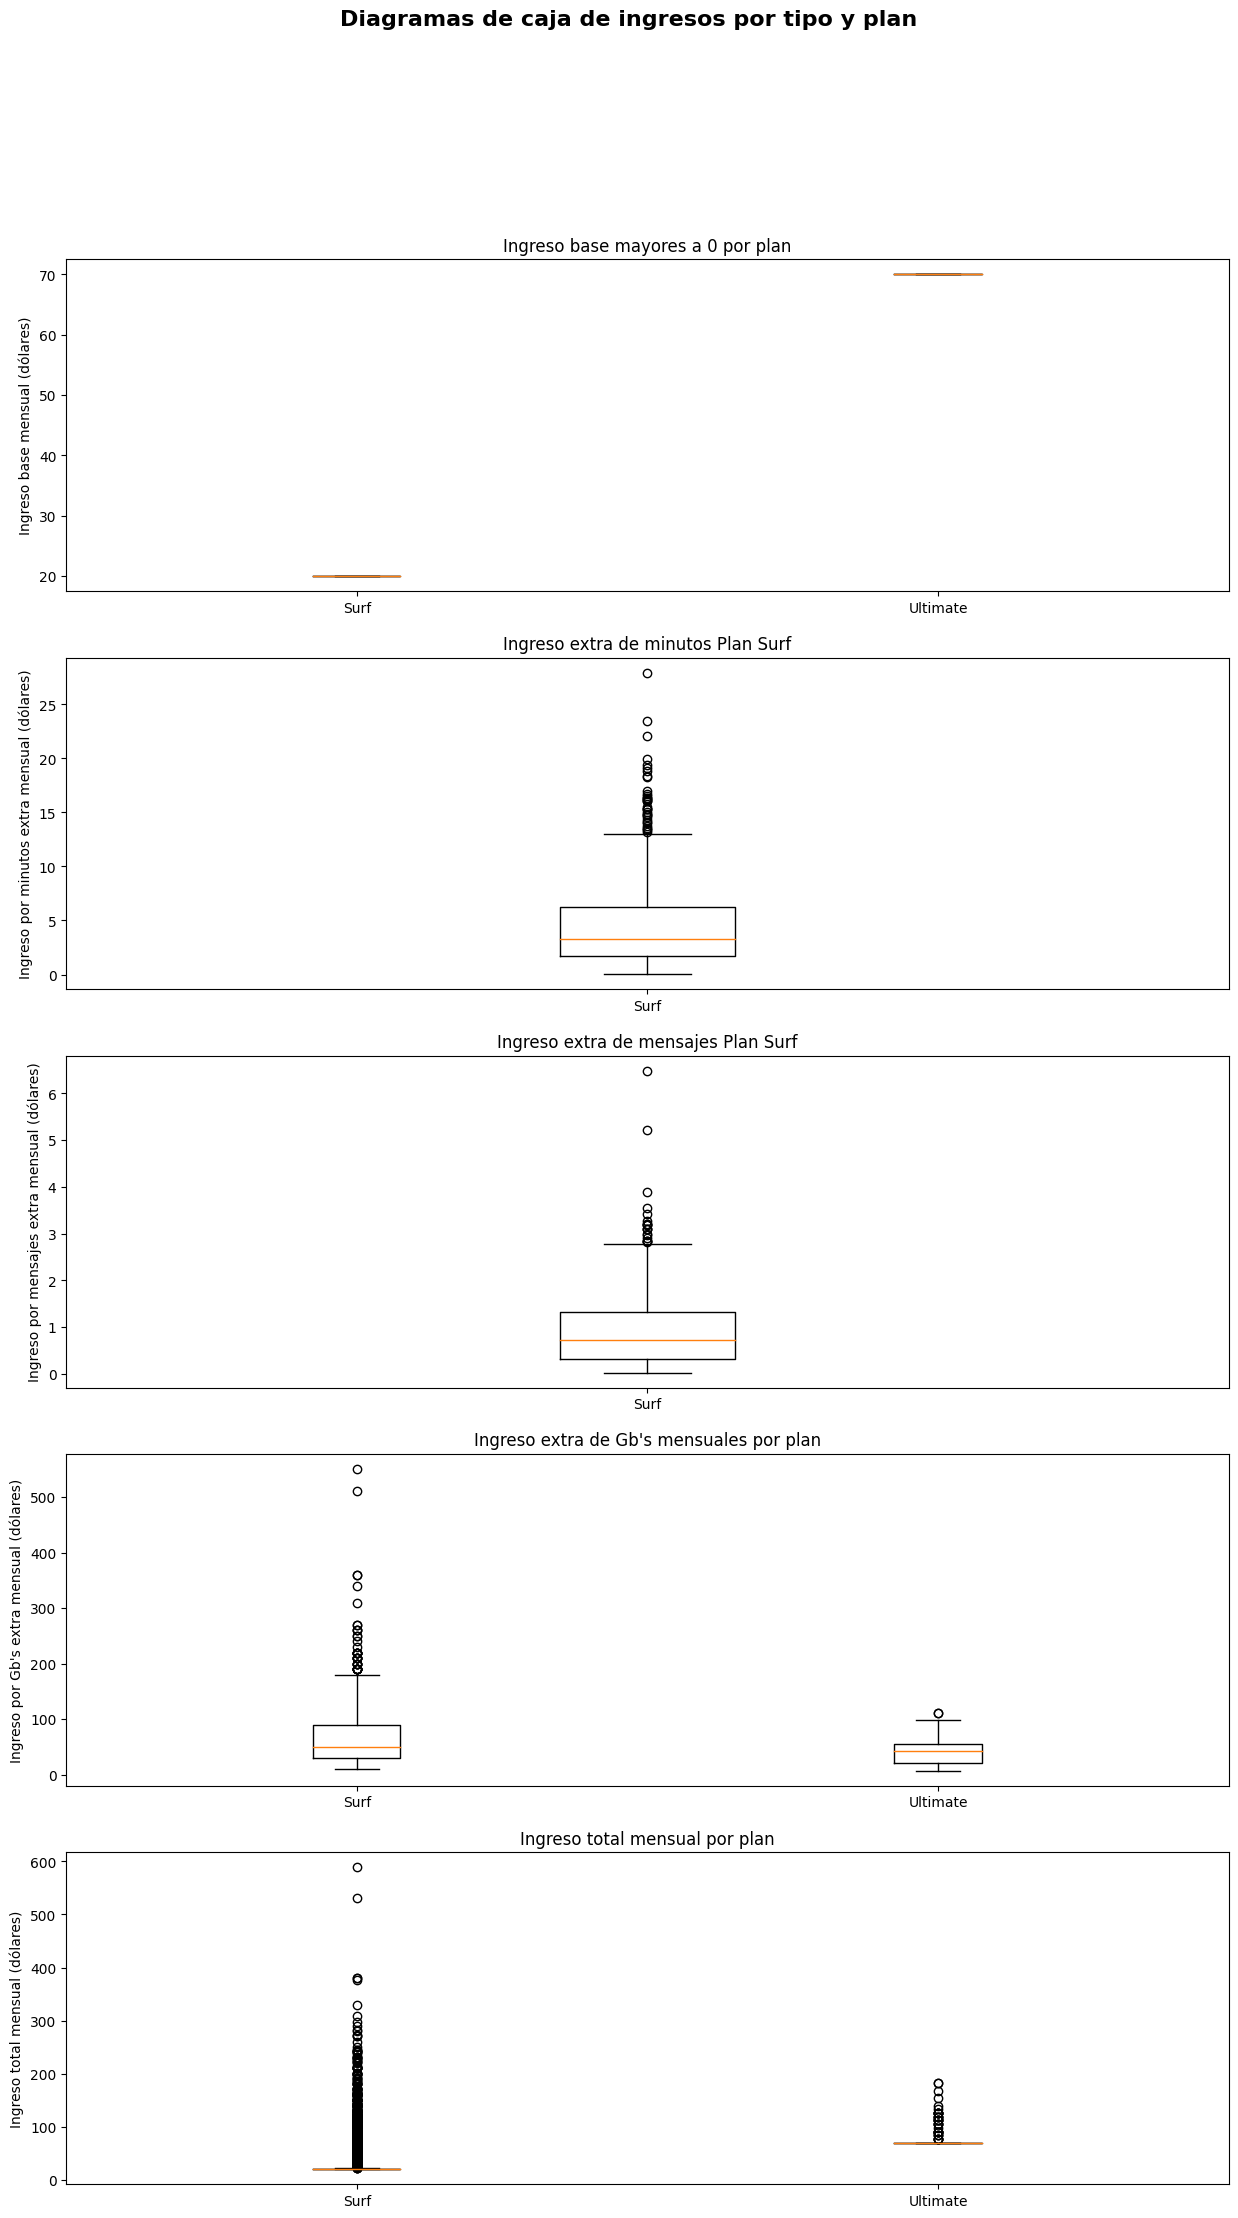

In [49]:
# Crear los diagramas de caja (boxplot)

fig, axes = plt.subplots(5,1, figsize=(15, 25))
## Variables para las coordenadas de las imágenes
ax1 = axes[0]
ax2 = axes[1]
ax3 = axes[2]
ax4 = axes[3]
ax5 = axes[4]
fig.suptitle('Diagramas de caja de ingresos por tipo y plan', fontsize=16, fontweight='bold')

#boxplot  
ax1.boxplot([active_ingreso_base_surf, active_ingreso_base_ultim], labels=['Surf', 'Ultimate'])
ax1.set_title('Ingreso base mayores a 0 por plan')
ax1.set_ylabel('Ingreso base mensual (dólares)')

ax2.boxplot([active_ingreso_mins_surf], labels=['Surf'])
ax2.set_title('Ingreso extra de minutos Plan Surf')
ax2.set_ylabel('Ingreso por minutos extra mensual (dólares)')

ax3.boxplot([active_ingreso_msgs_surf], labels=['Surf'])
ax3.set_title('Ingreso extra de mensajes Plan Surf')
ax3.set_ylabel('Ingreso por mensajes extra mensual (dólares)')

ax4.boxplot([active_ingreso_gb_surf, active_ingreso_gb_ultim], labels=['Surf', 'Ultimate'])
ax4.set_title("Ingreso extra de Gb's mensuales por plan")
ax4.set_ylabel("Ingreso por Gb's extra mensual (dólares)")

ax5.boxplot([active_ingreso_total_surf, active_ingreso_total_ultim], labels=['Surf', 'Ultimate'])
ax5.set_title("Ingreso total mensual por plan")
ax5.set_ylabel("Ingreso total mensual (dólares)")

plt.show()

In [50]:
# Estaqdisticos de cajas de bigotes
boxplot_stats(active_ingreso_base_surf, 'ingresos base Surf (mayores a 0)')
print('-'*50)
boxplot_stats(active_ingreso_base_ultim, 'ingresos base Ultimate (mayores a 0)')
print('-'*50)
boxplot_stats(active_ingreso_mins_surf,'ingreso extra por minutos Surf (mayores a 0)')
print('-'*50)
boxplot_stats(active_ingreso_msgs_surf, 'ingreso extra por mensajes Surf (mayores a 0)')
print('-'*50)
boxplot_stats(active_ingreso_gb_surf, "ingreso extra por gb's Surf (mayores a 0)")
print('-'*50)
boxplot_stats(active_ingreso_gb_ultim, "ingreso extra por gb's Ultimate (mayores a 0)")
print('-'*50)
boxplot_stats(active_ingreso_total_surf, 'ingresos totales mensuales plan surf (mayores a 0)')
print('-'*50)
boxplot_stats(active_ingreso_total_ultim, 'ingresos totales mensuales plan ultimate (mayores a 0)')

=== INGRESOS BASE SURF (MAYORES A 0)===
Mínimo absoluto: 20.00
Mínimo del bigote: 20.00
Q1: 20.00
Mediana: 20.00
Q3: 20.00
Máximo del bigote: 20.00
Máximo absoluto: 20.00

--- VALORES ATÍPICOS ---
Atípicos inferiores: 0 valores.
Atípicos superiores: 0 valores.
Atípicos totales: 0 (0.0% del total.)
Datos normales: 4020 (100.0% del total.)
--------------------------------------------------
=== INGRESOS BASE ULTIMATE (MAYORES A 0)===
Mínimo absoluto: 70.00
Mínimo del bigote: 70.00
Q1: 70.00
Mediana: 70.00
Q3: 70.00
Máximo del bigote: 70.00
Máximo absoluto: 70.00

--- VALORES ATÍPICOS ---
Atípicos inferiores: 0 valores.
Atípicos superiores: 0 valores.
Atípicos totales: 0 (0.0% del total.)
Datos normales: 1904 (100.0% del total.)
--------------------------------------------------
=== INGRESO EXTRA POR MINUTOS SURF (MAYORES A 0)===
Mínimo absoluto: 0.01
Mínimo del bigote: 0.01
Q1: 1.72
Mediana: 3.30
Q3: 6.27
Máximo del bigote: 12.98
Máximo absoluto: 27.94

--- VALORES ATÍPICOS ---
Atípicos i

**Solo quiero comparar los ingresos totales anuales de ambos planes sntes de continuar**

In [49]:
# Creamos las listas de los nombres de columnas a usar
columnas_ingreso_total= [f"ingreso_total_{i}" for i in range (1, 13)]
columnas_ingreso_base= [f"ingreso_base_{i}" for i in range(1, 13)]
columnas_ingreso_msgs= [f"ingreso_extra_msgs_{i}" for i in range(1, 13)]
columnas_ingreso_mins= [f"ingreso_extra_mins_{i}" for i in range(1, 13)]
columnas_ingreso_gb =[f"ingreso_extra_gb_{i}" for i in range(1, 13)]
#Crea el índice (eje x) que requerimos para todas las gráficas:
indice_mes_solo_number= [i for i in range (1, 13)]
# Filtramos los datos del df original y los transponemos para usar en las gráficas

amount_ingreso_total_x_plan= df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_total].sum().T
media_ingreso_total_x_plan= df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_total].mean().T
varianza_ingreso_total_x_plan= df_ready_for_stats_copy.groupby('plan_name')[columnas_ingreso_total]

In [53]:
# Definición de la función y configuración inicial
def graficar_evolucion_estadisticas_ingresos(df, incluir_graficos=True):
    """
    Grafica la evolución mensual de mediana y desviación estándar 
    para cada tipo de ingreso por plan
    """
    
    # Definir columnas de ingresos
    tipos_ingreso = {
        'Ingresos Totales': [f"ingreso_total_{i}" for i in range(1, 13)],
        'Ingresos Base': [f"ingreso_base_{i}" for i in range(1, 13)],
        'Ingresos Extra Minutos': [f"ingreso_extra_mins_{i}" for i in range(1, 13)],
        'Ingresos Extra Mensajes': [f"ingreso_extra_msgs_{i}" for i in range(1, 13)],
        'Ingresos Extra GB': [f"ingreso_extra_gb_{i}" for i in range(1, 13)]
    }
    
    meses = list(range(1, 13))
    planes = ['surf', 'ultimate']
    colores = {'surf': 'lime', 'ultimate': 'hotpink'}

     # Crear figura con subplots
    fig, axes = plt.subplots(len(tipos_ingreso), 3, figsize=(18, 22))
    fig.suptitle('Evolución Mensual de Estadísticas de Ingresos por Tipo y Plan - 2018', 
                 fontsize=16, fontweight='bold')
    
    estadisticas_completas = {}

    # Bucle principal para calcular estadísticas
    for i, (tipo_nombre, columnas) in enumerate(tipos_ingreso.items()):
        print(f"\n=== PROCESANDO {tipo_nombre.upper()} ===")
        
        # Inicializar diccionarios para este tipo de ingreso
        medianas = {plan: [] for plan in planes}
        medias = {plan: [] for plan in planes}
        desv_std = {plan: [] for plan in planes}
                
        # Calcular estadísticas para cada mes
        for mes in meses:
            columna_mes = columnas[mes-1]  # Ajustar índice
            
            for plan in planes:
                # Filtrar datos del plan y mes específico
                datos_plan_mes = df[df['plan_name'] == plan][columna_mes].dropna()
                
                # Filtrar solo valores > 0 para ingresos extras
                if 'Extra' in tipo_nombre:
                    datos_plan_mes = datos_plan_mes[datos_plan_mes > 0]

                # Cálculo de estadísticas por mes y plan
                # Calcular estadísticas
                if len(datos_plan_mes) > 0:
                    medianas[plan].append(datos_plan_mes.median())
                    medias[plan].append(datos_plan_mes.mean()) 
                    desv_std[plan].append(datos_plan_mes.std())
                else:
                    medianas[plan].append(0)
                    medias[plan].append(0)  # ← AGREGAR ESTO
                    desv_std[plan].append(0)
        
        # Guardar estadísticas
        estadisticas_completas[tipo_nombre] = {
            'medianas': medianas,
            'medias' : medias,
            'desviaciones_estandar': desv_std
        }

        if incluir_graficos:
            # Gráfico de medianas
            for plan in planes:
                axes[i, 0].plot(meses, medianas[plan], 
                               marker='o', linewidth=2, 
                               color=colores[plan], label=f'{plan.title()}')
            
            axes[i, 0].set_title(f'Evolución Mediana - {tipo_nombre}')
            axes[i, 0].set_xlabel('Mes')
            axes[i, 0].set_ylabel('Mediana ($)')
            axes[i, 0].legend()
            axes[i, 0].grid(True, alpha=0.3)

            # Gráfico de medias
            for plan in planes:
                axes[i, 1].plot(meses, medias[plan], 
                               marker='s', linewidth=2, 
                               color=colores[plan], label=f'{plan.title()}')
            
            axes[i, 1].set_title(f'Evolución de la Media (promedio) - {tipo_nombre}')
            axes[i, 1].set_xlabel('Mes')
            axes[i, 1].set_ylabel('Media ($)')
            axes[i, 1].legend()
            axes[i, 1].grid(True, alpha=0.3)

            # Gráfico de desviación estándar
            for plan in planes:
                axes[i, 2].plot(meses, desv_std[plan], 
                               marker='s', linewidth=2, 
                               color=colores[plan], label=f'{plan.title()}')
            
            axes[i, 2].set_title(f'Evolución Desviación Estándar - {tipo_nombre}')
            axes[i, 2].set_xlabel('Mes')
            axes[i, 2].set_ylabel('Desviación Estándar ($)')
            axes[i, 2].legend()
            axes[i, 2].grid(True, alpha=0.3)

        if incluir_graficos:
            plt.tight_layout()
            plt.show()

        return estadisticas_completas

            



=== PROCESANDO INGRESOS TOTALES ===


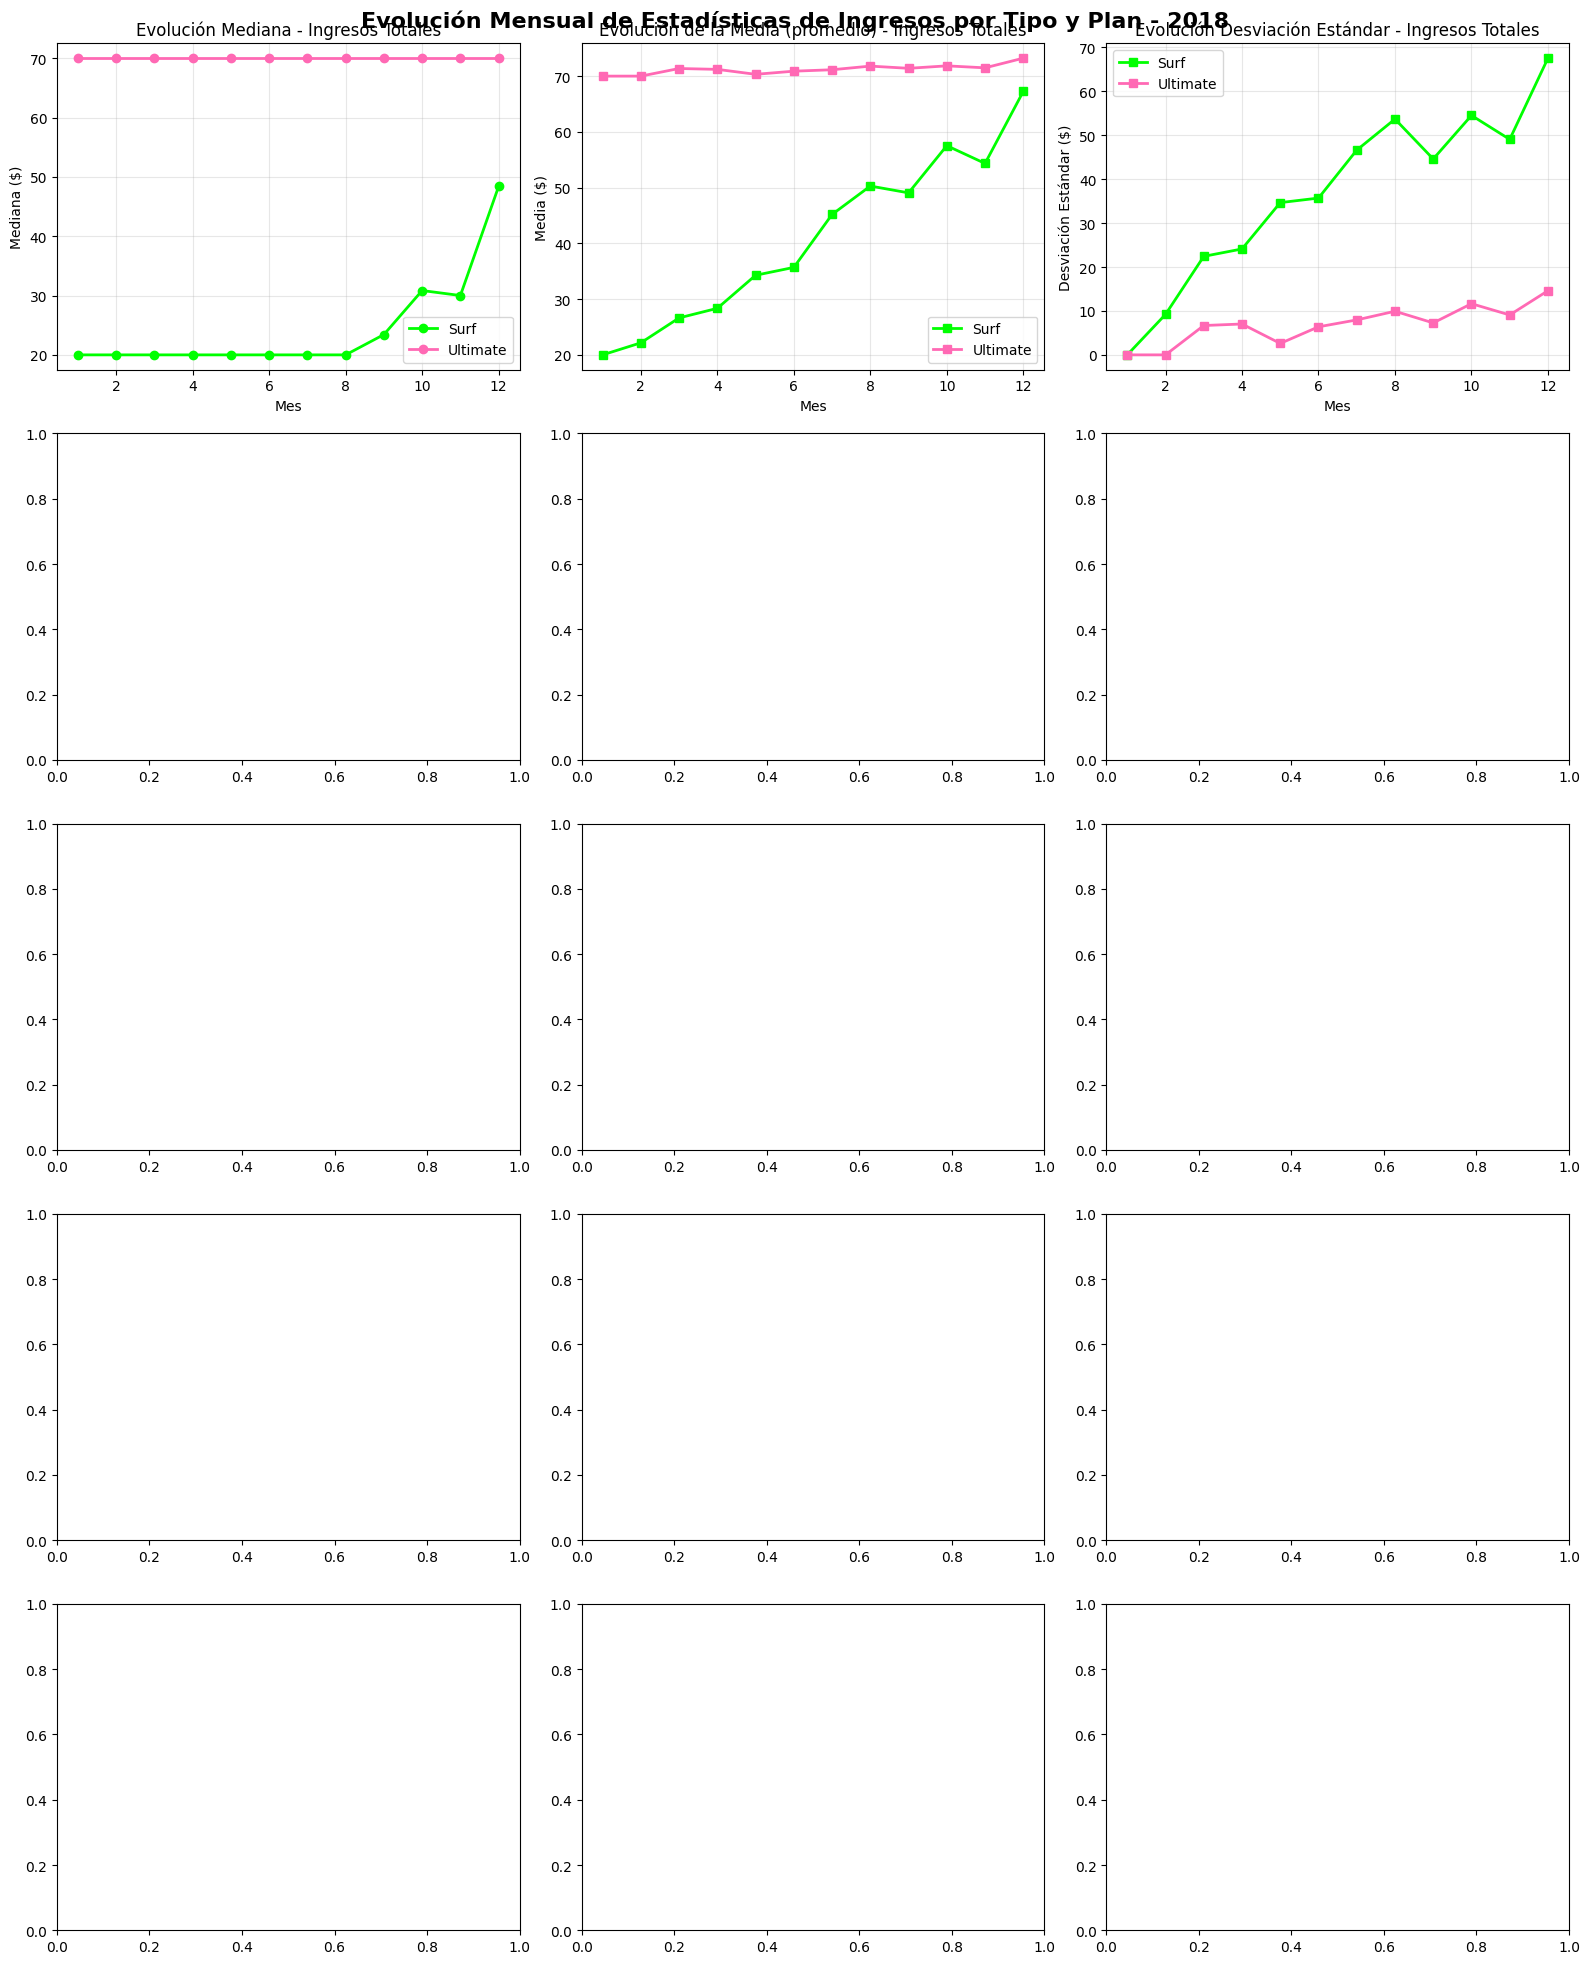

{'Ingresos Totales': {'medianas': {'surf': [20.0,
    20.0,
    20.0,
    20.0,
    20.0,
    20.0,
    20.0,
    20.0,
    23.42,
    30.84,
    30.0,
    48.39],
   'ultimate': [70.0,
    70.0,
    70.0,
    70.0,
    70.0,
    70.0,
    70.0,
    70.0,
    70.0,
    70.0,
    70.0,
    70.0]},
  'medias': {'surf': [20.0,
    22.159499999999998,
    26.62944444444444,
    28.35104838709677,
    34.27765100671141,
    35.68950276243094,
    45.18809756097561,
    50.28446808510638,
    49.0596812749004,
    57.52313167259787,
    54.33781144781145,
    67.2618670886076],
   'ultimate': [70.0,
    70.0,
    71.36585365853658,
    71.21153846153847,
    70.32307692307693,
    70.88505747126437,
    71.14285714285714,
    71.79646017699115,
    71.4,
    71.84210526315789,
    71.48630136986301,
    73.22]},
  'desviaciones_estandar': {'surf': [0.0,
    9.216582775131327,
    22.432655388468344,
    24.11821296143071,
    34.673629172405484,
    35.70865931825132,
    46.62619243904637,


In [54]:
graficar_evolucion_estadisticas_ingresos(df_ready_for_stats_copy)

In [51]:
total_anual_surf= active_ingreso_total_surf.sum()
total_anual_ultim= active_ingreso_total_ultim.sum()
resta= total_anual_surf - total_anual_ultim
                
print(f"Los ingresos totales anuales para Surf son: ${total_anual_surf:.2f}")
print(f"Los ingresos totales anuales para Ultimate son: ${total_anual_ultim:.2f}")
print(f"El plan Surf genera ${resta:.2f} más que el plan Ultimate")

Los ingresos totales anuales para Surf son: $141802.67
Los ingresos totales anuales para Ultimate son: $134932.00
El plan Surf genera $6870.67 más que el plan Surf


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Menor pero importante: tu instrucción final de `print` dice “Surf generates more than Surf” (error tipográfico por copiar/pegar). Considera corregir el texto para que compare Surf vs Ultimate con claridad.

</div>


* La diferencia de ganancias entre los planes es dos órdenes de magnitud menor que las ganancias totales.

**Conclusiones sobre los Ingresos de los Planes Megaline**

1. **Ingresos Totales Anuales**

    * Plan Surf: `$`141,802.67 anuales
    * Plan Ultimate: `$`134,932.00 anuales
    * Diferencia: El plan Surf genera `$`6,870.67 más que Ultimate (5.1% superior)

2. **Estructura de Ingresos por Plan**

Plan Ultimate:

- Ingresos muy estables (~ `$`11,000 mensuales)
- Principalmente ingresos base (`$`70/mes por usuario)
- Mínimos ingresos extras (solo por Gb's excedentes)
- 97.9% de usuarios pagan exactamente `$`70/mes

Plan Surf:

- Ingresos variables con tendencia creciente
- Múltiples fuentes de ingresos extras:
    - Minutos extras: hasta `$`600/mes
    - Mensajes extras: hasta `$`100/mes
    - Gb's extras: hasta `$`14,000/mes (principal fuente)
    - 23.7% de usuarios generan ingresos superiores al plan base

3. **Comportamiento de Usuarios y Generación de Ingresos**

Llamadas:

- Ambos planes tienen comportamientos similares (medias ~410 minutos)
- Solo Surf genera ingresos extras por minutos
- Ultimate nunca supera su límite de 3,000 minutos

Mensajes:

- Patrones similares entre planes
- Solo Surf genera ingresos extras (máximo 266 mensajes vs límite de 50)
- Ultimate nunca supera su límite de 1,000 mensajes

Consumo de Internet:

- Clave diferenciadora: Surf genera ingresos extras significativos por Gb's
- Surf: máximo 70 Gb (límite: 15 Gb) = hasta `$`550 extras
- Ultimate: máximo 46 Gb (límite: 30 Gb) = hasta `$`112 extras

4. **Rentabilidad por Usuario**

    - Surf: Ingreso promedio mensual `$`35.27 por usuario activo
    - Ultimate: Ingreso promedio mensual `$`70.87 por usuario activo

    Paradoja: Aunque Ultimate genera más por usuario, Surf es más rentable globalmente debido a:

    - Mayor base de usuarios (339 vs 161)
    - Significativos ingresos extras por excedentes

5. **Conclusión Estratégica**

El Plan Surf es más rentable para Megaline porque

* Genera mayores ingresos totales (`$`6,870 más anuales)
* Tiene mayor potencial de crecimiento por ingresos extras
* Atrae más usuarios (2.1 veces más suscriptores)
* Los usuarios superan frecuentemente los límites, especialmente en datos

Recomendación: Enfocar la estrategia comercial en el Plan Surf, ya que aunque tiene menor costo base, su modelo de "límites bajos + cobros por excedentes" resulta más lucrativo que el modelo de "límites altos + precio fijo" del Plan Ultimate.

## Prueba las hipótesis estadísticas

**Pregunta**

¿Existe diferencia en los ingresos promedio totales de los usuarios por plan?

**Hipótesis Nula:**

No existe diferencia

**Hipótesis alternativa:**

Existe diferencia estadística

**Nivel de significancia:**

0.05

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Antes de ejecutar la prueba t, justifica brevemente por qué esta prueba es adecuada e indica los supuestos clave (independencia, normalidad aproximada y si se asumen varianzas iguales). Considera también si la prueba t de Welch (`equal_var=False`) es más apropiada si las varianzas difieren.

</div>


In [52]:
# Prueba las hipótesis
alpha = 0.05  # el nivel de significancia estadística crítica
# si el valor p es menor que alpha, rechazamos la hipótesis

results = st.ttest_ind(active_ingreso_total_surf, active_ingreso_total_ultim) # realizar una prueba

print('valor p: ', results.pvalue) # extraer el valor p

if results.pvalue < alpha: # comparar el valor p con el umbral
    print("Rechazamos la hipótesis nula")
    print('Los ingresos promedio entre los planes son estadísticamente diferentes')
else:
    print("No podemos rechazar la hipótesis nula")
    print('No hay evidencia suficiente de diferencia entre los ingresos totales de los planes')


valor p:  9.268131822721168e-299
Rechazamos la hipótesis nula
Los ingresos promedio entre los planes son estadísticamente diferentes


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para las pruebas de hipótesis, ten en cuenta que usar valores usuario-mes significa que el mismo usuario aparece varias veces, lo que rompe el supuesto de independencia de una prueba t de dos muestras. Considera agregar primero a un valor por usuario (p. ej., el ingreso mensual promedio por usuario o el ingreso anual total por usuario) y luego comparar planes. También añade una breve explicación de tu elección de alpha y la regla de decisión (rechazar H0 cuando p-value < alpha).

</div>


**Preparación de arreglos**

In [53]:
# Filtrar los datos por regiones
## Datos de ingresos totales para región NY-NJ
ny_nj_data= df_ready_for_stats[df_ready_for_stats['city'].str.contains('NY-NJ')][columnas_ingreso_total].values.flatten()
## Datos de ingresos totales para otras ciudades
other_cities_data= df_ready_for_stats[~df_ready_for_stats['city'].str.contains('NY-NJ')][columnas_ingreso_total].values.flatten()
# Imprime la catidad de valores nan y cantidades totales de elementos
print(f"La cantidad de NaN en NJ-NY es: {np.isnan(ny_nj_data).sum()}")
print(f"La cantidad de NaN en otras ciudades es: {np.isnan(other_cities_data).sum()}")
print(f"Cantidad de elementos sin NaN en NY-Nj: {len(ny_nj_data)}")
print(f"Cantidad de elementos sin NaN en otras ciudades: {len(other_cities_data)}")

La cantidad de NaN en NJ-NY es: 12
La cantidad de NaN en otras ciudades es: 64
Cantidad de elementos sin NaN en NY-Nj: 960
Cantidad de elementos sin NaN en otras ciudades: 5040


* Los NaN aparecen por contratos terminados durante 2018.
    * Se decidió eliminarlos en lugar de sustituir con 0 ya que el sustituir puede afectar al análisis. No es lo mismo facturar $0.00 que no ser cliente.

In [54]:
# Limpieza de los valores NaN
## Limpieza de datos de ny-nj
ny_nj_data_clean= ny_nj_data[~np.isnan(ny_nj_data)]
## Limpieza de otras ciudades
other_cities_data_clean= other_cities_data[~np.isnan(other_cities_data)]
# Imprime la catidad de valores nan y cantidades totales de elementos
print(f"La cantidad de NaN en NJ-NY es: {np.isnan(ny_nj_data_clean).sum()}")
print(f"La cantidad de NaN en otras ciudades es: {np.isnan(other_cities_data_clean).sum()}")
print(f"Cantidad de elementos sin NaN en NY-Nj: {len(ny_nj_data_clean)}")
print(f"Cantidad de elementos sin NaN en otras ciudades: {len(other_cities_data_clean)}")

La cantidad de NaN en NJ-NY es: 0
La cantidad de NaN en otras ciudades es: 0
Cantidad de elementos sin NaN en NY-Nj: 948
Cantidad de elementos sin NaN en otras ciudades: 4976


**Hipótesis nula**

El ingreso promedio de los usuarios de NY-NJ es igual al de otras regiones.

**Hipótesis alternativa**

El ingrerso promedio de los usuarios de NY-NJ es estadísticamente diferente al de otras regiones.

**Nivel de significancia**

0.05

In [55]:
# Prueba las hipótesis
alpha = 0.05  # el nivel de significancia estadística crítica
# si el valor p es menor que alpha, rechazamos la hipótesis

results = st.ttest_ind(ny_nj_data_clean, other_cities_data_clean) # realizar una prueba

print('valor p: ', results.pvalue) # extraer el valor p

if results.pvalue < alpha: # comparar el valor p con el umbral
    print("Rechazamos la hipótesis nula")
    print('Los ingresos promedio de los usuarios de NY-NJ difieren estadísticamente con los de otras ciudades.')
else:
    print("No podemos rechazar la hipótesis nula")
    print('No hay evidencia suficiente de diferencia entre los ingresos promedios de usarios de NY-NJ y otras ciudades.')

valor p:  0.042141684920310826
Rechazamos la hipótesis nula
Los ingresos promedio de los usuarios de NY-NJ difieren estadísticamente con los de otras ciudades.


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

El mismo problema de independencia que en la prueba anterior: la comparación NY–NJ vs. otras regiones utiliza múltiples meses por usuario. Considera agregar (aggregating) a un solo valor de ingresos por usuario antes de comparar regiones para ajustarse mejor a los supuestos de la prueba.

</div>


### Análisis de rentabilidad por usuario
Se realizará un cálculo de las ganancias totales anuales del plan entre la cantidad de usuarios de cada uno

In [56]:
ingreso_promedio_surf = total_anual_surf / surf_total_usrs
ingreso_promedio_ultimate = total_anual_ultim / ultim_total_usrs
print(f"Ingreso promedio anual por usuario Surf: ${ingreso_promedio_surf:.2f}")
print(f"Ingreso promedio anual por usuario Ultimate: ${ingreso_promedio_ultimate:.2f}")

Ingreso promedio anual por usuario Surf: $418.30
Ingreso promedio anual por usuario Ultimate: $838.09


## Conclusión general

**Respuesta a la pregunta del negocio**
¿Cuál plan genera más ingresos?

El plan más rentable es SURF, a continuación se mencionan algunas razones:

**Ingresos totales anuales:**

    - Surf: $141,802.67
- Ultimate: $134,932.00
    - Diferencia: $6,870.67 a favor de Surf.
    
**Análisis de rentabilidad por usuario:**

	- Ingreso promedio anual por usuario Surf: $418.30
- Ingreso promedio anual por usuario Ultimate: $838.09
    
Aunque Ultimate genera más ingreso por usuario individual, Surf es más rentable globalmente debido a:
**Ingresos extras:**

	- Surf genera ingresos extras en las 3 categorías: minutos, mensajes y GB.
	- Ultimate solo genera ingresos extras en GB (muy limitados solo 40 registros vs 882 de Surf).
    
**Potencial de crecimiento:**

	- Surf tiene 339 usuarios vs 161 de Ultimate.
	- Mayor base de usuarios se traduce en mayor potencial de ingresos extras.
    
**Diferencias regionales confirmadas:**

	- Existe diferencia estadísticamente significativa entre NY-NJ y otras regiones (p = 0.042).
	- Los usuarios de NY-NJ generan ingresos diferentes a otras ciudades.
    
**Análisis estadístico:**

	- Diferencia significativa entre planes (p < 0.001).
	- Surf muestra mayor variabilidad en ingresos (más oportunidades de extras).
	- Ultimate es más estable pero con menor potencial de crecimiento.

Recomendación de estrategia:
		
Enfocar el presupuesto publicitario en el plan Surf ya que:

	- Genera más ingresos totales anuales ($6,870.67 adicionales).
	- Tiene mayor potencial de ingresos extras en todas las categorías.
	- Base de usuarios más amplia (2.1 veces más usuarios).
	- Mayor oportunidad de monetización por excesos de uso.
	- Mejor escalabilidad para crecimiento futuro

**Conclusión final** 

Aunque Ultimate tiene mayor valor por usuario individual, Surf es el plan más rentable para la empresa debido a su volumen total de ingresos, diversificación de fuentes de ingresos extras y mayor potencial de crecimiento.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tu conclusión resume bien los resultados, pero sería más sólida si también enumeras las decisiones/supuestos clave de procesamiento que determinan esos resultados (p. ej., cómo se aplicó el redondeo de llamadas, cómo se aplicó el redondeo de GB de internet, cómo se trataron los meses de churn, cómo se manejaron los NaNs/meses con uso cero, y cómo se definieron las observaciones para las pruebas de hipótesis). Esto ayuda al lector a confiar en tus hallazgos y reproducirlos.

</div>
